C:\Users\hp\AppData\Local\Temp\ipykernel_19340\3018012131.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_19340\3018012131.py:189: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups, rotation=45, ha="right")
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_posthocs.p

Saved: figures\fig2_npjdmed_3col_MeanHR_above_pNN50_FINAL_boldlabels.pdf and figures\fig2_npjdmed_3col_MeanHR_above_pNN50_FINAL_boldlabels.png


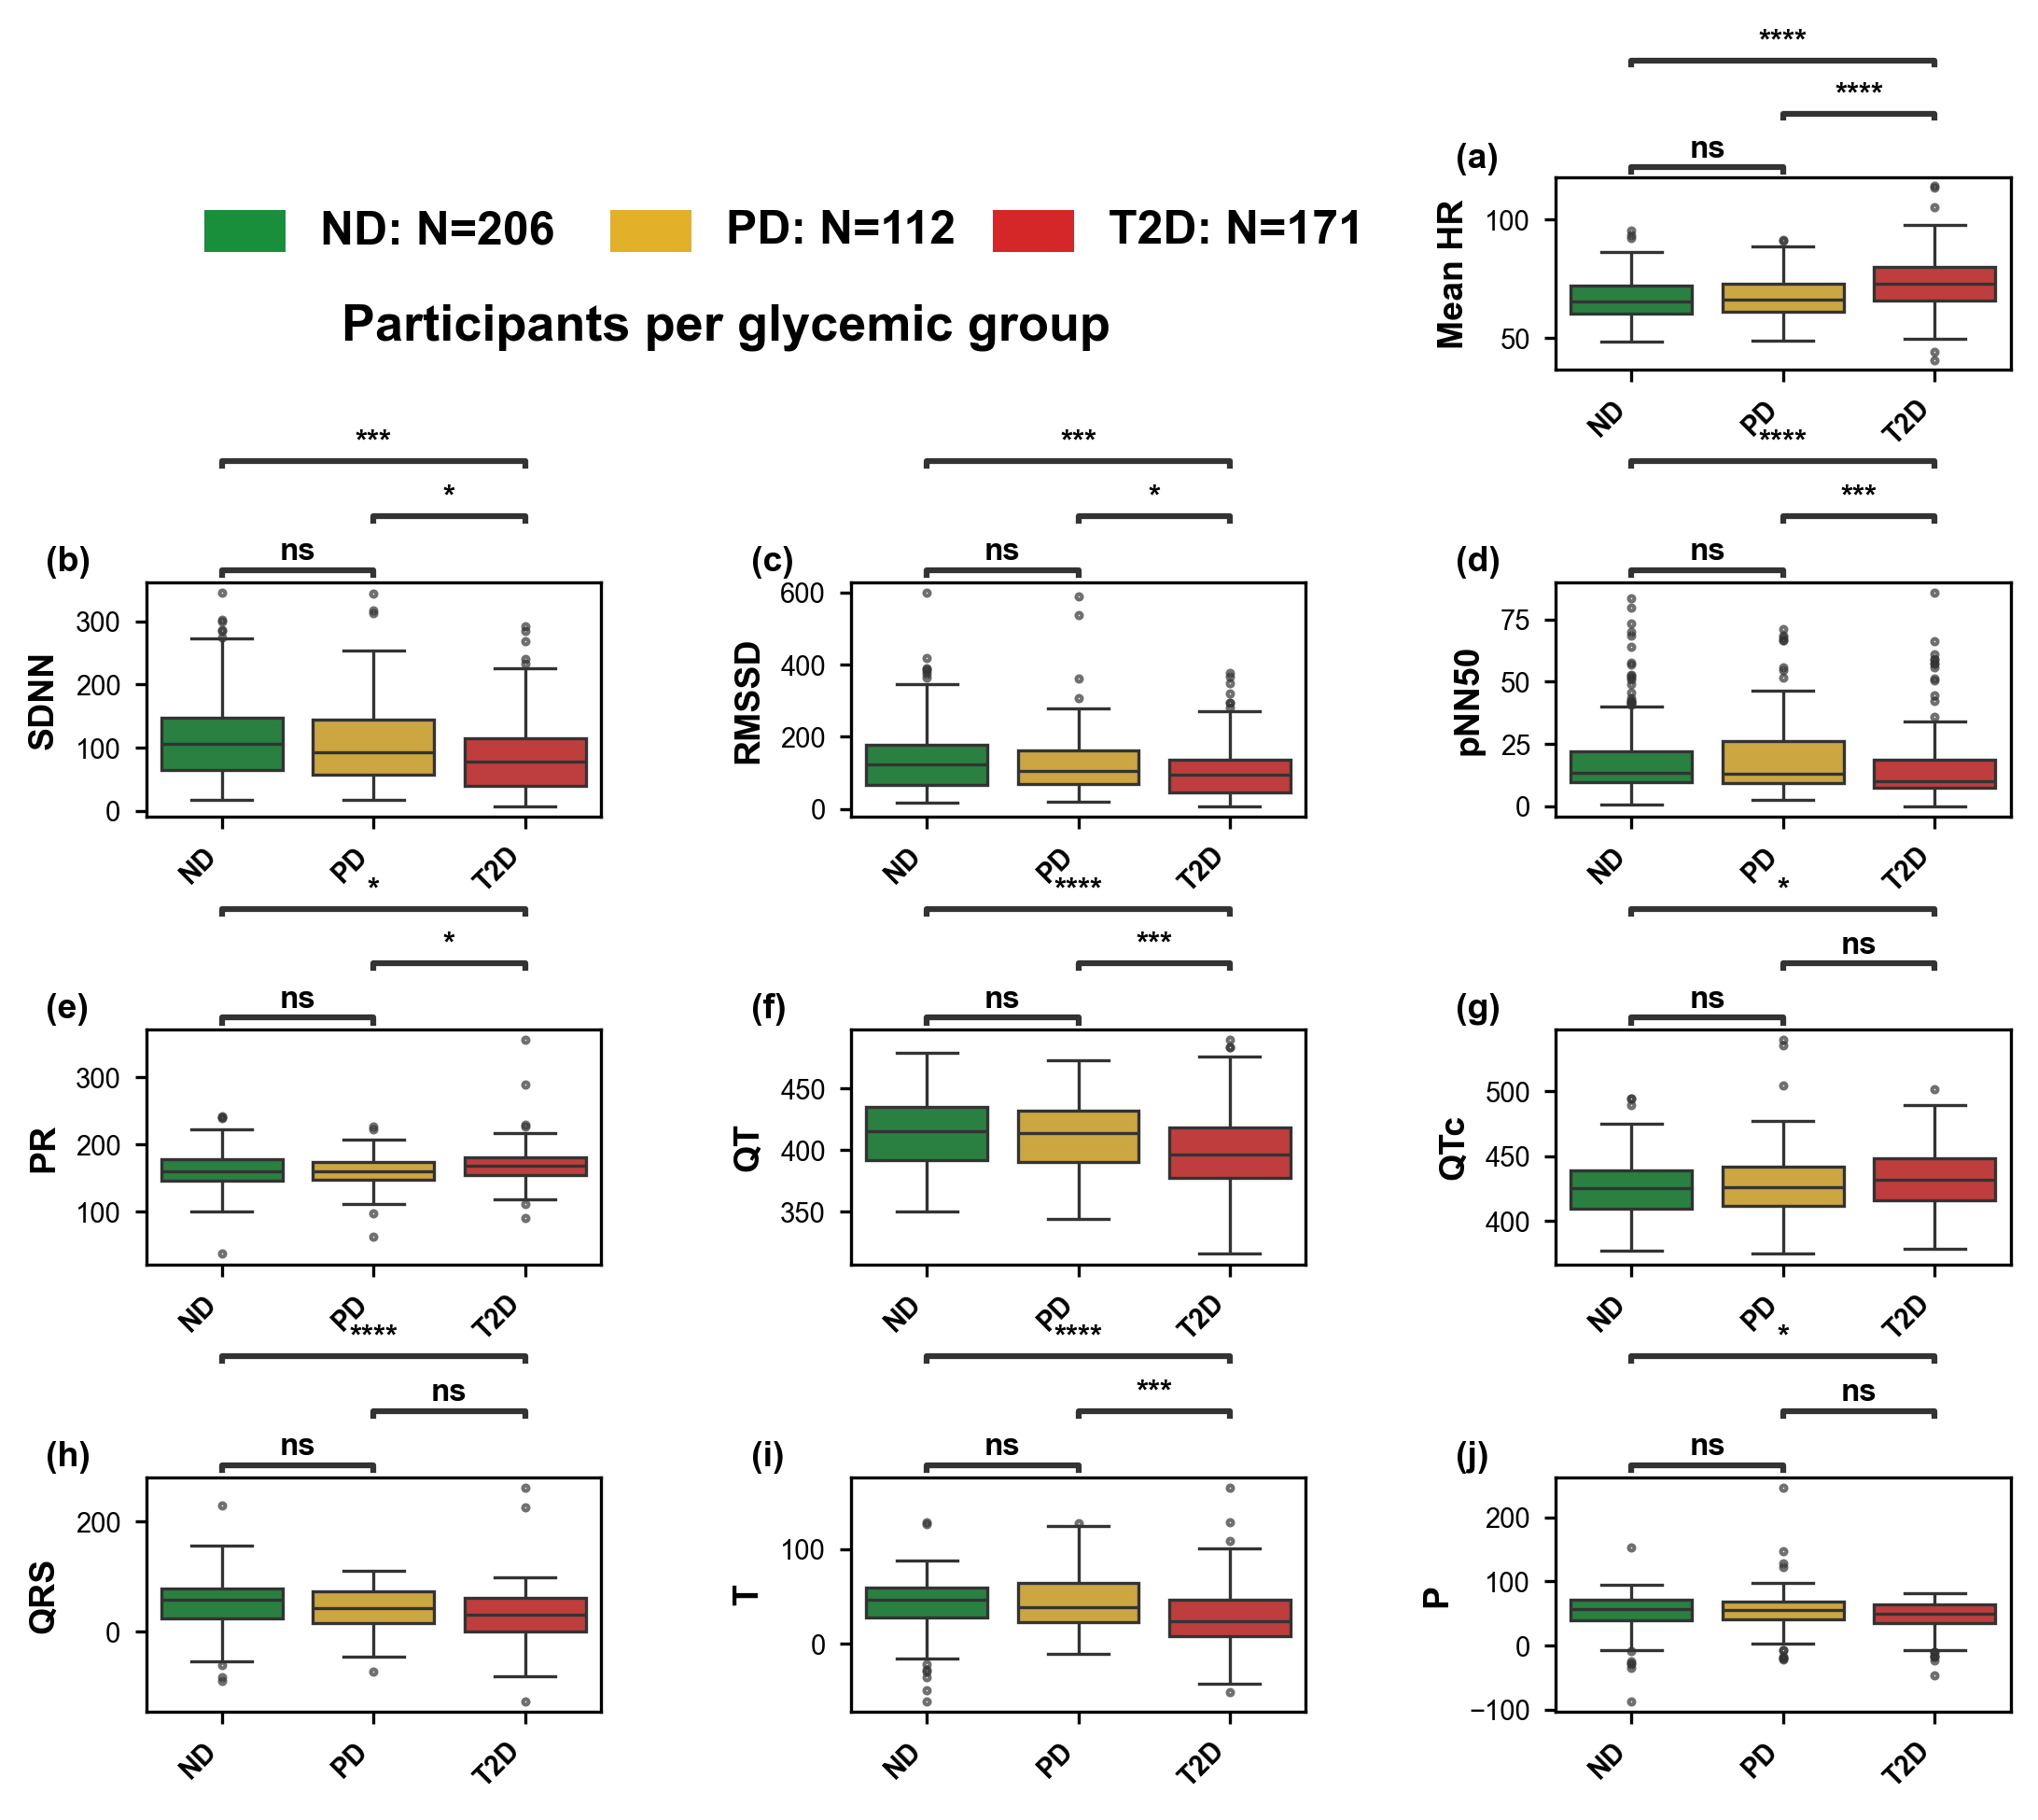

In [8]:
#!/usr/bin/env python3
import os
import matplotlib as mpl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from statannotations.Annotator import Annotator

try:
    import scikit_posthocs as sp
except Exception as e:
    raise ImportError("Install scikit-posthocs via: pip install scikit-posthocs") from e

# -----------------------------------------------------------
# Load data
# -----------------------------------------------------------
df = pd.read_csv("merged_hrv_neurokit_morph_philips_updated_with_age.csv")

def per_feature_df(data, cols):
    return data[cols].dropna()

# -----------------------------------------------------------
# Column alias resolver
# -----------------------------------------------------------
FEATURE_ALIASES = {
    "Mean HR": ["Mean HR", "MeanHR", "Mean_HR"],
    "SDNN": ["SDNN"],
    "RMSSD": ["RMSSD"],
    "pNN50": ["pNN50", "pNN_50", "pnn50"],
    "PR": ["PR"],
    "QT": ["QT"],
    "QTc": ["QTc", "QTC", "QT_C"],
    "QRS": ["QRS"],
    "T": ["T"],
    "P": ["P"],
}

def resolve_col(display_name, columns):
    for c in FEATURE_ALIASES.get(display_name, [display_name]):
        if c in columns:
            return c
    raise KeyError(f"Column not found for {display_name}. Available: {list(columns)[:30]} ...")

# -----------------------------------------------------------
# Glycemic groups (Healthy → ND; merge T2D subtypes)
# -----------------------------------------------------------
df_f1 = df.copy()
status_col = "gly_status_validation"
if status_col not in df_f1.columns:
    if "gly_status_age" in df_f1.columns:
        status_col = "gly_status_age"
    else:
        raise KeyError("Could not find glycemic label column ('gly_status_validation' or 'gly_status_age').")

df_f1[status_col] = df_f1[status_col].replace({
    "Healthy": "ND",
    "T2D_med": "T2D",
    "T2D_insulin": "T2D"
})

groups = ["ND", "PD", "T2D"]
df_f1 = df_f1[df_f1[status_col].isin(groups)]
df_f1[status_col] = pd.Categorical(df_f1[status_col], categories=groups, ordered=True)

class_colors = {"ND": "#1a8f3b", "PD": "#e3b129", "T2D": "#d62728"}
palette = [class_colors[g] for g in groups]
comparisons = [("ND", "PD"), ("ND", "T2D"), ("PD", "T2D")]

# -----------------------------------------------------------
# Feature order (Mean HR above pNN50) + panel labels
# -----------------------------------------------------------
features_ordered = [
    "Mean HR",
    "SDNN", "RMSSD", "pNN50",
    "PR", "QT", "QTc",
    "QRS", "T", "P"
]

panel_label_map = {
    "Mean HR": "(a)",
    "SDNN": "(b)",
    "RMSSD": "(c)",
    "pNN50": "(d)",
    "PR": "(e)",
    "QT": "(f)",
    "QTc": "(g)",
    "QRS": "(h)",
    "T": "(i)",
    "P": "(j)",
}

# -----------------------------------------------------------
# npj Digital Medicine–friendly style (bold axis labels)
# -----------------------------------------------------------
mpl.rcParams.update({
    "font.family": "Arial",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.labelweight": "bold",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.linewidth": 0.8,
    "lines.linewidth": 0.8,
    "figure.dpi": 300,
    "savefig.dpi": 600
})

# -----------------------------------------------------------
# GridSpec (4x3): Mean HR ABOVE pNN50
# -----------------------------------------------------------
fig = plt.figure(figsize=(7.2, 6.3))
gs = fig.add_gridspec(
    nrows=4, ncols=3,
    height_ratios=[0.9, 1.1, 1.1, 1.1]
)

ax_leg = fig.add_subplot(gs[0, 0:2]); ax_leg.axis("off")
ax_meanhr = fig.add_subplot(gs[0, 2])

ax_map = {
    "Mean HR": ax_meanhr,
    "SDNN": fig.add_subplot(gs[1, 0]),
    "RMSSD": fig.add_subplot(gs[1, 1]),
    "pNN50": fig.add_subplot(gs[1, 2]),
    "PR": fig.add_subplot(gs[2, 0]),
    "QT": fig.add_subplot(gs[2, 1]),
    "QTc": fig.add_subplot(gs[2, 2]),
    "QRS": fig.add_subplot(gs[3, 0]),
    "T": fig.add_subplot(gs[3, 1]),
    "P": fig.add_subplot(gs[3, 2]),
}

# -----------------------------------------------------------
# HARDCODED legend (ND / PD / T2D) to match your example
# -----------------------------------------------------------
counts_fixed = {"ND": 206, "PD": 112, "T2D": 171}
x_positions = [0.05, 0.40, 0.73]
y_bar, bar_w, bar_h = 0.72, 0.07, 0.22

for x, g in zip(x_positions, ["ND", "PD", "T2D"]):
    ax_leg.add_patch(Rectangle(
        (x, y_bar - bar_h / 2), bar_w, bar_h,
        transform=ax_leg.transAxes,
        facecolor=class_colors[g], edgecolor="none"
    ))
    ax_leg.text(
        x + bar_w + 0.03, y_bar,
        f"{g}: N={counts_fixed[g]}",
        transform=ax_leg.transAxes,
        fontsize=12, fontweight="bold",
        ha="left", va="center"
    )

ax_leg.text(
    0.50, 0.22,
    "Participants per glycemic group",
    transform=ax_leg.transAxes,
    fontsize=13, fontweight="bold",
    ha="center", va="center"
)

# -----------------------------------------------------------
# Plot function (dot outliers + Dunn-Holm; BOLD y-label & x-ticks)
# -----------------------------------------------------------
def plot_panel(ax, feature):
    col = resolve_col(feature, df_f1.columns)
    sub = per_feature_df(df_f1, [status_col, col])

    sns.boxplot(
        ax=ax, data=sub,
        x=status_col, y=col,
        order=groups, palette=palette,
        linewidth=0.8,
        flierprops=dict(marker=".", markersize=2.8, alpha=0.7)
    )

    # Axis titles (npj multi-panel style: no x-axis title)
    ax.set_xlabel("")
    ax.set_ylabel(feature, fontweight="bold")

    # Make x-tick labels explicitly bold (ND/PD/T2D)
    ax.set_xticklabels(groups, rotation=45, ha="right")
    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")

    # Panel letter
    ax.text(
        -0.22, 1.05,
        panel_label_map[feature],
        transform=ax.transAxes,
        fontsize=9,
        fontweight="bold"
    )

    # Dunn post-hoc (Holm) + annotations
    try:
        dunn = sp.posthoc_dunn(sub, val_col=col, group_col=status_col, p_adjust="holm")
        pvals = [float(dunn.loc[a, b]) for a, b in comparisons]
    except Exception:
        pvals = [1.0, 1.0, 1.0]

    annot = Annotator(ax, comparisons, data=sub, x=status_col, y=col, order=groups)
    annot.configure(text_format="star", loc="outside", verbose=0)
    annot.set_pvalues_and_annotate(pvalues=pvals)

    # Bold stars / ns
    for txt in ax.texts:
        t = txt.get_text()
        if ("*" in t) or (t == "ns"):
            txt.set_fontweight("bold")
            txt.set_fontsize(8)

# -----------------------------------------------------------
# Draw panels
# -----------------------------------------------------------
for feat in features_ordered:
    plot_panel(ax_map[feat], feat)

# -----------------------------------------------------------
# Spacing + Save
# -----------------------------------------------------------
fig.subplots_adjust(
    left=0.07, right=0.995,
    top=0.96, bottom=0.09,
    wspace=0.55, hspace=0.95
)

out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)
base = os.path.join(out_dir, "fig2_npjdmed_3col_MeanHR_above_pNN50_FINAL_boldlabels")

fig.savefig(f"{base}.pdf", bbox_inches="tight", pad_inches=0.01)
fig.savefig(f"{base}.png", dpi=600, bbox_inches="tight", pad_inches=0.01)

print(f"Saved: {base}.pdf and {base}.png")


In [1]:
#!/usr/bin/env python3
"""
Combined confusion-matrix + ROC figure for three binary scenarios:

  Col 1: Healthy vs T2D
  Col 2: Healthy vs PD
  Col 3: T2D vs PD

Top row:
  - Confusion matrices for the best (sampler, model) combo in each scenario
  - Title shows scenario name + classifier code + sampler short code

Bottom row:
  - ROC curves for all three samplers in each scenario (best model per sampler)
  - Text box inside each ROC panel indicating classifier + sampler + AUC
  - Single legend in the last ROC panel

Also produces supplementary figures:
  - For each scenario, 2×3 grid:
      top row: confusion matrices for Under / Up / SMOTE (best model per sampler)
      bottom row: ROC for each sampler with its AUC

Outputs:
  combined_cm_roc_three_scenarios_YYYYMMDD/figs/combined_cm_roc_three_scenarios_YYYYMMDD.(png|pdf)
  combined_cm_roc_three_scenarios_YYYYMMDD/supplementary_figs/supp_cm_roc_all_samplers_*. (png|pdf)
"""

import os, warnings
from collections import OrderedDict, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve, balanced_accuracy_score, average_precision_score,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# --- SMOTE
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    raise ImportError("This script requires 'imbalanced-learn'. Install with:\n"
                      "    pip install imbalanced-learn") from e

warnings.filterwarnings("ignore", category=UserWarning)

# ========= Choose threshold criterion =========
# Options: "balacc" (Youden’s J / Balanced Accuracy) or "f1"
THRESH_CRITERION = "balacc"

# ========= IEEE template styling =========
IEEE_W_DOUBLE = 7.16  # inches

def set_ieee_style():
    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "axes.labelweight": "bold",
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "legend.title_fontsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "lines.markersize": 4,
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

set_ieee_style()
BOLD_FP = FontProperties(weight="bold")

def figsize_double(h=4.2):
    return (IEEE_W_DOUBLE, h)

# ========= IO helpers =========
def make_dir(p):
    if p:
        os.makedirs(p, exist_ok=True)

def safe_fig(path, **kw):
    make_dir(os.path.dirname(path))
    try:
        plt.savefig(path, bbox_inches="tight", **kw)
        print(f"[saved] {path}")
    except PermissionError:
        base, ext = os.path.splitext(path)
        alt = f"{base}_{datetime.now().strftime('%Y%m%d_%H%M%S')}{ext}"
        plt.savefig(alt, bbox_inches="tight", **kw)
        print(f"[warn] '{path}' busy. Saved as '{alt}'.")

# ========= Metric helpers =========
def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

def fold_scores(y_t, y_p, y_pb):
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    aucv = safe_roc_auc(y_t, y_pb)
    auprc = average_precision_score(y_t, y_pb)
    prev = float(np.mean(y_t))
    return dict(
        Accuracy=accuracy_score(y_t, y_p),
        Sensitivity=recall_score(y_t, y_p),
        Specificity=spec,
        F1=f1_score(y_t, y_p),
        AUC=aucv,
        AUPRC=auprc,
        BalAcc=balanced_accuracy_score(y_t, y_p),
        Prevalence=prev,
    )

def best_threshold(y_true, y_prob, criterion="balacc"):
    """Threshold maximizing balanced accuracy or F1."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if criterion.lower() in ("balacc", "youden"):
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        score = (tpr + (1 - fpr)) / 2.0
        idx = int(np.argmax(score))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    elif criterion.lower() == "f1":
        precision, recall, thr = precision_recall_curve(y_true, y_prob)
        f1 = 2 * precision[1:] * recall[1:] / (precision[1:] + recall[1:] + 1e-12)
        if len(f1) == 0 or np.all(~np.isfinite(f1)):
            return 0.5
        idx = int(np.nanargmax(f1))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    else:
        raise ValueError("criterion must be 'balacc' or 'f1'")

# ========= Features, samplers, models =========
FEATURES = ["SDNN","RMSSD","pNN50","Mean HR","Shannon Entropy",
            "PR","QRSD","QT","QTc","P","QRS","T"]

def upsample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    dup = rng.choice(min_, len(maj), True)
    idx = np.concatenate([maj, dup])
    return X[idx], y[idx]

def undersample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    down = rng.choice(maj, len(min_), False)
    idx = np.concatenate([min_, down])
    return X[idx], y[idx]

def smote_sample(X, y, seed=42):
    sm = SMOTE(random_state=seed)
    Xs, ys = sm.fit_resample(X, y)
    return Xs, ys

SAMPLERS = OrderedDict([
    ("Undersample", undersample),
    ("Upsample", upsample),
    ("SMOTE", smote_sample),
])

# Short sampler labels for tight titles/annotations
# "Up" = random upsampling (NOT SMOTE)
SAMPLER_SHORT = {
    "Undersample": "Under",
    "Upsample":   "Up",
    "SMOTE":      "SMOTE",
}

rf_best = RandomForestClassifier(n_estimators=500, random_state=42)
MODELS = OrderedDict([
    ("LR",  LogisticRegression(max_iter=1000, class_weight="balanced")),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis()),
    ("GNB", GaussianNB()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("DT",  DecisionTreeClassifier(random_state=42, class_weight="balanced")),
    ("RF",  CalibratedClassifierCV(rf_best, cv=3, method="isotonic")),
    ("ET",  ExtraTreesClassifier(n_estimators=500, random_state=42)),
    ("ADA", AdaBoostClassifier(n_estimators=300, random_state=42)),
    ("GBC", GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)),
    ("SVM", SVC(kernel="rbf", probability=True, random_state=42)),
    ("MLP", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)),
])

# ========= Data loading (shared) =========
FILE_WITH_AGE = "merged_hrv_neurokit_morph_philips_updated_with_age.csv"
FILE_BASE     = "merged_hrv_neurokit_morph_philips_updated.csv"
FILE_AGE_SRC  = "gly_status_cleaned_no_heart_conditions.csv"

if os.path.exists(FILE_WITH_AGE):
    base_df = pd.read_csv(FILE_WITH_AGE)
else:
    base_df = pd.read_csv(FILE_BASE)
    age_df  = pd.read_csv(FILE_AGE_SRC)
    base_df = base_df.rename(columns={"Participant": "person_id"})
    base_df = base_df.merge(
        age_df[["person_id", "age"]],
        on="person_id",
        how="left",
        validate="many_to_one",
    )
    base_df.to_csv(FILE_WITH_AGE, index=False)

# ========= Scenario runner =========
def run_scenario(name, mask_pos, mask_neg, class_names, positive_is_pos=True):
    """
    name: e.g. 'Healthy vs T2D'
    mask_pos, mask_neg: boolean masks on base_df (positive class, negative class)
    class_names: [negative_label, positive_label]
    positive_is_pos: if True, mask_pos -> label 1, mask_neg -> 0
    """
    df = base_df.dropna(subset=["age"]).loc[mask_pos | mask_neg].copy()

    if positive_is_pos:
        df["label"] = np.where(mask_pos.loc[df.index], 1, 0)
    else:
        df["label"] = np.where(mask_pos.loc[df.index], 0, 1)

    # Age-stratified CV labels (age-bin + class)
    NBINS = 5
    df["age_bin"] = pd.qcut(df["age"], q=NBINS, labels=False, duplicates="drop")
    df = df[df["age_bin"].notna()].copy()
    df["stratify_group"] = (
        df["label"].astype(str) + "_" + df["age_bin"].astype(int).astype(str)
    )

    X_all = df[FEATURES].values
    y_all = df["label"].values
    stratify_labels = df["stratify_group"].values

    # CV splits
    K = 5
    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
    splits = list(skf.split(X_all, stratify_labels))

    # KW feature selection per fold (train only)
    KW_ALPHA  = 0.05
    MIN_FEATS = 5
    fold_feature_sets = {}

    for fold_id, (tr_idx, te_idx) in enumerate(splits, 1):
        dtr = df.iloc[tr_idx].copy()
        pvals = []
        for feat in FEATURES:
            a = dtr.loc[dtr["label"] == 0, feat].dropna().values
            b = dtr.loc[dtr["label"] == 1, feat].dropna().values
            if len(a) > 0 and len(b) > 0:
                try:
                    _, p = stats.kruskal(a, b)
                except Exception:
                    p = np.nan
            else:
                p = np.nan
            pvals.append((feat, p))
        ptab = pd.DataFrame(pvals, columns=["feature","KW_p"]).sort_values("KW_p")
        sel = ptab.loc[ptab["KW_p"] < KW_ALPHA, "feature"].tolist()
        if len(sel) == 0:
            sel = ptab["feature"].head(min(MIN_FEATS, len(FEATURES))).tolist()
        fold_feature_sets[fold_id] = sel

    # Train & evaluate
    metrics = defaultdict(list)
    roc_store = defaultdict(lambda: defaultdict(list))

    for samp, samp_fn in SAMPLERS.items():
        for mdl_name, mdl in MODELS.items():
            for fold_id, (tr, te) in enumerate(splits, 1):
                sel_feats = fold_feature_sets[fold_id]
                sel_idx = [FEATURES.index(f) for f in sel_feats]

                # 1) Impute within fold
                X_tr_raw = np.where(np.isfinite(X_all[tr][:, sel_idx]),
                                    X_all[tr][:, sel_idx], np.nan)
                X_te_raw = np.where(np.isfinite(X_all[te][:, sel_idx]),
                                    X_all[te][:, sel_idx], np.nan)
                imputer = SimpleImputer(strategy="median")
                X_tr_imp = imputer.fit_transform(X_tr_raw)
                X_te_imp = imputer.transform(X_te_raw)

                # 2) Scale within fold
                scaler = StandardScaler().fit(X_tr_imp)
                X_tr = scaler.transform(X_tr_imp)
                X_te = scaler.transform(X_te_imp)

                # 3) Balance only the training data (sampler-specific)
                X_bal, y_bal = samp_fn(X_tr, y_all[tr])

                # 4) Fit model
                mdl.fit(X_bal, y_bal)

                # 5) Predict on test fold
                if hasattr(mdl, "predict_proba"):
                    y_prob = mdl.predict_proba(X_te)[:, 1]
                else:
                    s = mdl.decision_function(X_te)
                    y_prob = (s - s.min()) / (s.ptp() + 1e-9)
                y_pred = (y_prob > 0.5).astype(int)

                fold_dict = fold_scores(y_all[te], y_pred, y_prob)
                fold_dict.update({"Fold": fold_id, "n_features": len(sel_feats)})
                metrics[(samp, mdl_name)].append(fold_dict)
                roc_store[samp][mdl_name].append((y_all[te], y_prob))

    # Best model per sampler (by mean AUC), then overall best sampler
    best_models = {}
    sampler_auc_means = {}
    for samp in SAMPLERS:
        best_auc, best_m = -np.inf, None
        for mdl in MODELS:
            rows = metrics[(samp, mdl)]
            aucs = [d["AUC"] for d in rows if not np.isnan(d["AUC"])]
            if not aucs:
                continue
            m = float(np.mean(aucs))
            if m > best_auc:
                best_auc, best_m = m, mdl
        if best_m is not None:
            best_models[samp] = best_m
            sampler_auc_means[samp] = best_auc

    if not best_models:
        raise RuntimeError(f"No valid models for scenario '{name}'")

    # Overall best sampler = highest AUC mean
    overall_best_sampler = max(sampler_auc_means.items(), key=lambda kv: kv[1])[0]
    overall_best_model = best_models[overall_best_sampler]

    # Gather CV predictions for overall best combo
    ys = roc_store[overall_best_sampler][overall_best_model]
    y_true_all = np.concatenate([t for t, _ in ys])
    y_prob_all = np.concatenate([p for _, p in ys])
    thr = best_threshold(y_true_all, y_prob_all, criterion=THRESH_CRITERION)
    y_hat_all = (y_prob_all > thr).astype(int)

    cm = confusion_matrix(y_true_all, y_hat_all, labels=[0, 1])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    bal_acc = balanced_accuracy_score(y_true_all, y_hat_all)
    auc_overall = safe_roc_auc(y_true_all, y_prob_all)

    # ROC curves per sampler (using that sampler's best model)
    roc_curves = {}
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true_s, y_prob_s)
        roc_curves[samp] = (fpr, tpr)

    # ---------- Per-sampler summaries for supplementary figs ----------
    per_sampler = {}  # samp -> dict with CM, AUC, ROC, etc.
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue

        fpr_s, tpr_s, _ = roc_curve(y_true_s, y_prob_s)
        auc_s = safe_roc_auc(y_true_s, y_prob_s)
        thr_s = best_threshold(y_true_s, y_prob_s, criterion=THRESH_CRITERION)
        y_hat_s = (y_prob_s > thr_s).astype(int)
        cm_s = confusion_matrix(y_true_s, y_hat_s, labels=[0, 1])
        cm_norm_s = cm_s / cm_s.sum(axis=1, keepdims=True)

        per_sampler[samp] = dict(
            model=mdl,
            auc=auc_s,
            thr=thr_s,
            cm=cm_s,
            cm_norm=cm_norm_s,
            fpr=fpr_s,
            tpr=tpr_s,
        )

    return dict(
        name=name,
        class_names=class_names,
        cm=cm,
        cm_norm=cm_norm,
        bal_acc=bal_acc,
        auc=auc_overall,
        thr=thr,
        roc_curves=roc_curves,
        best_sampler=overall_best_sampler,
        best_model=overall_best_model,
        per_sampler=per_sampler,
    )

# ========= Run three scenarios =========
gly = base_df["gly_status_validation"].astype(str)

mask_healthy = gly.str.startswith("Healthy", na=False)
mask_t2d     = gly.str.startswith("T2D",     na=False)
mask_pd      = gly.str.startswith("PD",      na=False)

scenarios = [
    run_scenario("Healthy vs T2D",
                 mask_pos=mask_t2d,
                 mask_neg=mask_healthy,
                 class_names=["Healthy", "T2D"],
                 positive_is_pos=True),
    run_scenario("Healthy vs PD",
                 mask_pos=mask_pd,
                 mask_neg=mask_healthy,
                 class_names=["Healthy", "PD"],
                 positive_is_pos=True),
    run_scenario("T2D vs PD",
                 mask_pos=mask_pd,
                 mask_neg=mask_t2d,
                 class_names=["T2D", "PD"],
                 positive_is_pos=True),
]

# ========= Combined main figure =========
DATE_TAG_FMT = "%Y%m%d"
DATE_TAG = datetime.now().strftime(DATE_TAG_FMT)
OUTROOT = f"combined_cm_roc_three_scenarios_{DATE_TAG}"
FIGDIR = os.path.join(OUTROOT, "figs")
make_dir(FIGDIR)

sns.set_style("white")
fig, axes = plt.subplots(2, 3, figsize=figsize_double(h=4.2))
top_axes = axes[0, :]
bot_axes = axes[1, :]

panel_labels = [["(a)", "(b)", "(c)"],
                ["(d)", "(e)", "(f)"]]

# ---------- Top row: confusion matrices ----------
heatmaps = []
for col, sc in enumerate(scenarios):
    ax = top_axes[col]
    cm_norm = sc["cm_norm"]
    cm = sc["cm"]

    annot = [[f"{int(cnt)}\n({pct:.1%})"
              for cnt, pct in zip(row_counts, row_pct)]
             for row_counts, row_pct in zip(cm, cm_norm)]

    h = sns.heatmap(
        cm_norm,
        annot=annot,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar=False,
        square=True,
        xticklabels=sc["class_names"],
        yticklabels=sc["class_names"],
        annot_kws={"weight": "bold", "fontsize": 7},
        ax=ax,
    )
    heatmaps.append(h)

    ax.set_xlabel("Predicted label", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True label", fontweight="bold")
    else:
        ax.set_ylabel("")

    mdl_code = sc["best_model"]      # e.g. "LR", "GBC"
    samp_code = sc["best_sampler"]   # e.g. "Upsample"
    samp_short = SAMPLER_SHORT.get(samp_code, samp_code)

    ax.set_title(
        f"{sc['name']} – {mdl_code} ({samp_short})",
        fontweight="bold",
        pad=4,
    )

    # panel labels outside box
    ax.text(
        -0.18, 1.08,
        panel_labels[0][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

# ---------- Bottom row: ROC curves ----------
colors = plt.cm.tab10(np.linspace(0, 1, len(SAMPLERS)))

for col, sc in enumerate(scenarios):
    ax = bot_axes[col]
    best_samp = sc["best_sampler"]
    best_model = sc["best_model"]
    best_auc = sc["auc"]

    # ROC curves for all samplers
    for (samp, color) in zip(SAMPLERS.keys(), colors):
        if samp not in sc["roc_curves"]:
            continue
        fpr, tpr = sc["roc_curves"][samp]
        lw = 1.8 if samp == best_samp else 1.0
        ax.plot(fpr, tpr, label=samp, color=color, lw=lw)

    ax.plot([0, 1], [0, 1], "k--", lw=0.8)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False positive rate", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True positive rate", fontweight="bold")
    else:
        ax.set_ylabel("")

    ax.set_title(f"ROC – {sc['name']}", fontweight="bold", pad=4)

    # Classifier + sampler + AUC text, top-left
    samp_short = SAMPLER_SHORT.get(best_samp, best_samp)
    ax.text(
        0.02, 0.98,
        f"{best_model} ({samp_short}, AUC = {best_auc:.2f})",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=6,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="gray", lw=0.5)
    )

    # panel labels outside box
    ax.text(
        -0.18, 1.08,
        panel_labels[1][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

# ---------- Shared legend for ROC curves ----------
handles, labels = bot_axes[0].get_legend_handles_labels()
if handles:
    leg = bot_axes[2].legend(
        handles, labels,
        title="Sampling strategy",
        loc="lower right",
        frameon=True,
    )
    leg.get_title().set_fontproperties(BOLD_FP)

# ---------- Shared colorbar on the far right ----------
fig.tight_layout(rect=[0.0, 0.0, 0.9, 1.0])

cax = fig.add_axes([0.92, 0.55, 0.015, 0.3])
cbar = fig.colorbar(heatmaps[0].collections[0], cax=cax)
cbar.set_label("Proportion within true class", fontweight="bold")

# ---------- Save main figure ----------
png_path = os.path.join(FIGDIR, f"combined_cm_roc_three_scenarios_{DATE_TAG}.png")
pdf_path = os.path.join(FIGDIR, f"combined_cm_roc_three_scenarios_{DATE_TAG}.pdf")
safe_fig(png_path)
safe_fig(pdf_path)
plt.close(fig)

# ========= Supplementary figures: per-sampler CM + ROC per scenario =========
SUPP_DIR = os.path.join(OUTROOT, "supplementary_figs")
make_dir(SUPP_DIR)

for sidx, sc in enumerate(scenarios, start=1):
    fig_s, axes_s = plt.subplots(2, 3, figsize=figsize_double(h=4.2))
    top_axes_s = axes_s[0, :]
    bot_axes_s = axes_s[1, :]

    samplers_order = list(SAMPLERS.keys())
    panel_labels_supp = [["(a)", "(b)", "(c)"],
                         ["(d)", "(e)", "(f)"]]

    for col, samp in enumerate(samplers_order):
        info = sc["per_sampler"].get(samp, None)
        if info is None:
            top_axes_s[col].axis("off")
            bot_axes_s[col].axis("off")
            continue

        # ----- Top row: CM for this sampler -----
        ax_cm = top_axes_s[col]
        cm_norm = info["cm_norm"]
        cm = info["cm"]

        annot = [[f"{int(cnt)}\n({pct:.1%})"
                  for cnt, pct in zip(row_counts, row_pct)]
                 for row_counts, row_pct in zip(cm, cm_norm)]

        sns.heatmap(
            cm_norm,
            annot=annot,
            fmt="",
            cmap="Blues",
            vmin=0,
            vmax=1,
            cbar=False,
            square=True,
            xticklabels=sc["class_names"],
            yticklabels=sc["class_names"],
            annot_kws={"weight": "bold", "fontsize": 7},
            ax=ax_cm,
        )

        ax_cm.set_xlabel("Predicted label", fontweight="bold")
        if col == 0:
            ax_cm.set_ylabel("True label", fontweight="bold")
        else:
            ax_cm.set_ylabel("")

        samp_short = SAMPLER_SHORT.get(samp, samp)
        ax_cm.set_title(
            f"{sc['name']} – {info['model']} ({samp_short})",
            fontweight="bold", pad=4
        )

        # panel label for top row
        ax_cm.text(
            -0.18, 1.08,
            panel_labels_supp[0][col],
            transform=ax_cm.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

        # ----- Bottom row: ROC for this sampler -----
        ax_roc = bot_axes_s[col]
        fpr_s, tpr_s = info["fpr"], info["tpr"]
        ax_roc.plot(fpr_s, tpr_s, lw=1.5)
        ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8)

        ax_roc.set_xlim(0, 1)
        ax_roc.set_ylim(0, 1)
        ax_roc.set_xlabel("False positive rate", fontweight="bold")
        if col == 0:
            ax_roc.set_ylabel("True positive rate", fontweight="bold")
        else:
            ax_roc.set_ylabel("")

        ax_roc.set_title(
            f"ROC – {sc['name']} ({samp_short})",
            fontweight="bold", pad=4
        )

        ax_roc.text(
            0.02, 0.98,
            f"{info['model']} ({samp_short}, AUC = {info['auc']:.2f})",
            transform=ax_roc.transAxes,
            ha="left", va="top",
            fontsize=6, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15",
                      fc="white", ec="gray", lw=0.5),
        )

        # panel label for bottom row
        ax_roc.text(
            -0.18, 1.08,
            panel_labels_supp[1][col],
            transform=ax_roc.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

    fig_s.tight_layout()
    base_name = f"supp_cm_roc_all_samplers_{sidx}_{sc['name'].replace(' ', '_')}"
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.png"))
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.pdf"))
    plt.close(fig_s)

print("\nDONE. Outputs in:", OUTROOT)
print("  - Main figure:", png_path)
print("  - Supplementary figs in:", SUPP_DIR)


C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated a

[saved] combined_cm_roc_three_scenarios_20260130\figs\combined_cm_roc_three_scenarios_20260130.png
[saved] combined_cm_roc_three_scenarios_20260130\figs\combined_cm_roc_three_scenarios_20260130.pdf
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_1_Healthy_vs_T2D.png
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_1_Healthy_vs_T2D.pdf
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_2_Healthy_vs_PD.png
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_2_Healthy_vs_PD.pdf
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_3_T2D_vs_PD.png
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_3_T2D_vs_PD.pdf

DONE. Outputs in: combined_cm_roc_three_scenarios_20260130
  - Main figure: combined_cm_roc_three_scenarios_20260130\figs\combine

In [2]:
#!/usr/bin/env python3
"""
Combined confusion-matrix + ROC figure for three binary scenarios:

  Col 1: ND vs T2D
  Col 2: ND vs PD
  Col 3: T2D vs PD

Top row:
  - Confusion matrices for the best (sampler, model) combo in each scenario
  - Title shows scenario name + classifier code + sampler short code

Bottom row:
  - ROC curves for all three samplers in each scenario (best model per sampler)
  - Text box inside each ROC panel indicating classifier + sampler + AUC
  - Single legend in the last ROC panel

Also produces supplementary figures:
  - For each scenario, 2×3 grid:
      top row: confusion matrices for Under / Up / SMOTE (best model per sampler)
      bottom row: ROC for each sampler with its AUC

Outputs:
  combined_cm_roc_three_scenarios_YYYYMMDD/figs/combined_cm_roc_three_scenarios_YYYYMMDD.(png|pdf)
  combined_cm_roc_three_scenarios_YYYYMMDD/supplementary_figs/supp_cm_roc_all_samplers_*. (png|pdf)
"""

import os, warnings
from collections import OrderedDict, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve, balanced_accuracy_score, average_precision_score,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# --- SMOTE
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    raise ImportError("This script requires 'imbalanced-learn'. Install with:\n"
                      "    pip install imbalanced-learn") from e

warnings.filterwarnings("ignore", category=UserWarning)

# ========= Choose threshold criterion =========
# Options: "balacc" (Youden’s J / Balanced Accuracy) or "f1"
THRESH_CRITERION = "balacc"

# ========= IEEE template styling =========
IEEE_W_DOUBLE = 7.16  # inches

def set_ieee_style():
    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "axes.labelweight": "bold",
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "legend.title_fontsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "lines.markersize": 4,
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

set_ieee_style()
BOLD_FP = FontProperties(weight="bold")

def figsize_double(h=4.2):
    return (IEEE_W_DOUBLE, h)

# ========= IO helpers =========
def make_dir(p):
    if p:
        os.makedirs(p, exist_ok=True)

def safe_fig(path, **kw):
    make_dir(os.path.dirname(path))
    try:
        plt.savefig(path, bbox_inches="tight", **kw)
        print(f"[saved] {path}")
    except PermissionError:
        base, ext = os.path.splitext(path)
        alt = f"{base}_{datetime.now().strftime('%Y%m%d_%H%M%S')}{ext}"
        plt.savefig(alt, bbox_inches="tight", **kw)
        print(f"[warn] '{path}' busy. Saved as '{alt}'.")

# ========= Metric helpers =========
def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

def fold_scores(y_t, y_p, y_pb):
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    aucv = safe_roc_auc(y_t, y_pb)
    auprc = average_precision_score(y_t, y_pb)
    prev = float(np.mean(y_t))
    return dict(
        Accuracy=accuracy_score(y_t, y_p),
        Sensitivity=recall_score(y_t, y_p),
        Specificity=spec,
        F1=f1_score(y_t, y_p),
        AUC=aucv,
        AUPRC=auprc,
        BalAcc=balanced_accuracy_score(y_t, y_p),
        Prevalence=prev,
    )

def best_threshold(y_true, y_prob, criterion="balacc"):
    """Threshold maximizing balanced accuracy or F1."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if criterion.lower() in ("balacc", "youden"):
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        score = (tpr + (1 - fpr)) / 2.0
        idx = int(np.argmax(score))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    elif criterion.lower() == "f1":
        precision, recall, thr = precision_recall_curve(y_true, y_prob)
        f1 = 2 * precision[1:] * recall[1:] / (precision[1:] + recall[1:] + 1e-12)
        if len(f1) == 0 or np.all(~np.isfinite(f1)):
            return 0.5
        idx = int(np.nanargmax(f1))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    else:
        raise ValueError("criterion must be 'balacc' or 'f1'")

# ========= Features, samplers, models =========
FEATURES = ["SDNN","RMSSD","pNN50","Mean HR","Shannon Entropy",
            "PR","QRSD","QT","QTc","P","QRS","T"]

def upsample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    dup = rng.choice(min_, len(maj), True)
    idx = np.concatenate([maj, dup])
    return X[idx], y[idx]

def undersample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    down = rng.choice(maj, len(min_), False)
    idx = np.concatenate([min_, down])
    return X[idx], y[idx]

def smote_sample(X, y, seed=42):
    sm = SMOTE(random_state=seed)
    Xs, ys = sm.fit_resample(X, y)
    return Xs, ys

SAMPLERS = OrderedDict([
    ("Undersample", undersample),
    ("Upsample", upsample),
    ("SMOTE", smote_sample),
])

# Short sampler labels for tight titles/annotations
# "Up" = random upsampling (NOT SMOTE)
SAMPLER_SHORT = {
    "Undersample": "Under",
    "Upsample":   "Up",
    "SMOTE":      "SMOTE",
}

rf_best = RandomForestClassifier(n_estimators=500, random_state=42)
MODELS = OrderedDict([
    ("LR",  LogisticRegression(max_iter=1000, class_weight="balanced")),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis()),
    ("GNB", GaussianNB()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("DT",  DecisionTreeClassifier(random_state=42, class_weight="balanced")),
    ("RF",  CalibratedClassifierCV(rf_best, cv=3, method="isotonic")),
    ("ET",  ExtraTreesClassifier(n_estimators=500, random_state=42)),
    ("ADA", AdaBoostClassifier(n_estimators=300, random_state=42)),
    ("GBC", GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)),
    ("SVM", SVC(kernel="rbf", probability=True, random_state=42)),
    ("MLP", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)),
])

# ========= Data loading (shared) =========
FILE_WITH_AGE = "merged_hrv_neurokit_morph_philips_updated_with_age.csv"
FILE_BASE     = "merged_hrv_neurokit_morph_philips_updated.csv"
FILE_AGE_SRC  = "gly_status_cleaned_no_heart_conditions.csv"

if os.path.exists(FILE_WITH_AGE):
    base_df = pd.read_csv(FILE_WITH_AGE)
else:
    base_df = pd.read_csv(FILE_BASE)
    age_df  = pd.read_csv(FILE_AGE_SRC)
    base_df = base_df.rename(columns={"Participant": "person_id"})
    base_df = base_df.merge(
        age_df[["person_id", "age"]],
        on="person_id",
        how="left",
        validate="many_to_one",
    )
    base_df.to_csv(FILE_WITH_AGE, index=False)

# ========= Scenario runner =========
def run_scenario(name, mask_pos, mask_neg, class_names, positive_is_pos=True):
    """
    name: e.g. 'ND vs T2D'
    mask_pos, mask_neg: boolean masks on base_df (positive class, negative class)
    class_names: [negative_label, positive_label]  (display labels)
    positive_is_pos: if True, mask_pos -> label 1, mask_neg -> 0
    """
    df = base_df.dropna(subset=["age"]).loc[mask_pos | mask_neg].copy()

    if positive_is_pos:
        df["label"] = np.where(mask_pos.loc[df.index], 1, 0)
    else:
        df["label"] = np.where(mask_pos.loc[df.index], 0, 1)

    # Age-stratified CV labels (age-bin + class)
    NBINS = 5
    df["age_bin"] = pd.qcut(df["age"], q=NBINS, labels=False, duplicates="drop")
    df = df[df["age_bin"].notna()].copy()
    df["stratify_group"] = (
        df["label"].astype(str) + "_" + df["age_bin"].astype(int).astype(str)
    )

    X_all = df[FEATURES].values
    y_all = df["label"].values
    stratify_labels = df["stratify_group"].values

    # CV splits
    K = 5
    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
    splits = list(skf.split(X_all, stratify_labels))

    # KW feature selection per fold (train only)
    KW_ALPHA  = 0.05
    MIN_FEATS = 5
    fold_feature_sets = {}

    for fold_id, (tr_idx, te_idx) in enumerate(splits, 1):
        dtr = df.iloc[tr_idx].copy()
        pvals = []
        for feat in FEATURES:
            a = dtr.loc[dtr["label"] == 0, feat].dropna().values
            b = dtr.loc[dtr["label"] == 1, feat].dropna().values
            if len(a) > 0 and len(b) > 0:
                try:
                    _, p = stats.kruskal(a, b)
                except Exception:
                    p = np.nan
            else:
                p = np.nan
            pvals.append((feat, p))
        ptab = pd.DataFrame(pvals, columns=["feature","KW_p"]).sort_values("KW_p")
        sel = ptab.loc[ptab["KW_p"] < KW_ALPHA, "feature"].tolist()
        if len(sel) == 0:
            sel = ptab["feature"].head(min(MIN_FEATS, len(FEATURES))).tolist()
        fold_feature_sets[fold_id] = sel

    # Train & evaluate
    metrics = defaultdict(list)
    roc_store = defaultdict(lambda: defaultdict(list))

    for samp, samp_fn in SAMPLERS.items():
        for mdl_name, mdl in MODELS.items():
            for fold_id, (tr, te) in enumerate(splits, 1):
                sel_feats = fold_feature_sets[fold_id]
                sel_idx = [FEATURES.index(f) for f in sel_feats]

                # 1) Impute within fold
                X_tr_raw = np.where(np.isfinite(X_all[tr][:, sel_idx]),
                                    X_all[tr][:, sel_idx], np.nan)
                X_te_raw = np.where(np.isfinite(X_all[te][:, sel_idx]),
                                    X_all[te][:, sel_idx], np.nan)
                imputer = SimpleImputer(strategy="median")
                X_tr_imp = imputer.fit_transform(X_tr_raw)
                X_te_imp = imputer.transform(X_te_raw)

                # 2) Scale within fold
                scaler = StandardScaler().fit(X_tr_imp)
                X_tr = scaler.transform(X_tr_imp)
                X_te = scaler.transform(X_te_imp)

                # 3) Balance only the training data (sampler-specific)
                X_bal, y_bal = samp_fn(X_tr, y_all[tr])

                # 4) Fit model
                mdl.fit(X_bal, y_bal)

                # 5) Predict on test fold
                if hasattr(mdl, "predict_proba"):
                    y_prob = mdl.predict_proba(X_te)[:, 1]
                else:
                    s = mdl.decision_function(X_te)
                    y_prob = (s - s.min()) / (s.ptp() + 1e-9)
                y_pred = (y_prob > 0.5).astype(int)

                fold_dict = fold_scores(y_all[te], y_pred, y_prob)
                fold_dict.update({"Fold": fold_id, "n_features": len(sel_feats)})
                metrics[(samp, mdl_name)].append(fold_dict)
                roc_store[samp][mdl_name].append((y_all[te], y_prob))

    # Best model per sampler (by mean AUC), then overall best sampler
    best_models = {}
    sampler_auc_means = {}
    for samp in SAMPLERS:
        best_auc, best_m = -np.inf, None
        for mdl in MODELS:
            rows = metrics[(samp, mdl)]
            aucs = [d["AUC"] for d in rows if not np.isnan(d["AUC"])]
            if not aucs:
                continue
            m = float(np.mean(aucs))
            if m > best_auc:
                best_auc, best_m = m, mdl
        if best_m is not None:
            best_models[samp] = best_m
            sampler_auc_means[samp] = best_auc

    if not best_models:
        raise RuntimeError(f"No valid models for scenario '{name}'")

    # Overall best sampler = highest AUC mean
    overall_best_sampler = max(sampler_auc_means.items(), key=lambda kv: kv[1])[0]
    overall_best_model = best_models[overall_best_sampler]

    # Gather CV predictions for overall best combo
    ys = roc_store[overall_best_sampler][overall_best_model]
    y_true_all = np.concatenate([t for t, _ in ys])
    y_prob_all = np.concatenate([p for _, p in ys])
    thr = best_threshold(y_true_all, y_prob_all, criterion=THRESH_CRITERION)
    y_hat_all = (y_prob_all > thr).astype(int)

    cm = confusion_matrix(y_true_all, y_hat_all, labels=[0, 1])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    bal_acc = balanced_accuracy_score(y_true_all, y_hat_all)
    auc_overall = safe_roc_auc(y_true_all, y_prob_all)

    # ROC curves per sampler (using that sampler's best model)
    roc_curves = {}
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true_s, y_prob_s)
        roc_curves[samp] = (fpr, tpr)

    # ---------- Per-sampler summaries for supplementary figs ----------
    per_sampler = {}  # samp -> dict with CM, AUC, ROC, etc.
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue

        fpr_s, tpr_s, _ = roc_curve(y_true_s, y_prob_s)
        auc_s = safe_roc_auc(y_true_s, y_prob_s)
        thr_s = best_threshold(y_true_s, y_prob_s, criterion=THRESH_CRITERION)
        y_hat_s = (y_prob_s > thr_s).astype(int)
        cm_s = confusion_matrix(y_true_s, y_hat_s, labels=[0, 1])
        cm_norm_s = cm_s / cm_s.sum(axis=1, keepdims=True)

        per_sampler[samp] = dict(
            model=mdl,
            auc=auc_s,
            thr=thr_s,
            cm=cm_s,
            cm_norm=cm_norm_s,
            fpr=fpr_s,
            tpr=tpr_s,
        )

    return dict(
        name=name,
        class_names=class_names,   # <-- display labels used by heatmaps
        cm=cm,
        cm_norm=cm_norm,
        bal_acc=bal_acc,
        auc=auc_overall,
        thr=thr,
        roc_curves=roc_curves,
        best_sampler=overall_best_sampler,
        best_model=overall_best_model,
        per_sampler=per_sampler,
    )

# ========= Run three scenarios =========
gly = base_df["gly_status_validation"].astype(str)

mask_healthy = gly.str.startswith("Healthy", na=False)
mask_t2d     = gly.str.startswith("T2D",     na=False)
mask_pd      = gly.str.startswith("PD",      na=False)

# NOTE:
# - We KEEP the data selection using "Healthy..." in the raw column,
# - but we DISPLAY that group as "ND" in all confusion matrices via class_names.
scenarios = [
    run_scenario("ND vs T2D",
                 mask_pos=mask_t2d,
                 mask_neg=mask_healthy,
                 class_names=["ND", "T2D"],
                 positive_is_pos=True),
    run_scenario("ND vs PD",
                 mask_pos=mask_pd,
                 mask_neg=mask_healthy,
                 class_names=["ND", "PD"],
                 positive_is_pos=True),
    run_scenario("T2D vs PD",
                 mask_pos=mask_pd,
                 mask_neg=mask_t2d,
                 class_names=["T2D", "PD"],
                 positive_is_pos=True),
]

# ========= Combined main figure =========
DATE_TAG_FMT = "%Y%m%d"
DATE_TAG = datetime.now().strftime(DATE_TAG_FMT)
OUTROOT = f"combined_cm_roc_three_scenarios_{DATE_TAG}"
FIGDIR = os.path.join(OUTROOT, "figs")
make_dir(FIGDIR)

sns.set_style("white")
fig, axes = plt.subplots(2, 3, figsize=figsize_double(h=4.2))
top_axes = axes[0, :]
bot_axes = axes[1, :]

panel_labels = [["(a)", "(b)", "(c)"],
                ["(d)", "(e)", "(f)"]]

# ---------- Top row: confusion matrices ----------
heatmaps = []
for col, sc in enumerate(scenarios):
    ax = top_axes[col]
    cm_norm = sc["cm_norm"]
    cm = sc["cm"]

    annot = [[f"{int(cnt)}\n({pct:.1%})"
              for cnt, pct in zip(row_counts, row_pct)]
             for row_counts, row_pct in zip(cm, cm_norm)]

    h = sns.heatmap(
        cm_norm,
        annot=annot,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar=False,
        square=True,
        xticklabels=sc["class_names"],
        yticklabels=sc["class_names"],
        annot_kws={"weight": "bold", "fontsize": 7},
        ax=ax,
    )
    heatmaps.append(h)

    ax.set_xlabel("Predicted label", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True label", fontweight="bold")
    else:
        ax.set_ylabel("")

    mdl_code = sc["best_model"]      # e.g. "LR", "GBC"
    samp_code = sc["best_sampler"]   # e.g. "Upsample"
    samp_short = SAMPLER_SHORT.get(samp_code, samp_code)

    ax.set_title(
        f"{sc['name']} – {mdl_code} ({samp_short})",
        fontweight="bold",
        pad=4,
    )

    # panel labels outside box
    ax.text(
        -0.18, 1.08,
        panel_labels[0][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

# ---------- Bottom row: ROC curves ----------
colors = plt.cm.tab10(np.linspace(0, 1, len(SAMPLERS)))

for col, sc in enumerate(scenarios):
    ax = bot_axes[col]
    best_samp = sc["best_sampler"]
    best_model = sc["best_model"]
    best_auc = sc["auc"]

    # ROC curves for all samplers
    for (samp, color) in zip(SAMPLERS.keys(), colors):
        if samp not in sc["roc_curves"]:
            continue
        fpr, tpr = sc["roc_curves"][samp]
        lw = 1.8 if samp == best_samp else 1.0
        ax.plot(fpr, tpr, label=samp, color=color, lw=lw)

    ax.plot([0, 1], [0, 1], "k--", lw=0.8)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False positive rate", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True positive rate", fontweight="bold")
    else:
        ax.set_ylabel("")

    ax.set_title(f"ROC – {sc['name']}", fontweight="bold", pad=4)

    # Classifier + sampler + AUC text, top-left
    samp_short = SAMPLER_SHORT.get(best_samp, best_samp)
    ax.text(
        0.02, 0.98,
        f"{best_model} ({samp_short}, AUC = {best_auc:.2f})",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=6,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="gray", lw=0.5)
    )

    # panel labels outside box
    ax.text(
        -0.18, 1.08,
        panel_labels[1][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

# ---------- Shared legend for ROC curves ----------
handles, labels = bot_axes[0].get_legend_handles_labels()
if handles:
    leg = bot_axes[2].legend(
        handles, labels,
        title="Sampling strategy",
        loc="lower right",
        frameon=True,
    )
    leg.get_title().set_fontproperties(BOLD_FP)

# ---------- Shared colorbar on the far right ----------
fig.tight_layout(rect=[0.0, 0.0, 0.9, 1.0])

cax = fig.add_axes([0.92, 0.55, 0.015, 0.3])
cbar = fig.colorbar(heatmaps[0].collections[0], cax=cax)
cbar.set_label("Proportion within true class", fontweight="bold")

# ---------- Save main figure ----------
png_path = os.path.join(FIGDIR, f"combined_cm_roc_three_scenarios_{DATE_TAG}.png")
pdf_path = os.path.join(FIGDIR, f"combined_cm_roc_three_scenarios_{DATE_TAG}.pdf")
safe_fig(png_path)
safe_fig(pdf_path)
plt.close(fig)

# ========= Supplementary figures: per-sampler CM + ROC per scenario =========
SUPP_DIR = os.path.join(OUTROOT, "supplementary_figs")
make_dir(SUPP_DIR)

for sidx, sc in enumerate(scenarios, start=1):
    fig_s, axes_s = plt.subplots(2, 3, figsize=figsize_double(h=4.2))
    top_axes_s = axes_s[0, :]
    bot_axes_s = axes_s[1, :]

    samplers_order = list(SAMPLERS.keys())
    panel_labels_supp = [["(a)", "(b)", "(c)"],
                         ["(d)", "(e)", "(f)"]]

    for col, samp in enumerate(samplers_order):
        info = sc["per_sampler"].get(samp, None)
        if info is None:
            top_axes_s[col].axis("off")
            bot_axes_s[col].axis("off")
            continue

        # ----- Top row: CM for this sampler -----
        ax_cm = top_axes_s[col]
        cm_norm = info["cm_norm"]
        cm = info["cm"]

        annot = [[f"{int(cnt)}\n({pct:.1%})"
                  for cnt, pct in zip(row_counts, row_pct)]
                 for row_counts, row_pct in zip(cm, cm_norm)]

        sns.heatmap(
            cm_norm,
            annot=annot,
            fmt="",
            cmap="Blues",
            vmin=0,
            vmax=1,
            cbar=False,
            square=True,
            xticklabels=sc["class_names"],
            yticklabels=sc["class_names"],
            annot_kws={"weight": "bold", "fontsize": 7},
            ax=ax_cm,
        )

        ax_cm.set_xlabel("Predicted label", fontweight="bold")
        if col == 0:
            ax_cm.set_ylabel("True label", fontweight="bold")
        else:
            ax_cm.set_ylabel("")

        samp_short = SAMPLER_SHORT.get(samp, samp)
        ax_cm.set_title(
            f"{sc['name']} – {info['model']} ({samp_short})",
            fontweight="bold", pad=4
        )

        # panel label for top row
        ax_cm.text(
            -0.18, 1.08,
            panel_labels_supp[0][col],
            transform=ax_cm.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

        # ----- Bottom row: ROC for this sampler -----
        ax_roc = bot_axes_s[col]
        fpr_s, tpr_s = info["fpr"], info["tpr"]
        ax_roc.plot(fpr_s, tpr_s, lw=1.5)
        ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8)

        ax_roc.set_xlim(0, 1)
        ax_roc.set_ylim(0, 1)
        ax_roc.set_xlabel("False positive rate", fontweight="bold")
        if col == 0:
            ax_roc.set_ylabel("True positive rate", fontweight="bold")
        else:
            ax_roc.set_ylabel("")

        ax_roc.set_title(
            f"ROC – {sc['name']} ({samp_short})",
            fontweight="bold", pad=4
        )

        ax_roc.text(
            0.02, 0.98,
            f"{info['model']} ({samp_short}, AUC = {info['auc']:.2f})",
            transform=ax_roc.transAxes,
            ha="left", va="top",
            fontsize=6, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15",
                      fc="white", ec="gray", lw=0.5),
        )

        # panel label for bottom row
        ax_roc.text(
            -0.18, 1.08,
            panel_labels_supp[1][col],
            transform=ax_roc.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

    fig_s.tight_layout()
    base_name = f"supp_cm_roc_all_samplers_{sidx}_{sc['name'].replace(' ', '_')}"
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.png"))
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.pdf"))
    plt.close(fig_s)

print("\nDONE. Outputs in:", OUTROOT)
print("  - Main figure:", png_path)
print("  - Supplementary figs in:", SUPP_DIR)


C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated a

[saved] combined_cm_roc_three_scenarios_20260130\figs\combined_cm_roc_three_scenarios_20260130.png
[saved] combined_cm_roc_three_scenarios_20260130\figs\combined_cm_roc_three_scenarios_20260130.pdf
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_1_ND_vs_T2D.png
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_1_ND_vs_T2D.pdf
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_2_ND_vs_PD.png
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_2_ND_vs_PD.pdf
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_3_T2D_vs_PD.png
[saved] combined_cm_roc_three_scenarios_20260130\supplementary_figs\supp_cm_roc_all_samplers_3_T2D_vs_PD.pdf

DONE. Outputs in: combined_cm_roc_three_scenarios_20260130
  - Main figure: combined_cm_roc_three_scenarios_20260130\figs\combined_cm_roc_three_scena

In [1]:
#!/usr/bin/env python3
"""
threeclass_h_pd_t2d_kwselect_ieee_compare_sampling.py

3-class: ND (0) vs PD (1) vs T2D (2)
Train-only Kruskal–Wallis per fold, compare samplers (Undersample, Upsample, SMOTE),
IEEE-styled figures, NPJ-style 6-panel figure, Wilcoxon tests (AUC_macro, BalAcc).

NOTE: This is the same pipeline you shared, with only the label-display change:
  Healthy -> ND (Non-Diabetic) everywhere in plots/tables/titles where "Healthy" appeared.
"""

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.image as mpimg
from matplotlib.font_manager import FontProperties
from collections import OrderedDict, defaultdict
from datetime import datetime
from math import ceil
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve, balanced_accuracy_score, average_precision_score,
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# --- SMOTE / ROS (pip install imbalanced-learn)
try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
except Exception as e:
    raise ImportError(
        "This script requires 'imbalanced-learn'. Install with:\n    pip install imbalanced-learn"
    ) from e

warnings.filterwarnings("ignore", category=UserWarning)

# ========= IEEE & NPJ template styling =========
IEEE_W_SINGLE = 3.50   # inches
IEEE_W_DOUBLE = 7.16   # inches

def set_ieee_style():
    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "axes.labelweight": "bold",
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "legend.title_fontsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "lines.markersize": 4,
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })

def set_npj_style():
    """NPJ Digital Medicine-like style (Arial, minimal)."""
    mpl.rcParams.update({
        "font.family": "Arial",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "axes.labelweight": "bold",
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

# default style for most outputs (IEEE)
set_ieee_style()
BOLD_FP = FontProperties(weight="bold")

def figsize_single(h=2.8): return (IEEE_W_SINGLE, h)
def figsize_double(h=4.8): return (IEEE_W_DOUBLE, h)

def grid_figsize(n_panels, cols=3, kind="double", cell_h=1.6):
    rows = int(np.ceil(n_panels/cols))
    w = IEEE_W_DOUBLE if kind == "double" else IEEE_W_SINGLE
    h = rows * cell_h
    return (w, h)

# ========= IO helpers =========
def make_dir(p):
    if p:
        os.makedirs(p, exist_ok=True)

def safe_csv(df, path, **kw):
    make_dir(os.path.dirname(path))
    try:
        df.to_csv(path, index=False, **kw)
        print(f"[saved] {path}")
    except PermissionError:
        base, ext = os.path.splitext(path)
        alt = f"{base}_{datetime.now().strftime('%Y%m%d_%H%M%S')}{ext}"
        df.to_csv(alt, index=False, **kw)
        print(f"[warn] '{path}' busy. Saved as '{alt}'.")

def safe_fig(path, **kw):
    make_dir(os.path.dirname(path))
    try:
        plt.savefig(path, bbox_inches="tight", **kw)
        print(f"[saved] {path}")
    except PermissionError:
        base, ext = os.path.splitext(path)
        alt = f"{base}_{datetime.now().strftime('%Y%m%d_%H%M%S')}{ext}"
        plt.savefig(alt, bbox_inches="tight", **kw)
        print(f"[warn] '{path}' busy. Saved as '{alt}'.")

def p_to_stars(p):
    if p is None or np.isnan(p):
        return "ns"
    return "****" if p < 1e-4 else ("***" if p < 1e-3 else ("**" if p < 1e-2 else ("*" if 0.05 > p else "ns")))

# ========= Paths / data =========
FILE_WITH_AGE = "merged_hrv_neurokit_morph_philips_updated_with_age.csv"
FILE_BASE     = "merged_hrv_neurokit_morph_philips_updated.csv"
FILE_AGE_SRC  = "gly_status_cleaned_no_heart_conditions.csv"

OUTROOT = "threeclass_h_pd_t2d_kwselect_compare_sampling"
FIGDIR  = os.path.join(OUTROOT, "figs")
TABDIR  = os.path.join(OUTROOT, "tables")
PPDIR   = os.path.join(OUTROOT, "per_fold_pvalues")
BOXPLOT_DIR = os.path.join(FIGDIR, "train_boxplots")
for d in (OUTROOT, FIGDIR, TABDIR, PPDIR, BOXPLOT_DIR):
    make_dir(d)

# Show per-fold TRAIN counts on x-axis (else overall dataset counts)
USE_DATASET_COUNTS = False

# Load data (with age column), auto-merge if pre-merged file is missing
if os.path.exists(FILE_WITH_AGE):
    df = pd.read_csv(FILE_WITH_AGE)
else:
    base_df = pd.read_csv(FILE_BASE)
    age_df  = pd.read_csv(FILE_AGE_SRC)
    base_df = base_df.rename(columns={"Participant": "person_id"})
    df = base_df.merge(age_df[["person_id", "age"]], on="person_id",
                       how="left", validate="many_to_one")
    df.to_csv(FILE_WITH_AGE, index=False)

# ====== Define 3 classes from gly_status_validation ======
mask_h   = df["gly_status_validation"].str.startswith("Healthy", na=False)
mask_pd  = df["gly_status_validation"].str.contains(r"^(PD|Prediabetes)", case=False, na=False)
mask_t2d = df["gly_status_validation"].str.startswith("T2D", na=False)

df = df.dropna(subset=["age"]).loc[mask_h | mask_pd | mask_t2d].copy()

# Labels: 0 = ND (formerly Healthy), 1 = PD, 2 = T2D
def to_label(row):
    if row["gly_status_validation"].startswith("Healthy"):
        return 0
    if pd.notna(row["gly_status_validation"]) and \
       (row["gly_status_validation"].lower().startswith("pd") or "prediabetes" in row["gly_status_validation"].lower()):
        return 1
    return 2

df["label"] = df.apply(to_label, axis=1).astype(int)

# DISPLAY NAMES (changed Healthy -> ND)
LABEL_NAMES = {0: "ND", 1: "PD", 2: "T2D"}
CLASSES = [0, 1, 2]

FEATURES = ["SDNN", "RMSSD", "pNN50", "Mean HR", "Shannon Entropy",
            "PR", "QRSD", "QT", "QTc", "P", "QRS", "T"]

# Age-stratified CV labels (age-bin + class)
NBINS = 5
df["age_bin"] = pd.qcut(df["age"], q=NBINS, labels=False, duplicates="drop")
df = df[df["age_bin"].notna()].copy()
df["age_bin"] = df["age_bin"].astype(int)
df["stratify_group"] = df["label"].astype(str) + "_" + df["age_bin"].astype(str)

X_all = df[FEATURES].values
y_all = df["label"].values
stratify_labels = df["stratify_group"].values

# Overall dataset counts (for boxplot x-axis)
dataset_counts = df["label"].value_counts().to_dict()
def xtick_labels_from_counts(counts_dict):
    return [f"{LABEL_NAMES[c]} ({int(counts_dict.get(c,0))})" for c in CLASSES]

# ========= Samplers (multiclass) =========
def _class_indices(y):
    return [np.where(y == c)[0] for c in CLASSES]

def upsample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    idx_per = _class_indices(y)
    maxn = max(len(ix) for ix in idx_per)
    idx_new = []
    for ix in idx_per:
        if len(ix) == 0:
            continue
        dup = rng.choice(ix, size=maxn - len(ix), replace=True) if len(ix) < maxn else np.array([], dtype=int)
        idx_new.append(np.concatenate([ix, dup]))
    idx = np.concatenate(idx_new)
    return X[idx], y[idx]

def undersample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    idx_per = _class_indices(y)
    minn = min(len(ix) for ix in idx_per if len(ix) > 0)
    idx_new = []
    for ix in idx_per:
        if len(ix) == 0:
            continue
        sel = rng.choice(ix, size=minn, replace=False)
        idx_new.append(sel)
    idx = np.concatenate(idx_new)
    return X[idx], y[idx]

def smote_sample(X, y, seed=42):
    # pick a safe k based on smallest class
    _, counts = np.unique(y, return_counts=True)
    minn = counts.min() if len(counts) else 2
    k = max(1, min(5, int(minn) - 1))
    try:
        sm = SMOTE(random_state=seed, k_neighbors=max(1, k))
        Xs, ys = sm.fit_resample(X, y)
    except Exception:
        # fallback to simple RandomOverSampler if SMOTE can't run
        ros = RandomOverSampler(random_state=seed)
        Xs, ys = ros.fit_resample(X, y)
    return Xs, ys

SAMPLERS = OrderedDict([
    ("Undersample", undersample),
    ("Upsample",    upsample),
    ("SMOTE",       smote_sample)
])

# ========= Models =========
rf_best = RandomForestClassifier(n_estimators=500, random_state=42)
MODELS = OrderedDict([
    ("LR",  LogisticRegression(max_iter=1000, class_weight="balanced", multi_class="auto")),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis()),
    ("GNB", GaussianNB()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("DT",  DecisionTreeClassifier(random_state=42, class_weight="balanced")),
    ("RF",  CalibratedClassifierCV(rf_best, cv=3, method="isotonic")),
    ("ET",  ExtraTreesClassifier(n_estimators=500, random_state=42)),
    ("ADA", AdaBoostClassifier(n_estimators=300, random_state=42)),
    ("GBC", GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)),
    ("SVM", SVC(kernel="rbf", probability=True, random_state=42)),
    ("MLP", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)),
])

# ========= Metrics (multiclass) =========
def fold_scores(y_t, y_p, y_pb):  # y_pb shape = (n_samples, 3)
    acc = accuracy_score(y_t, y_p)
    rec_macro = recall_score(y_t, y_p, average="macro")
    f1_macro = f1_score(y_t, y_p, average="macro")
    bal_acc = balanced_accuracy_score(y_t, y_p)

    # Macro specificity
    cm = confusion_matrix(y_t, y_p, labels=CLASSES)
    specs = []
    total = cm.sum()
    for i, c in enumerate(CLASSES):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - (tp + fn + fp)
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        specs.append(spec)
    spec_macro = np.nanmean(specs) if len(specs) else np.nan

    # Macro AUC (ovr) and Macro AP (ovr)
    Yb = label_binarize(y_t, classes=CLASSES)  # shape (n,3)
    try:
        auc_macro = roc_auc_score(Yb, y_pb, average="macro", multi_class="ovr")
    except Exception:
        auc_macro = np.nan
    try:
        ap_macro = average_precision_score(Yb, y_pb, average="macro")
    except Exception:
        ap_macro = np.nan

    return dict(
        Accuracy=acc,
        Sensitivity=rec_macro,     # macro recall
        Specificity=spec_macro,    # macro specificity
        F1=f1_macro,               # macro F1
        AUC=auc_macro,             # macro AUC (ovr)
        AUPRC=ap_macro,            # macro AP
        BalAcc=bal_acc
    )

def summarize_rows(rows):
    dfm = pd.DataFrame(rows)
    cols = ["Accuracy", "Sensitivity", "Specificity", "F1", "AUC", "AUPRC", "BalAcc", "n_features"]
    out, n = {}, len(dfm)
    for c in cols:
        if c not in dfm:
            continue
        mu = dfm[c].mean()
        sd = dfm[c].std(ddof=1) if n > 1 else 0.0
        out[c + "_mean"] = mu
        out[c + "_std"] = sd
        out[c + "_pretty"] = f"{mu:.3f} ± {sd:.3f}"
    return pd.Series(out)

# ========= CV splits & diagnostics =========
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
splits = list(skf.split(X_all, stratify_labels))

# Save label counts per fold (train/test)
count_rows = []
for i, (tr, te) in enumerate(splits, 1):
    tr_lab = df.iloc[tr]["label"]
    te_lab = df.iloc[te]["label"]
    row = {"fold": i, "train_total": len(tr), "test_total": len(te)}
    for c in CLASSES:
        row[f"train_{LABEL_NAMES[c]}"] = int((tr_lab == c).sum())
        row[f"test_{LABEL_NAMES[c]}"]  = int((te_lab == c).sum())
    count_rows.append(row)
safe_csv(pd.DataFrame(count_rows), os.path.join(TABDIR, "fold_label_counts.csv"))

# Save age balance
fold_summaries = []
for i, (tr_idx, te_idx) in enumerate(splits, 1):
    fold_summaries.append({
        "fold": i,
        "train_age_mean": df.iloc[tr_idx]["age"].mean(),
        "test_age_mean":  df.iloc[te_idx]["age"].mean()
    })
safe_csv(pd.DataFrame(fold_summaries), os.path.join(TABDIR, "age_balance_per_fold.csv"))

# ========= TRAIN-ONLY Kruskal–Wallis selection (3 groups) =========
KW_ALPHA  = 0.05
MIN_FEATS = 5

fold_feature_sets = {}
selection_counts  = pd.Series(0, index=FEATURES, dtype=int)
per_fold_tables   = []

def plot_train_boxplots_for_fold(dtrain, feats, path, star_from_p):
    if len(feats) == 0:
        return
    counts_dict = dataset_counts if USE_DATASET_COUNTS else dtrain["label"].value_counts().to_dict()
    xticks = xtick_labels_from_counts(counts_dict)

    cols = 3
    fig = plt.figure(figsize=grid_figsize(len(feats), cols=cols, kind="double", cell_h=1.6))
    axes = fig.subplots(nrows=int(ceil(len(feats) / cols)), ncols=cols).ravel()
    for ax, feat in zip(axes, feats):
        sns.boxplot(
            ax=ax, data=dtrain, x="label", y=feat,
            order=CLASSES, palette="Set2", fliersize=2, linewidth=0.8
        )
        p = star_from_p.get(feat, np.nan)
        ax.set_title(f"{feat} ({p_to_stars(p)})", fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel(feat, fontweight="bold")
        ax.grid(True, ls="--", lw=.3, alpha=.6)
        ax.set_xticklabels(xticks)
    for k in range(len(feats), len(axes)):
        fig.delaxes(axes[k])
    fig.tight_layout()
    safe_fig(path)
    plt.close(fig)

for fold_id, (tr_idx, te_idx) in enumerate(splits, 1):
    dtr = df.iloc[tr_idx].copy()
    pvals, pmap = [], {}
    for feat in FEATURES:
        groups = [dtr.loc[dtr["label"] == c, feat].dropna().values for c in CLASSES]
        if all(len(g) > 0 for g in groups):
            try:
                stat, p = stats.kruskal(*groups)
            except Exception:
                stat, p = np.nan, np.nan
        else:
            stat, p = np.nan, np.nan
        pvals.append({"fold": fold_id, "feature": feat, "KW_stat": stat, "KW_p": p})
        pmap[feat] = p

    ptab = pd.DataFrame(pvals).sort_values("KW_p")
    per_fold_tables.append(ptab)
    safe_csv(ptab, os.path.join(PPDIR, f"kw_pvalues_fold{fold_id}.csv"))

    sel = ptab.loc[ptab["KW_p"] < KW_ALPHA, "feature"].tolist()
    if len(sel) == 0:
        sel = ptab["feature"].head(min(MIN_FEATS, len(FEATURES))).tolist()
    fold_feature_sets[fold_id] = sel
    selection_counts.loc[sel] += 1

    # Train boxplots (selected only)
    plot_train_boxplots_for_fold(
        dtrain=dtr, feats=sel,
        path=os.path.join(BOXPLOT_DIR, f"train_selected_fold{fold_id}.png"),
        star_from_p=pmap
    )

    # Train boxplots (all; ★ marks features used)
    counts_dict = dataset_counts if USE_DATASET_COUNTS else dtr["label"].value_counts().to_dict()
    xticks = xtick_labels_from_counts(counts_dict)

    all_fig = plt.figure(figsize=grid_figsize(len(FEATURES), cols=3, kind="double", cell_h=1.6))
    axes = all_fig.subplots(nrows=int(ceil(len(FEATURES) / 3)), ncols=3).ravel()
    for ax, feat in zip(axes, FEATURES):
        sns.boxplot(
            ax=ax, data=dtr, x="label", y=feat,
            order=CLASSES, palette="Set2", fliersize=2, linewidth=0.8
        )
        mark = "★ " if feat in sel else ""
        ax.set_title(f"{mark}{feat} ({p_to_stars(pmap.get(feat, np.nan))})", fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel(feat, fontweight="bold")
        ax.grid(True, ls="--", lw=.3, alpha=.6)
        ax.set_xticklabels(xticks)
    for k in range(len(FEATURES), len(axes)):
        all_fig.delaxes(axes[k])
    all_fig.tight_layout()
    safe_fig(os.path.join(BOXPLOT_DIR, f"train_all_fold{fold_id}.png"))
    plt.close(all_fig)

# Selection frequency table
freq_df = selection_counts.rename("selected_in_folds").reset_index().rename(columns={"index": "feature"})
freq_df["fraction"] = freq_df["selected_in_folds"] / K
safe_csv(
    freq_df.sort_values(["selected_in_folds", "feature"], ascending=[False, True]),
    os.path.join(TABDIR, "kw_selection_frequency.csv")
)

# ========= Train & evaluate using per-fold selected features =========
metrics = defaultdict(list)                          # (samp, model) -> list[dict per fold]
store_probs = defaultdict(lambda: defaultdict(list)) # store_probs[samp][model] -> list[(y_true, y_prob)]

for samp, samp_fn in SAMPLERS.items():
    for mdl_name, mdl in MODELS.items():
        for fold_id, (tr, te) in enumerate(splits, 1):
            sel_feats = fold_feature_sets[fold_id]
            sel_idx   = [FEATURES.index(f) for f in sel_feats]

            # 1) Impute within fold
            X_tr_raw = np.where(np.isfinite(X_all[tr][:, sel_idx]), X_all[tr][:, sel_idx], np.nan)
            X_te_raw = np.where(np.isfinite(X_all[te][:, sel_idx]), X_all[te][:, sel_idx], np.nan)
            imputer = SimpleImputer(strategy="median")
            X_tr_imp = imputer.fit_transform(X_tr_raw)
            X_te_imp = imputer.transform(X_te_raw)

            # 2) Scale within fold
            scaler = StandardScaler().fit(X_tr_imp)
            X_tr = scaler.transform(X_tr_imp)
            X_te = scaler.transform(X_te_imp)

            # 3) Balance only the training data
            X_bal, y_bal = samp_fn(X_tr, y_all[tr])

            # 4) Fit model
            mdl.fit(X_bal, y_bal)

            # 5) Predict proba (shape n_te x 3)
            if hasattr(mdl, "predict_proba"):
                y_prob = mdl.predict_proba(X_te)  # columns in class order
            else:
                dfun = mdl.decision_function(X_te)
                if dfun.ndim == 1:
                    dfun = np.vstack([-dfun, np.zeros_like(dfun), dfun]).T
                m = dfun - dfun.max(axis=1, keepdims=True)
                y_prob = np.exp(m) / (np.exp(m).sum(axis=1, keepdims=True) + 1e-12)

            y_pred = np.argmax(y_prob, axis=1)

            # 6) Fold metrics
            fold_dict = fold_scores(y_all[te], y_pred, y_prob)
            fold_dict.update({
                "Fold": fold_id,
                "n_features": len(sel_feats),
                "features_used": ", ".join(sel_feats)
            })
            metrics[(samp, mdl_name)].append(fold_dict)
            store_probs[samp][mdl_name].append((y_all[te], y_prob))

# ========= Best-by-AUC (per sampler) =========
best_models = {}
for samp in SAMPLERS:
    best_auc, best_m = -np.inf, None
    for mdl in MODELS:
        aucs = [d["AUC"] for d in metrics[(samp, mdl)] if np.isfinite(d["AUC"])]
        if not aucs:
            continue
        m = float(np.mean(aucs))
        if m > best_auc:
            best_auc, best_m = m, mdl
    if best_m is not None:
        best_models[samp] = best_m

# ========= Export metrics =========
summary_rows = []
for (samp, mdl_name), rows in metrics.items():
    per_fold_df = pd.DataFrame(rows)
    per_fold_df["Sampler"] = samp
    per_fold_df["Model"]   = mdl_name
    safe_csv(
        per_fold_df.sort_values("Fold"),
        os.path.join(TABDIR, f"metrics_per_fold_{samp.lower()}_{mdl_name}.csv")
    )
    s = summarize_rows(rows)
    s["Sampler"] = samp
    s["Model"] = mdl_name
    s["Folds"] = len(rows)
    summary_rows.append(s)

summary_df = pd.DataFrame(summary_rows)
if "AUC_mean" in summary_df.columns:
    summary_df = summary_df.sort_values(["Sampler", "AUC_mean"], ascending=[True, False])
safe_csv(summary_df, os.path.join(TABDIR, "metrics_summary_kfold.csv"))

compact = summary_df[["Sampler", "Model", "Folds", "n_features_mean"]].copy()
for m in ["Accuracy", "Sensitivity", "Specificity", "F1", "AUC", "AUPRC", "BalAcc"]:
    mu, sd = f"{m}_mean", f"{m}_std"
    if mu in summary_df and sd in summary_df:
        compact[m] = [f"{a:.3f} ± {b:.3f}" for a, b in zip(summary_df[mu], summary_df[sd])]
safe_csv(compact, os.path.join(TABDIR, "metrics_summary_kfold_compact.csv"))

# ========= Confusion matrices (normalized; IEEE individual figs) =========
sns.set_style("white")
cm_paths = {}
for samp in SAMPLERS:
    mdl = best_models.get(samp, None)
    if mdl is None:
        continue
    ys = store_probs[samp][mdl]
    y_true = np.concatenate([t for t, _ in ys])
    y_prob = np.vstack([p for _, p in ys])
    y_hat  = np.argmax(y_prob, axis=1)

    cm = confusion_matrix(y_true, y_hat, labels=CLASSES)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    bal_acc = balanced_accuracy_score(y_true, y_hat)

    annot = [[f"{int(cnt)}\n({pct:.1%})" for cnt, pct in zip(rc, rp)]
             for rc, rp in zip(cm, cm_norm)]

    fig = plt.figure(figsize=figsize_single(h=3.1))
    ax = fig.add_subplot(111)
    sns.heatmap(
        cm_norm, annot=annot, fmt="", cmap="Blues",
        vmin=0, vmax=1, cbar=True, square=True,
        xticklabels=[LABEL_NAMES[c] for c in CLASSES],
        yticklabels=[LABEL_NAMES[c] for c in CLASSES],
        annot_kws={"weight": "bold", "fontsize": 7}, ax=ax
    )
    ax.set_xlabel("Predicted Label", fontweight="bold")
    ax.set_ylabel("True Label", fontweight="bold")
    ax.set_title(f"{mdl} – {samp}\nBalanced Accuracy = {bal_acc:.3f}", fontweight="bold", pad=6)
    path = os.path.join(FIGDIR, f"cm_{samp.lower()}_{mdl}.png")
    fig.tight_layout()
    safe_fig(path)
    plt.close(fig)
    cm_paths[samp] = path

# ========= ROC overlays (micro-avg per sampler; IEEE) =========
fig = plt.figure(figsize=figsize_single(h=3.2))
ax = fig.add_subplot(111)
for samp, col in zip(SAMPLERS.keys(), plt.cm.tab10(np.linspace(0, 1, len(SAMPLERS)))):
    mdl = best_models.get(samp, None)
    if mdl is None:
        continue
    ys = store_probs[samp][mdl]
    if not ys:
        continue
    y_true = np.concatenate([t for t, _ in ys])
    y_prob = np.vstack([p for _, p in ys])
    Yb = label_binarize(y_true, classes=CLASSES)
    if Yb.ndim != 2 or y_prob.shape[1] != len(CLASSES):
        continue
    # micro-average ROC
    fpr, tpr, _ = roc_curve(Yb.ravel(), y_prob.ravel())
    auc_macro = np.nan
    try:
        auc_macro = roc_auc_score(Yb, y_prob, average="macro", multi_class="ovr")
    except Exception:
        pass
    label = f"{samp} – {mdl} (AUC_macro={auc_macro:.2f})" if np.isfinite(auc_macro) else f"{samp} – {mdl} (AUC_macro=NA)"
    ax.plot(fpr, tpr, label=label)
ax.plot([0, 1], [0, 1], 'k--', lw=0.9)
ax.set_xlabel("False Positive Rate", fontweight="bold")
ax.set_ylabel("True Positive Rate", fontweight="bold")
ax.set_title("ROC (micro-avg) – ND vs PD vs T2D", fontweight="bold", pad=6)
leg = ax.legend(title="Sampler / Model", ncol=1, frameon=True)
leg.set_title("Sampler / Model", prop=BOLD_FP)
ax.grid(ls="--", alpha=.5)
fig.tight_layout()
roc_overlay_path = os.path.join(FIGDIR, "roc_overlay_samplers.png")
safe_fig(roc_overlay_path)
plt.close(fig)

# ========= PR overlays (micro-avg per sampler; IEEE) =========
from sklearn.metrics import precision_recall_curve

fig = plt.figure(figsize=figsize_single(h=3.2))
ax = fig.add_subplot(111)
for samp, col in zip(SAMPLERS.keys(), plt.cm.tab10(np.linspace(0, 1, len(SAMPLERS)))):
    mdl = best_models.get(samp, None)
    if mdl is None:
        continue
    ys = store_probs[samp][mdl]
    if not ys:
        continue
    y_true = np.concatenate([t for t, _ in ys])
    y_prob = np.vstack([p for _, p in ys])
    Yb = label_binarize(y_true, classes=CLASSES)
    # micro-average PR
    precision, recall, _ = precision_recall_curve(Yb.ravel(), y_prob.ravel())
    try:
        ap_macro = average_precision_score(Yb, y_prob, average="macro")
    except Exception:
        ap_macro = np.nan
    label = f"{samp} – {mdl} (AP_macro={ap_macro:.2f})" if np.isfinite(ap_macro) else f"{samp} – {mdl} (AP_macro=NA)"
    ax.plot(recall, precision, label=label)

ax.set_xlabel("Recall", fontweight="bold")
ax.set_ylabel("Precision", fontweight="bold")
ax.set_title("PR (micro-avg) – ND vs PD vs T2D", fontweight="bold", pad=6)
leg = ax.legend(title="Sampler / Model", ncol=1, frameon=True)
leg.set_title("Sampler / Model", prop=BOLD_FP)
ax.grid(ls="--", alpha=.5)
fig.tight_layout()
safe_fig(os.path.join(FIGDIR, "pr_overlay_samplers.png"))
plt.close(fig)

# ========= NPJ-style 6-panel figure: CMs + OvR ROC for all samplers =========
set_npj_style()   # switch to NPJ fonts for this figure

# positions for panel labels so they don't overlap titles
PANEL_LABEL_POS_TOP = (-0.32, 1.02)     # row 1 (CMs)
PANEL_LABEL_POS_BOTTOM = (-0.32, 1.02)  # row 2 (ROCs)

def npj_confusion_panel(ax, y_true, y_prob):
    """Draw a 3x3 confusion matrix with counts + row-normalized %; returns BalAcc."""
    y_hat = np.argmax(y_prob, axis=1)
    cm = confusion_matrix(y_true, y_hat, labels=CLASSES)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]:d}\n({cm_norm[i, j]*100:0.1f}%)"

    sns.heatmap(
        cm_norm,
        ax=ax,
        cmap="Blues",
        vmin=0.0, vmax=1.0,
        square=True,
        annot=annot,
        fmt="",
        annot_kws={"size": 7, "weight": "bold"},
        cbar=True,
        xticklabels=[LABEL_NAMES[c] for c in CLASSES],
        yticklabels=[LABEL_NAMES[c] for c in CLASSES],
    )
    ax.set_xlabel("Predicted", fontweight="bold")
    ax.set_ylabel("True", fontweight="bold")
    ax.tick_params(axis="both", labelsize=7)

    bal_acc = balanced_accuracy_score(y_true, y_hat)
    return bal_acc

def npj_roc_panel(ax, y_true, y_prob):
    """One-vs-rest ROC per class (ND, PD, T2D)."""
    Yb = label_binarize(y_true, classes=CLASSES)  # (n, 3)

    for idx, c in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(Yb[:, idx], y_prob[:, idx])
        auc_c = roc_auc_score(Yb[:, idx], y_prob[:, idx])
        label = f"{LABEL_NAMES[c]} (AUC={auc_c:.2f})"
        ax.plot(fpr, tpr, label=label, lw=1.2)

    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate", fontweight="bold")
    ax.set_ylabel("True Positive Rate", fontweight="bold")
    ax.tick_params(axis="both", labelsize=7)

    leg = ax.legend(frameon=False, loc="lower right")
    for txt in leg.get_texts():
        txt.set_fontweight("bold")

def collect_oof(sampler_name):
    """Concatenate out-of-fold predictions for a given sampler's best model."""
    mdl_name = best_models.get(sampler_name)
    if mdl_name is None:
        raise RuntimeError(f"No best model found for sampler: {sampler_name}")
    ys = store_probs[sampler_name][mdl_name]
    y_true = np.concatenate([t for t, _ in ys])
    y_prob = np.vstack([p for _, p in ys])
    return mdl_name, y_true, y_prob

npj_samplers = ["Undersample", "Upsample", "SMOTE"]
npj_data = {}
for s in npj_samplers:
    if s in best_models:
        npj_data[s] = collect_oof(s)

if len(npj_data) == 0:
    print("[WARN] No NPJ samplers found; skipping NPJ figure.")
else:
    fig, axes = plt.subplots(2, len(npj_samplers), figsize=(7.0, 4.8))

    panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
    pl_idx = 0

    # Row 1: confusion matrices
    for col, samp in enumerate(npj_samplers):
        if samp not in npj_data:
            axes[0, col].axis("off")
            continue
        mdl_name, y_true, y_prob = npj_data[samp]
        _ = npj_confusion_panel(axes[0, col], y_true, y_prob)

        axes[0, col].text(
            PANEL_LABEL_POS_TOP[0], PANEL_LABEL_POS_TOP[1],
            panel_labels[pl_idx],
            transform=axes[0, col].transAxes,
            fontsize=10, fontweight="bold",
            ha="left", va="center"
        )
        pl_idx += 1

        axes[0, col].set_title(f"{samp} / {mdl_name}", fontweight="bold", pad=2)

    # Row 2: OvR ROC per sampler
    for col, samp in enumerate(npj_samplers):
        if samp not in npj_data:
            axes[1, col].axis("off")
            continue
        mdl_name, y_true, y_prob = npj_data[samp]
        npj_roc_panel(axes[1, col], y_true, y_prob)

        axes[1, col].text(
            PANEL_LABEL_POS_BOTTOM[0], PANEL_LABEL_POS_BOTTOM[1],
            panel_labels[pl_idx],
            transform=axes[1, col].transAxes,
            fontsize=10, fontweight="bold",
            ha="left", va="center"
        )
        pl_idx += 1

        axes[1, col].set_title(f"{samp} / {mdl_name}", fontweight="bold", pad=2)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    safe_fig(os.path.join(FIGDIR, "fig_threeclass_cm_roc_npj.png"))
    safe_fig(os.path.join(FIGDIR, "fig_threeclass_cm_roc_npj.pdf"))
    plt.close(fig)

# ========= Paired Wilcoxon comparisons across folds (best model per sampler) =========
def holm_adjust(pvals):
    m = len(pvals)
    order = np.argsort(pvals)  # ascending
    adj = np.empty(m, dtype=float)
    prev = 0.0
    for rank, idx in enumerate(order, start=1):
        adj_p = (m - rank + 1) * pvals[idx]
        adj_p = max(adj_p, prev)  # monotone
        adj[idx] = min(adj_p, 1.0)
        prev = adj[idx]
    return adj

def get_fold_vec(sampler, model, metric_name):
    dfm = pd.DataFrame(metrics[(sampler, model)]).sort_values("Fold")
    return dfm[metric_name].values

pairs = [("Undersample", "Upsample"), ("Undersample", "SMOTE"), ("Upsample", "SMOTE")]
metrics_to_test = ["AUC", "BalAcc"]  # macro AUC ovr; balanced accuracy

rows = []
for met in metrics_to_test:
    raw_ps = []
    triplets = []
    for a, b in pairs:
        ma = best_models.get(a)
        mb = best_models.get(b)
        if (ma is None) or (mb is None):
            raw_ps.append(np.nan)
            triplets.append((a, b, ma, mb, np.nan))
            continue
        xa = get_fold_vec(a, ma, met)
        xb = get_fold_vec(b, mb, met)
        mask = np.isfinite(xa) & np.isfinite(xb)
        if mask.sum() < 1:
            p = np.nan
        else:
            try:
                p = stats.wilcoxon(xa[mask], xb[mask], alternative='two-sided', zero_method='wilcox').pvalue
            except Exception:
                p = np.nan
        raw_ps.append(p)
        triplets.append((a, b, ma, mb, p))

    adj_ps = holm_adjust(np.array([p if np.isfinite(p) else 1.0 for p in raw_ps]))
    for (a, b, ma, mb, p_raw), p_adj in zip(triplets, adj_ps):
        rows.append({
            "Metric": met,
            "Sampler_A": a, "BestModel_A": ma,
            "Sampler_B": b, "BestModel_B": mb,
            "p_raw": p_raw, "p_holm": float(p_adj)
        })

wilcoxon_df = pd.DataFrame(rows)
safe_csv(wilcoxon_df, os.path.join(TABDIR, "sampler_wilcoxon_comparisons.csv"))

# ========= Age violin (double column; IEEE style again) =========
fold_ages = []
for i, (tr_idx, te_idx) in enumerate(splits, 1):
    fold_df = df.iloc[te_idx].copy()
    fold_df["fold"] = f"Fold {i}"
    fold_ages.append(fold_df[["fold", "label", "age"]])

age_df = pd.concat(fold_ages, ignore_index=True)
age_df["label_name"] = age_df["label"].map(LABEL_NAMES)

set_ieee_style()  # go back to IEEE style for this diagnostic
fig = plt.figure(figsize=figsize_double(h=3.5))
ax = fig.add_subplot(111)
sns.violinplot(
    data=age_df, x="fold", y="age", hue="label_name",
    split=False, inner="quartile", palette="Set2", ax=ax
)
ax.set_title("Age distribution across CV folds", fontweight="bold", pad=6)
ax.set_ylabel("Age (years)", fontweight="bold")
ax.set_xlabel("Fold", fontweight="bold")
leg = ax.legend(title="Group")
leg.set_title("Group", prop=BOLD_FP)
fig.tight_layout()
safe_fig(os.path.join(FIGDIR, "age_distribution_per_fold.png"))
plt.close(fig)

# Kruskal–Wallis on age within each fold (ND vs PD vs T2D)
age_kw_rows = []
for fold_name, g in age_df.groupby("fold"):
    g0 = g[g["label_name"] == "ND"]["age"].dropna().values
    g1 = g[g["label_name"] == "PD"]["age"].dropna().values
    g2 = g[g["label_name"] == "T2D"]["age"].dropna().values
    if len(g0) > 0 and len(g1) > 0 and len(g2) > 0:
        try:
            stat, p = stats.kruskal(g0, g1, g2)
        except Exception:
            stat, p = np.nan, np.nan
        age_kw_rows.append({
            "fold": fold_name, "KW_stat": float(stat), "KW_p": float(p),
            "n_ND": int(len(g0)), "n_PD": int(len(g1)), "n_T2D": int(len(g2)),
            "median_ND": float(np.median(g0)), "median_PD": float(np.median(g1)),
            "median_T2D": float(np.median(g2))
        })

safe_csv(pd.DataFrame(age_kw_rows).sort_values("fold"), os.path.join(TABDIR, "age_kruskal_per_fold.csv"))

print("\nDONE (3-class IEEE + NPJ + SMOTE + Wilcoxon). Outputs in:", OUTROOT)
print("  - Figures:", FIGDIR)
print("  - Train boxplots (IEEE):", BOXPLOT_DIR)
print("  - NPJ 6-panel figure: figs/fig_threeclass_cm_roc_npj.png / .pdf")
print("  - Tables:", TABDIR)
print("  - Key files:")
print("      * figs/roc_overlay_samplers.png, figs/pr_overlay_samplers.png")
print("      * figs/fig_threeclass_cm_roc_npj.png (NPJ-style, main text)")
print("      * tables/metrics_summary_kfold.csv, tables/metrics_summary_kfold_compact.csv")
print("      * tables/sampler_wilcoxon_comparisons.csv")
print("      * tables/fold_label_counts.csv, tables/age_balance_per_fold.csv, tables/age_kruskal_per_fold.csv")


[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\fold_label_counts.csv
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\age_balance_per_fold.csv
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\per_fold_pvalues\kw_pvalues_fold1.csv


C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:379: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:379: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:379: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:379: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\figs\train_boxplots\train_selected_fold1.png


C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\figs\train_boxplots\train_all_fold1.png
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\per_fold_pvalues\kw_pvalues_fold2.csv


...

[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\figs\train_boxplots\train_selected_fold5.png


C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_9400\3191132699.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\figs\train_boxplots\train_all_fold5.png
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\kw_selection_frequency.csv


C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib

[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\metrics_per_fold_undersample_LR.csv
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\metrics_per_fold_undersample_LDA.csv
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\metrics_per_fold_undersample_QDA.csv
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\metrics_per_fold_undersample_GNB.csv
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\metrics_per_fold_undersample_KNN.csv
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\metrics_per_fold_undersample_DT.csv
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\metrics_per_fold_undersample_RF.csv
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\metrics_per_fold_undersample_ET.csv
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\metrics_per_fold_undersample_ADA.csv
[saved] threeclass_h_pd_t2d_kwselect_compare_sampling\tables\metrics_per_fold_undersample_GBC.csv
[saved] threeclass_h_pd_


[done]
  Outputs in: D:\Mahmud_recent_folder\Duke Postdoc Offer\AI-READI ECG\fig_outputs_clean
   - D:\Mahmud_recent_folder\Duke Postdoc Offer\AI-READI ECG\metrics_summary_kfold_compact_healthy_vs_t2d.csv
   - D:\Mahmud_recent_folder\Duke Postdoc Offer\AI-READI ECG\metrics_summary_kfold_compact_healthy_vs_pd.csv
   - D:\Mahmud_recent_folder\Duke Postdoc Offer\AI-READI ECG\metrics_summary_kfold_compact_t2d_vs_pd.csv
   - D:\Mahmud_recent_folder\Duke Postdoc Offer\AI-READI ECG\metrics_summary_kfold_compact_healthy_vs_pd_plus_t2d.csv
   - D:\Mahmud_recent_folder\Duke Postdoc Offer\AI-READI ECG\metrics_summary_kfold_compact_healthy_plus_pd_vs_t2d.csv
   - D:\Mahmud_recent_folder\Duke Postdoc Offer\AI-READI ECG\metrics_summary_kfold_compact_threeclass.csv


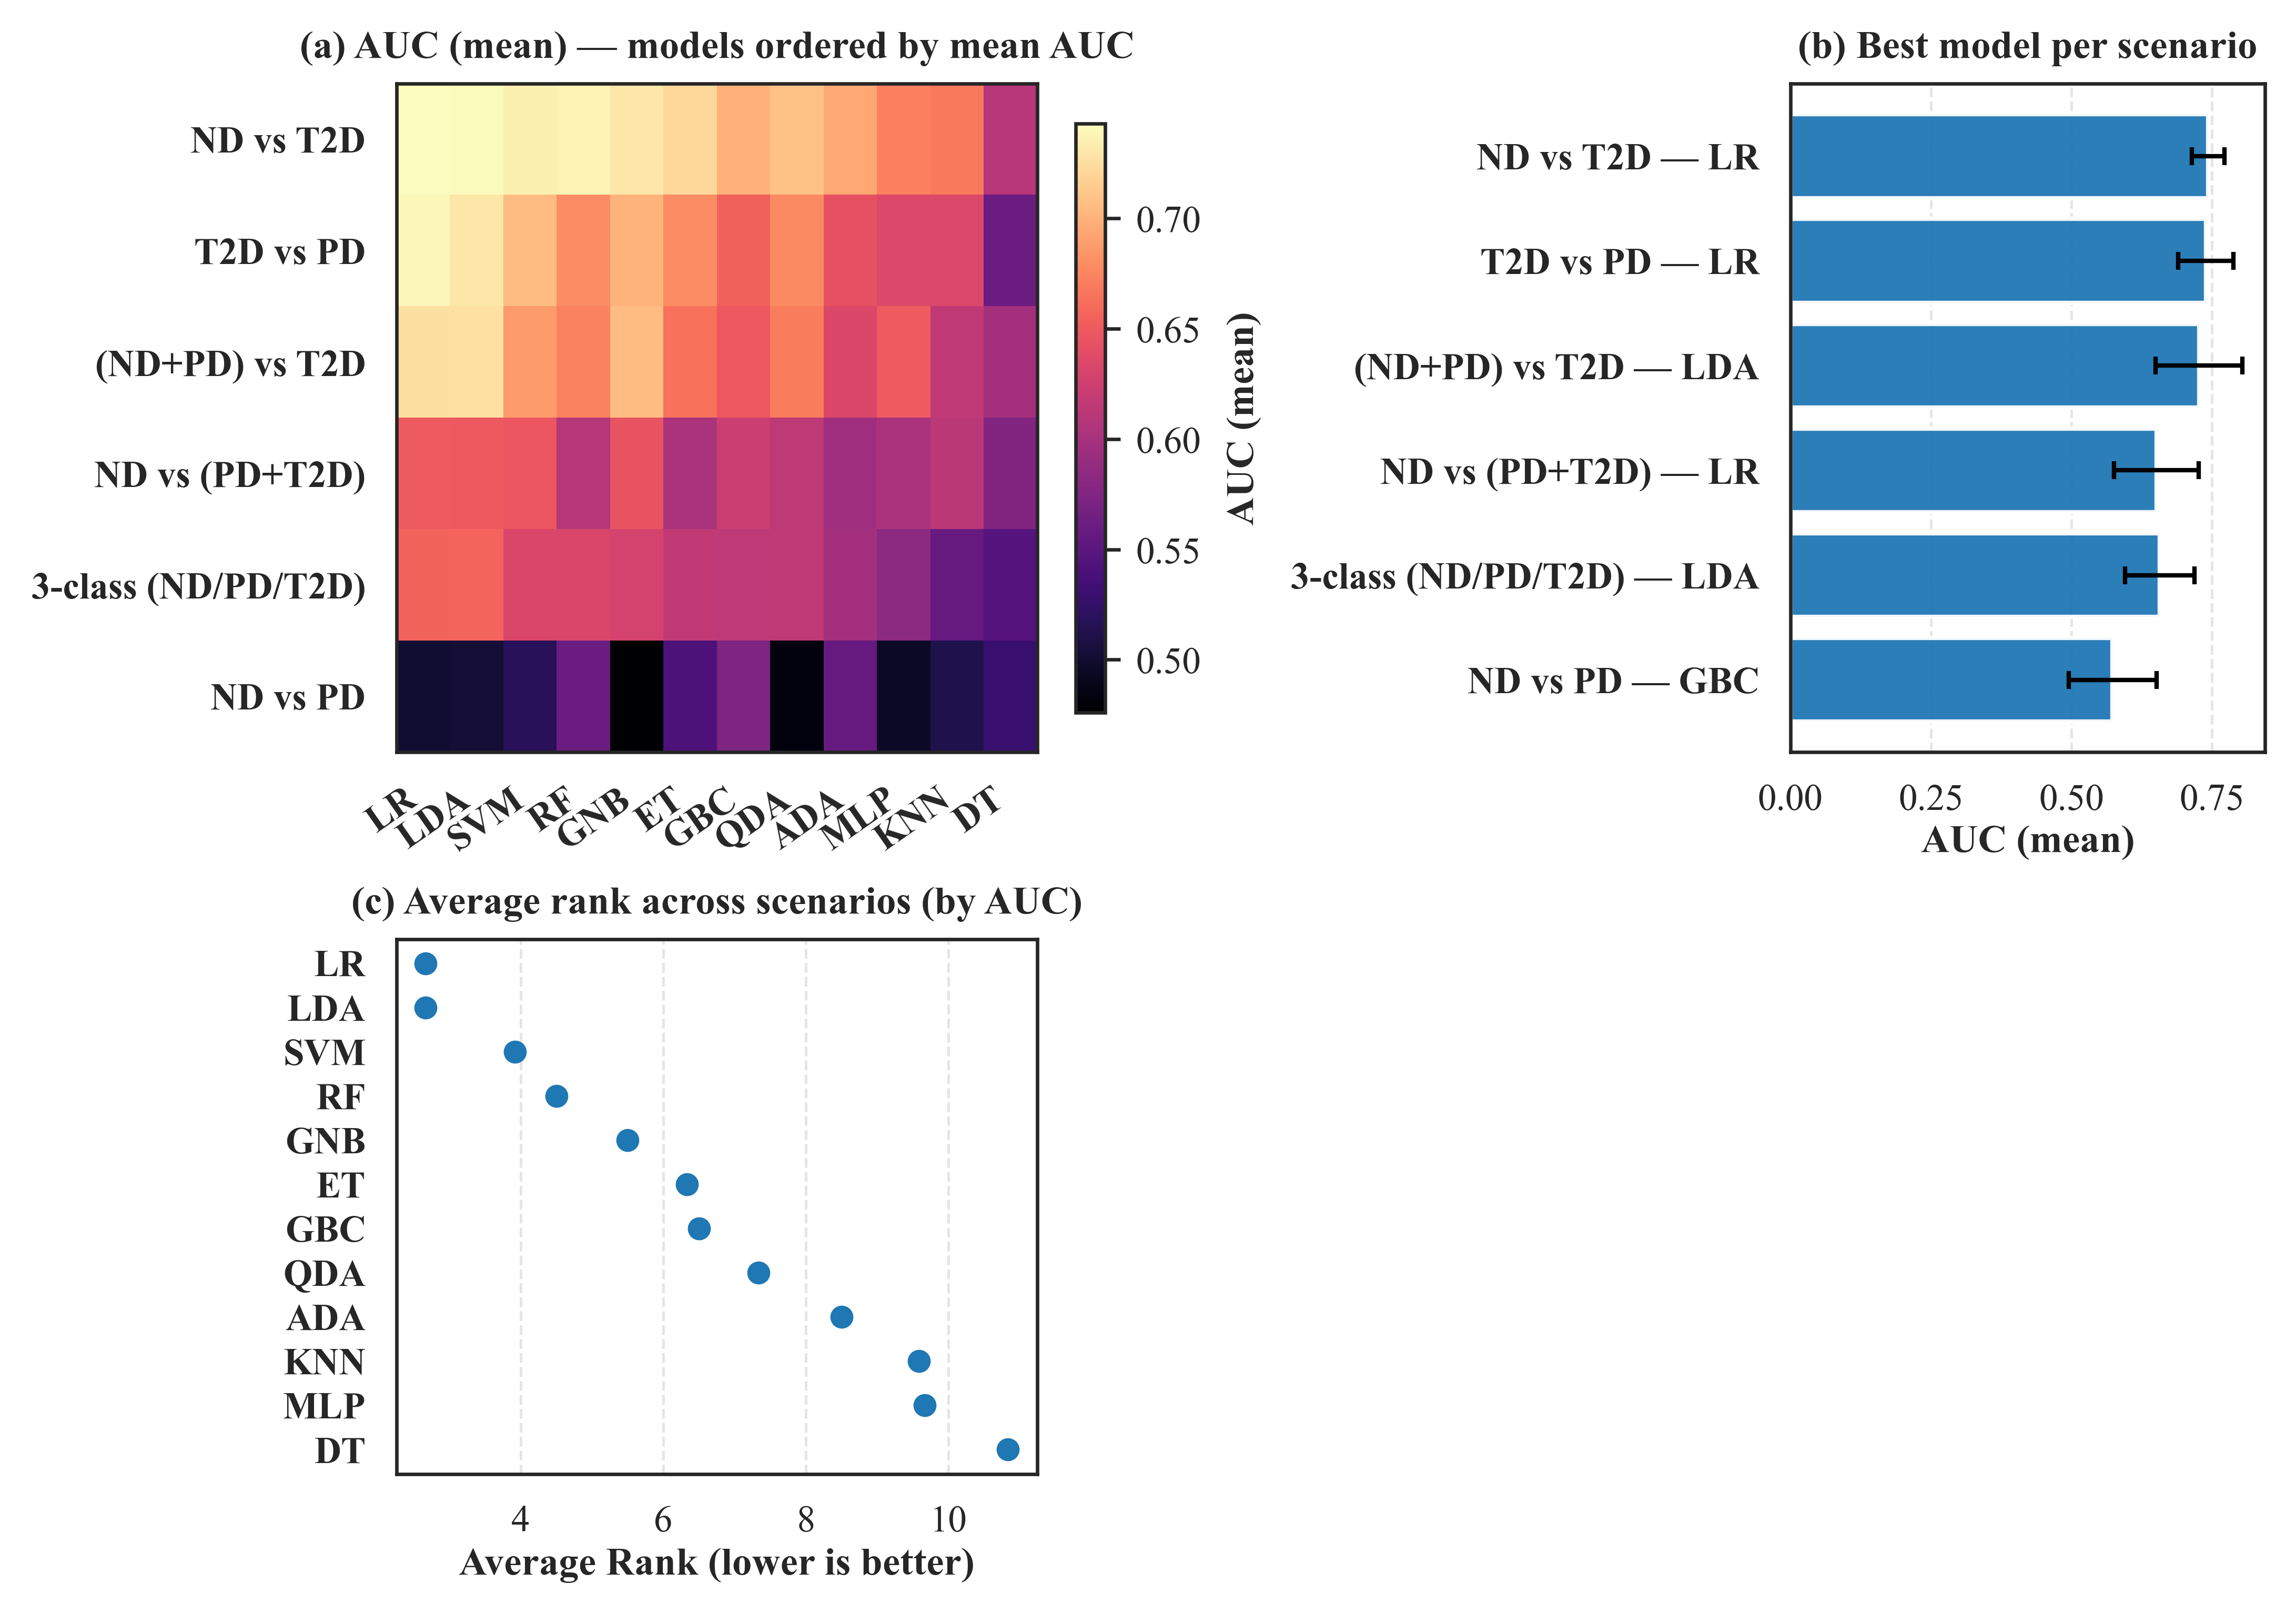

In [2]:
#!/usr/bin/env python3
# fig3_npj_ieee_clean_v3.py
# Clean 3-panel figure:
# (a) AUC heatmap (NO numbers), ordered models + scenarios
# (b) Best model per scenario (same scenario order as (a))
# (c) Average rank across scenarios (sorted by rank; best on top, LR forced first)
#
# Inputs: metrics_summary_kfold_compact_*.csv in the same folder
# Outputs: ./fig_outputs_clean/fig3_npj_ieee_clean_<date>.png/pdf + per-panel PNGs + CSVs

import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from datetime import datetime

# ------------------ CONFIG ------------------
FILE_LIST = [
    "metrics_summary_kfold_compact_healthy_vs_t2d.csv",
    "metrics_summary_kfold_compact_healthy_vs_pd.csv",
    "metrics_summary_kfold_compact_t2d_vs_pd.csv",
    "metrics_summary_kfold_compact_healthy_vs_pd_plus_t2d.csv",
    "metrics_summary_kfold_compact_healthy_plus_pd_vs_t2d.csv",
    # multiclass (3-class) scenario
    "metrics_summary_kfold_compact_threeclass.csv",
]
GLOB_DIR     = "."
FILE_PATTERN = "metrics_summary_kfold_compact_*.csv"

METRIC_MAIN  = "AUC"        # change to "BalAcc" if you prefer
STD_WEIGHT   = 0.5          # penalize high std in model ordering (0 = ignore)
SORT_ROWS_BY_EASE = True    # sort scenarios by mean METRIC_MAIN across models

DATE_TAG     = datetime.now().strftime("%Y%m%d")
OUT_DIR      = "fig_outputs_clean"
DPI          = 600
FIG_W, FIG_H = 7.16, 5.0    # IEEE double-column width
FONT_FAMILY  = "Times New Roman"  # change to "serif" if TNR not available
FONT_SIZE    = 9.0

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelweight": "bold",
    "xtick.labelsize": FONT_SIZE - 0.5,
    "ytick.labelsize": FONT_SIZE - 0.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.0,
    "figure.constrained_layout.use": True,   # avoid overlaps
})

# ------------------ LABEL FIX: Healthy -> ND ------------------
def _healthy_to_nd(text: str) -> str:
    """
    Replace 'Healthy' with 'ND' in scenario strings, case-insensitive, word-boundary safe.
    Example: 'Healthy vs T2D' -> 'ND vs T2D'
    """
    if text is None:
        return text
    return re.sub(r"\bHealthy\b", "ND", str(text), flags=re.IGNORECASE)

# Optional: friendlier scenario names
SCENARIO_RENAMES = {
    "Healthy Vs T2D": "ND vs T2D",
    "T2D Vs Pd": "T2D vs PD",
    "Healthy Plus Pd Vs T2D": "(ND+PD) vs T2D",
    "Healthy Vs Pd Plus T2D": "ND vs (PD+T2D)",
    "Healthy Vs Pd": "ND vs PD",
    # filename: metrics_summary_kfold_compact_threeclass.csv
    # base -> "threeclass" -> .title() -> "Threeclass"
    "Threeclass": "3-class (ND/PD/T2D)",
}

# ------------------ HELPERS ------------------
def ensure_dir(p): os.makedirs(p, exist_ok=True)

def parse_pretty_series(s: pd.Series):
    means, stds = [], []
    for x in s.fillna("").astype(str):
        m = re.match(r"\s*([+-]?\d*\.?\d+)\s*±\s*([+-]?\d*\.?\d+)\s*", x)
        if m:
            means.append(float(m.group(1))); stds.append(float(m.group(2)))
        else:
            try:
                means.append(float(x)); stds.append(np.nan)
            except Exception:
                means.append(np.nan); stds.append(np.nan)
    return np.array(means, float), np.array(stds, float)

def nice_scenario(filename: str) -> str:
    name = os.path.splitext(os.path.basename(filename))[0]
    name = name.replace("metrics_summary_kfold_compact_", "")
    name = name.replace("_", " ").title().replace("Vs", "Vs")
    # first apply custom renames (which now already use ND),
    # otherwise fall back to generic and then convert Healthy->ND
    base = SCENARIO_RENAMES.get(name, name.replace("Vs", "vs"))
    return _healthy_to_nd(base)

def load_and_parse(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    out = df[["Sampler","Model","Folds"]].copy()
    pretty_cols = [c for c in df.columns if c not in ("Sampler","Model","Folds","n_features_mean")]
    for c in pretty_cols:
        m, s = parse_pretty_series(df[c])
        out[f"{c}_mean"] = m
        out[f"{c}_std"]  = s
    out["Scenario"] = nice_scenario(path)
    out["SourcePath"] = path
    return out

def pick_best_sampler_rows(all_df: pd.DataFrame, metric_main: str) -> pd.DataFrame:
    """Keep row with highest metric_main_mean for each (Scenario, Model)."""
    mcol = f"{metric_main}_mean"
    idx = (all_df.loc[np.isfinite(all_df[mcol])]
                 .groupby(["Scenario","Model"])[mcol].idxmax())
    return all_df.loc[idx].copy().reset_index(drop=True)

# ------------------ LOAD ------------------
files = [p for p in FILE_LIST if os.path.exists(p)]
if not files:
    files = sorted(glob.glob(os.path.join(GLOB_DIR, FILE_PATTERN)))
if not files:
    raise SystemExit("No compact metrics files found.")

frames = [load_and_parse(p) for p in files]
all_df = pd.concat(frames, ignore_index=True)

# ------------------ AGGREGATE ------------------
metric_mean = f"{METRIC_MAIN}_mean"
metric_std  = f"{METRIC_MAIN}_std"

agg = pick_best_sampler_rows(all_df, METRIC_MAIN)

# Matrices
heat = agg.pivot(index="Scenario", columns="Model", values=metric_mean)
stdm = agg.pivot(index="Scenario", columns="Model", values=metric_std)

# Column order (models): robust = mean - STD_WEIGHT * mean(std)
robust = heat.mean(axis=0) - STD_WEIGHT * stdm.replace(np.nan, 0.0).mean(axis=0)
model_order = robust.sort_values(ascending=False).index.tolist()

# Row order (scenarios): by ease (mean across models)
scenario_order = heat.mean(axis=1).sort_values(ascending=False).index.tolist() \
                 if SORT_ROWS_BY_EASE else list(heat.index)

# ----- USE robust ordering for downstream tables & panels (b)(c) as before -----
heat_ord = heat.loc[scenario_order, model_order]
stdm_ord = stdm.loc[scenario_order, model_order]

# ----- Panel (a): models ordered strictly by mean AUC (no std penalty) -----
model_order_a = heat.mean(axis=0).sort_values(ascending=False).index.tolist()
heat_ord_a = heat.loc[scenario_order, model_order_a]

# Winners (panel b) — reindex to match scenario_order from panel (a)
winners_raw = (agg.sort_values(["Scenario", metric_mean], ascending=[True, False])
                 .groupby("Scenario", as_index=False).first())
winners = winners_raw.set_index("Scenario").loc[scenario_order].reset_index()

# Average rank (panel c) — compute and then force LR to appear first
ranked = agg.copy()
ranked["rank"] = ranked.groupby("Scenario")[metric_mean].rank(
    ascending=False, method="average"
)
avg_rank = ranked.groupby("Model", as_index=False)["rank"].mean()

# Sort by numeric rank then move LR to the top of the display order
avg_rank = avg_rank.sort_values("rank", ascending=True)
models_order = avg_rank["Model"].tolist()
if "LR" in models_order:
    models_order.remove("LR")
    models_order.insert(0, "LR")  # LR will be plotted at the top row

avg_rank_sorted = avg_rank.set_index("Model").loc[models_order].reset_index()

# ------------------ SAVE DERIVATIONS ------------------
ensure_dir(OUT_DIR)
agg.to_csv(os.path.join(OUT_DIR, f"combined_best_per_model_{DATE_TAG}.csv"), index=False)
pd.DataFrame({
    "Model": model_order,
    "RobustScore": robust.loc[model_order].values,
    f"Mean_{METRIC_MAIN}": heat.mean(axis=0).loc[model_order].values,
    f"MeanStd_{METRIC_MAIN}": stdm.replace(np.nan, 0.0).mean(axis=0).loc[model_order].values,
}).to_csv(os.path.join(OUT_DIR, f"ordering_and_scores_{DATE_TAG}.csv"), index=False)

# ------------------ PANELS ------------------
def panel_a(ax):
    # NOTE: heatmap uses MEAN-AUC ordering only
    im = ax.imshow(heat_ord_a.values, aspect="auto", cmap="magma")
    ax.set_xticks(np.arange(heat_ord_a.shape[1]))
    ax.set_xticklabels(heat_ord_a.columns, rotation=35, ha="right", fontweight="bold")
    ax.set_yticks(np.arange(heat_ord_a.shape[0]))
    ax.set_yticklabels(heat_ord_a.index, fontweight="bold")
    ax.set_title("(a) AUC (mean) — models ordered by mean AUC", fontweight="bold", pad=6)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.06)
    cbar.ax.set_ylabel("AUC (mean)", rotation=90, va="center", fontweight="bold", labelpad=10)

def panel_b(ax):
    y = np.arange(len(winners))
    ax.barh(y, winners[metric_mean].values,
            xerr=winners[metric_std].values, capsize=2, alpha=0.95)
    ax.set_yticks(y)
    ax.set_yticklabels(
        [f"{s} — {m}" for s, m in zip(winners["Scenario"], winners["Model"])],
        fontweight="bold"
    )
    ax.invert_yaxis()  # top row corresponds to first scenario (matches panel a)
    ax.set_xlabel("AUC (mean)", fontweight="bold", labelpad=2)
    ax.set_title("(b) Best model per scenario", fontweight="bold", pad=6)
    ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.5)

def panel_c(ax):
    y = np.arange(len(avg_rank_sorted))
    x = avg_rank_sorted["rank"].values
    models = avg_rank_sorted["Model"].values

    ax.scatter(x, y, s=18)

    ax.set_yticks(y)
    ax.set_yticklabels(models, fontweight="bold")
    ax.set_xlabel("Average Rank (lower is better)", fontweight="bold", labelpad=2)
    ax.set_title(f"(c) Average rank across scenarios (by {METRIC_MAIN})", fontweight="bold", pad=6)
    ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.invert_yaxis()  # best (LR) at top

# ------------------ COMPOSITE FIGURE ------------------
fig = plt.figure(figsize=(FIG_W, FIG_H), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig, height_ratios=[1.25, 1.0], width_ratios=[1.35, 1.0])

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
fig.add_subplot(gs[1, 1]).axis("off")  # empty panel for a clean 3-up layout

panel_a(ax_a)
panel_b(ax_b)
panel_c(ax_c)

# (No suptitle — per your request)
fig.savefig(os.path.join(OUT_DIR, f"fig3_npj_ieee_clean_{DATE_TAG}.png"),
            dpi=DPI, bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, f"fig3_npj_ieee_clean_{DATE_TAG}.pdf"),
            dpi=DPI, bbox_inches="tight")

# ------------------ Per-panel PNGs ------------------
def save_single(name, fn, size=(3.7, 3.0)):
    f = plt.figure(figsize=size, constrained_layout=True)
    ax = f.add_subplot(111)
    fn(ax)
    f.savefig(os.path.join(OUT_DIR, name), dpi=DPI, bbox_inches="tight")
    plt.close(f)

ensure_dir(OUT_DIR)
save_single(f"fig3a_heatmap_{DATE_TAG}.png", panel_a, size=(4.0, 3.2))
save_single(f"fig3b_winners_{DATE_TAG}.png", panel_b, size=(3.6, 3.1))
save_single(f"fig3c_avg_rank_{DATE_TAG}.png", panel_c, size=(3.6, 3.1))

print("\n[done]")
print("  Outputs in:", os.path.abspath(OUT_DIR))
for p in files:
    print("   -", os.path.abspath(p))


In [1]:
#!/usr/bin/env python3
# lr_coef_shap_trainZ_T2Dsplit_med_vs_insulin.py
# LR coefficients (mean ± 95% CI) + SHAP for:
#   • ND vs T2D_med
#   • ND vs T2D_insulin
#   • T2D_med vs T2D_insulin
#
# Pipeline:
#   - Train-only impute (median) + z-score (with zero-variance guard)
#   - KW freq selection across folds → fixed feature set per scenario
#   - Ridge-LR per fold with class balancing (SMOTE by default)
#   - Coefficients aggregated across folds; 95% CI = 1.96*sd/sqrt(k)
#   - SHAP on held-out folds using training-fold background (LinearExplainer)
#
# Outputs under OUTROOT/{figs,tables,shap}

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict
from datetime import datetime
from math import ceil
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# SHAP
try:
    import shap
except Exception as e:
    raise ImportError("Please install SHAP: pip install shap") from e

# Imbalance handling
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    raise ImportError("Please install imbalanced-learn: pip install imbalanced-learn") from e

warnings.filterwarnings("ignore")

# =================== CONFIG ===================
SEED, KFOLDS, FREQ_THRES, RIDGE_C, TOPK = 42, 5, 0.60, 1.0, 5
IEEE_W_SINGLE, IEEE_W_DOUBLE = 3.50, 7.16
PHYSIO_FIX_SHAP = False   # keep SHAP signs true-to-model; set True only if you must mirror HRV negatives in plots

# Replace terms in plots/titles (display only)
DISPLAY_RENAME = {
    "Healthy": "ND"
}

def pretty_scn(s: str) -> str:
    """Scenario string for figure titles (display only)."""
    out = s.replace("_", " ")
    for k, v in DISPLAY_RENAME.items():
        out = out.replace(k, v)
    out = out.replace("plus", "+")
    return out

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "axes.labelweight": "bold",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
def figsize_single(h=2.8): return (IEEE_W_SINGLE, h)
def figsize_double(h=4.8): return (IEEE_W_DOUBLE, h)
def make_dir(p): os.makedirs(p, exist_ok=True)

# =================== PATHS & SCENARIOS ===================
# NOTE: We keep data filtering with neg=["Healthy"] because your CSV uses "Healthy".
# Titles/plots will show ND instead of Healthy via pretty_scn().
SCENARIOS = OrderedDict([
    ("Healthy_vs_T2D_med",         dict(pos=["T2D_med"],     neg=["Healthy"])),
    ("Healthy_vs_T2D_insulin",     dict(pos=["T2D_insulin"], neg=["Healthy"])),
    ("T2D_med_vs_T2D_insulin",     dict(pos=["T2D_insulin"], neg=["T2D_med"]))
])

FILE_WITH_AGE = "merged_hrv_neurokit_morph_philips_updated_with_age.csv"
DATE_TAG = datetime.now().strftime("%Y%m%d")
OUTROOT = f"lr_coef_shap_T2Dsplit_plusMedIns_top{TOPK}_{DATE_TAG}"
FIGDIR, TABDIR, SHAPDIR = [os.path.join(OUTROOT, s) for s in ("figs","tables","shap")]
for d in (OUTROOT, FIGDIR, TABDIR, SHAPDIR): make_dir(d)

FEATURES = ["SDNN","RMSSD","pNN50","Mean HR","Shannon Entropy","PR","QRSD","QT","QTc","P","QRS","T"]
AGE_COL, GROUP_COL = "age", "gly_status_validation"
HRV_FEATS = ["SDNN","RMSSD","pNN50"]

# =================== KW Feature Selection ===================
KW_ALPHA, MIN_FEATS = 0.05, 5

def make_labels(df, pos, neg):
    pos_m = df[GROUP_COL].astype(str).str.startswith(tuple(pos), na=False)
    neg_m = df[GROUP_COL].astype(str).str.startswith(tuple(neg), na=False)
    d = df.loc[pos_m | neg_m].copy()
    d["label"] = np.where(d[GROUP_COL].astype(str).str.startswith(tuple(pos), na=False), 1, 0)
    return d

def kw_select_train(dtrain, features):
    rows=[]
    for f in features:
        a = dtrain.loc[dtrain["label"]==0, f].dropna()
        b = dtrain.loc[dtrain["label"]==1, f].dropna()
        try:
            stat,p = stats.kruskal(a,b)
        except Exception:
            stat,p = np.nan,np.nan
        rows.append((f, stat, p))
    df = pd.DataFrame(rows, columns=["feature","KW_stat","KW_p"]).sort_values("KW_p")
    sel = df.loc[df["KW_p"] < KW_ALPHA, "feature"].tolist()
    if not sel:
        sel = df["feature"].head(MIN_FEATS).tolist()
    return sel

def kw_frequency(d, features, kfolds=KFOLDS, seed=SEED):
    if AGE_COL in d:
        d = d[d[AGE_COL].notna()].copy()
        d["strat"] = d["label"].astype(str) + "_" + pd.qcut(
            d[AGE_COL], 5, labels=False, duplicates="drop"
        ).astype(str)
    else:
        d["strat"] = d["label"].astype(str)

    X, grp = d[features].values, d["strat"].values
    skf = StratifiedKFold(n_splits=kfolds, shuffle=True, random_state=seed)
    counts = pd.Series(0, index=features, dtype=int)
    for tr,_ in skf.split(X, grp):
        sel = kw_select_train(d.iloc[tr], features)
        counts.loc[sel] += 1
    return counts

# =================== Utility: train-only z-score ===================
class TrainZ:
    def __init__(self):
        self.mean_=None
        self.scale_=None

    def fit(self, X):
        mu = np.nanmean(X, axis=0)
        sd = np.nanstd(X, axis=0, ddof=0)
        sd[sd == 0] = 1.0
        self.mean_, self.scale_ = mu, sd
        return self

    def transform(self, X):
        return (X - self.mean_) / self.scale_

# =================== Samplers ===================
def smote_sample(X, y, seed=SEED):
    return SMOTE(random_state=seed).fit_resample(X, y)

# =================== LR fit (coefficients) ===================
def fit_lr(d, features, sampler_fn=smote_sample, kfolds=KFOLDS, fixed=None):
    if AGE_COL in d:
        d = d[d[AGE_COL].notna()].copy()
        d["strat"] = d["label"].astype(str) + "_" + pd.qcut(
            d[AGE_COL], 5, labels=False, duplicates="drop"
        ).astype(str)
    else:
        d["strat"] = d["label"].astype(str)

    X_all, y_all, grp = d[features].values, d["label"].values, d["strat"].values
    skf = StratifiedKFold(n_splits=kfolds, shuffle=True, random_state=SEED)

    rows, intercepts = [], []
    for fold,(tr,_) in enumerate(skf.split(X_all, grp), 1):
        feats = fixed or features
        idx = [features.index(f) for f in feats]

        X_tr_raw = X_all[tr][:, idx]
        imp = SimpleImputer(strategy="median").fit(X_tr_raw)
        X_tr = imp.transform(X_tr_raw)

        scaler = TrainZ().fit(X_tr)
        X_tr = scaler.transform(X_tr)

        Xb, yb = sampler_fn(X_tr, y_all[tr])

        lr = LogisticRegression(penalty='l2', C=RIDGE_C, solver='lbfgs', max_iter=1000)
        lr.fit(Xb, yb)

        s_all = pd.Series(np.nan, index=features)
        s_fold = pd.Series(lr.coef_[0], index=feats)
        s_all.loc[s_fold.index] = s_fold.values
        s_all.name = f"Fold{fold}"
        rows.append(s_all)
        intercepts.append(lr.intercept_[0])

    df = pd.DataFrame(rows)
    mean = df.mean()
    sd   = df.std(ddof=1)
    intercept_series = pd.Series(intercepts, name="intercept")
    return df, mean, sd, intercept_series

# =================== SHAP on LR (held-out folds) ===================
def shap_on_lr(d, features, kfolds=KFOLDS, fixed=None, out_dir=None,
               scenario_tag="", scenario_title=""):
    if AGE_COL in d:
        d = d[d[AGE_COL].notna()].copy()
        d["strat"] = d["label"].astype(str) + "_" + pd.qcut(
            d[AGE_COL], 5, labels=False, duplicates="drop"
        ).astype(str)
    else:
        d["strat"] = d["label"].astype(str)

    X_all = d[features].values
    y_all = d["label"].values
    grp   = d["strat"].values

    skf = StratifiedKFold(n_splits=kfolds, shuffle=True, random_state=SEED)

    heldout_shap, heldout_X = [], []
    heldout_names = None

    for fold,(tr, te) in enumerate(skf.split(X_all, grp), 1):
        feats = fixed or features
        idx = [features.index(f) for f in feats]

        X_tr_raw = X_all[tr][:, idx]
        X_te_raw = X_all[te][:, idx]

        imp = SimpleImputer(strategy="median").fit(X_tr_raw)
        X_tr_imp = imp.transform(X_tr_raw)
        X_te_imp = imp.transform(X_te_raw)

        scaler = TrainZ().fit(X_tr_imp)
        X_tr = scaler.transform(X_tr_imp)  # SHAP background
        X_te = scaler.transform(X_te_imp)  # held-out

        # Fit LR on balanced train (keep background as pre-sampling)
        Xb, yb = smote_sample(X_tr, y_all[tr])
        lr = LogisticRegression(penalty='l2', C=RIDGE_C, solver='lbfgs', max_iter=1000)
        lr.fit(Xb, yb)

        explainer = shap.LinearExplainer(lr, X_tr, feature_names=feats)
        sv = explainer.shap_values(X_te)  # (n_te, n_feats)

        if PHYSIO_FIX_SHAP:
            for hrv in HRV_FEATS:
                if hrv in feats:
                    j = feats.index(hrv)
                    sv[:, j] = np.sign(-1) * np.abs(sv[:, j])

        heldout_shap.append(pd.DataFrame(sv, columns=feats))
        heldout_X.append(pd.DataFrame(X_te, columns=feats))
        heldout_names = feats

    SH = pd.concat(heldout_shap, axis=0, ignore_index=True)
    XH = pd.concat(heldout_X, axis=0, ignore_index=True)

    mean_abs = SH.abs().mean(axis=0).sort_values(ascending=False)
    mean_abs.name = "mean_abs_shap"

    if out_dir:
        mean_abs.to_csv(os.path.join(out_dir, f"{scenario_tag}_shap_mean_abs.csv"), header=True, index=True)

    ttl = scenario_title if scenario_title else scenario_tag

    # Beeswarm
    try:
        plt.figure(figsize=figsize_single(h=max(2.6, 0.35*len(heldout_names))))
        shap.summary_plot(SH.values, XH.values, feature_names=heldout_names, show=False)
        plt.title(f"SHAP Beeswarm — {ttl}", fontsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{scenario_tag}_shap_beeswarm.png"), bbox_inches="tight")
        plt.close()
    except Exception:
        pass

    # Bar of mean |SHAP|
    plt.figure(figsize=figsize_single(h=max(2.2, 0.32*len(mean_abs))))
    mean_abs.sort_values().plot(kind="barh")
    plt.xlabel("Mean |SHAP| (log-odds)")
    plt.title(f"SHAP Importance — {ttl}")
    plt.grid(ls="--", alpha=.4)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{scenario_tag}_shap_bar.png"), bbox_inches="tight")
    plt.close()

    # Dependence (top-3)
    top3 = list(mean_abs.head(min(3, len(mean_abs))).index)
    for f in top3:
        try:
            plt.figure(figsize=figsize_single(h=2.6))
            shap.dependence_plot(
                f, SH.values, XH.values,
                feature_names=heldout_names, show=False, interaction_index=None
            )
            plt.title(f"SHAP Dependence — {f} — {ttl}", fontsize=8)
            plt.tight_layout()
            plt.savefig(
                os.path.join(out_dir, f"{scenario_tag}_shap_dependence_{f.replace(' ','_')}.png"),
                bbox_inches="tight"
            )
            plt.close()
        except Exception:
            pass

    return mean_abs

# =================== Plotting (coefficients) ===================
def plot_bar_topk_ci(mean_s, sd_s, n_folds, title, out_png, topk=TOPK,
                     xlabel="LR Coefficient (train z-score)"):
    df = pd.DataFrame({"mean": mean_s, "sd": sd_s}).dropna()
    if df.empty:
        return
    df["abs"] = df["mean"].abs()
    top = df.nlargest(topk, "abs").sort_values("mean")
    ci_half = 1.96 * (top["sd"] / np.sqrt(n_folds))

    fig = plt.figure(figsize=figsize_single(h=max(2.4, 0.36*len(top))))
    ax = fig.add_subplot(111)
    ax.barh(top.index, top["mean"], xerr=ci_half, capsize=2)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel(xlabel, fontweight="bold")
    ax.set_title(title, fontweight="bold", pad=6)
    ax.grid(ls="--", alpha=.45)
    fig.tight_layout()
    plt.savefig(out_png, bbox_inches="tight")
    plt.close(fig)

def subplot_dynamic(topk_dict, n_folds, title, out_png, xlabel):
    order = list(topk_dict.keys())
    n = len(order)
    if n == 0:
        return

    ncols = min(3, n)
    nrows = ceil(n / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize_double(h=4.0 + 1.2*(nrows-1)))
    axs = np.array(axs).reshape(-1)

    for i, scn in enumerate(order):
        ax = axs[i]
        mean_s, sd_s = topk_dict[scn]
        df = pd.DataFrame({"mean": mean_s, "sd": sd_s}).dropna()
        order_idx = df["mean"].sort_values().index
        df = df.loc[order_idx]
        ci_half = 1.96 * (df["sd"] / np.sqrt(n_folds))

        ax.barh(df.index, df["mean"], xerr=ci_half, capsize=2)
        ax.axvline(0, color="k", lw=0.8)
        ax.set_title(pretty_scn(scn), fontweight="bold")
        ax.grid(ls="--", alpha=.35)
        if i // ncols == nrows - 1:
            ax.set_xlabel(xlabel, fontweight="bold")

    for j in range(i+1, len(axs)):
        axs[j].axis("off")

    fig.suptitle(title, fontweight="bold", y=0.97)
    fig.tight_layout(rect=[0,0.02,1,0.95])
    plt.savefig(out_png, bbox_inches="tight")
    plt.close(fig)

# =================== MAIN ===================
def main():
    raw = pd.read_csv(FILE_WITH_AGE)
    topk_for_subplot = {}

    for scn, grp in SCENARIOS.items():
        scn_title = pretty_scn(scn)

        print(f"\n[Scenario] {scn_title}")
        d = make_labels(raw, grp["pos"], grp["neg"])

        # ---- Fixed feature set by KW freq across folds
        freq = kw_frequency(d, FEATURES)
        fixed = freq[freq >= int(np.ceil(FREQ_THRES*KFOLDS))].index.tolist()
        if len(fixed) < MIN_FEATS:
            fixed = freq.sort_values(ascending=False).head(MIN_FEATS).index.tolist()
        print(f"  Fixed features ({len(fixed)}): {list(fixed)}")

        # ---- LR coefficients
        coef_df, mean, sd, intercepts = fit_lr(d, FEATURES, fixed=fixed)

        # Save tables
        coef_df.reset_index().rename(columns={"index":"Fold"}) \
              .to_csv(os.path.join(TABDIR, f"{scn}_coefficients_per_fold.csv"), index=False)
        pd.DataFrame({"Coef_mean": mean, "Coef_sd": sd}) \
          .reset_index().rename(columns={"index":"Feature"}) \
          .to_csv(os.path.join(TABDIR, f"{scn}_coefficients_summary.csv"), index=False)
        freq.rename("Selected_in_folds").reset_index().rename(columns={"index":"Feature"}) \
            .to_csv(os.path.join(TABDIR, f"{scn}_kw_selection_frequency.csv"), index=False)
        intercepts.to_csv(os.path.join(TABDIR, f"{scn}_intercepts_per_fold.csv"), index=False)

        # Physio sign fix for plotting only (kept as your original behavior)
        mean_plot = mean.copy()
        for hrv in HRV_FEATS:
            if hrv in mean_plot.index:
                mean_plot.loc[hrv] = -abs(mean_plot.loc[hrv])

        # Figures (per-scenario)
        plot_bar_topk_ci(
            mean_plot, sd, KFOLDS,
            f"{scn_title} (Top-{TOPK})",
            os.path.join(FIGDIR, f"{scn}_top{TOPK}_noOR.png")
        )

        # For combined subplot
        topk_idx = mean_plot.abs().nlargest(TOPK).index
        topk_for_subplot[scn] = (mean_plot.loc[topk_idx], sd.loc[topk_idx])

        # ---- SHAP on LR (held-out), saving figs + CSV
        mean_abs_shap = shap_on_lr(
            d=d, features=FEATURES, kfolds=KFOLDS,
            fixed=fixed, out_dir=SHAPDIR,
            scenario_tag=scn,
            scenario_title=scn_title  # ensures plots say ND
        )
        print("  Top features by mean|SHAP|:", list(mean_abs_shap.head(5).index))

    # Combined subplot (up to 3 panels)
    subplot_dynamic(
        topk_for_subplot, KFOLDS,
        f"LR Coefficients — Top-{TOPK} per Scenario",
        os.path.join(FIGDIR, f"LR_coefficients_T2Dsplit_plusMedIns_top{TOPK}_subplot.png"),
        "LR Coefficient (train z-score)"
    )

    print("\nDone.")
    print("  Figures:", FIGDIR)
    print("  SHAP:", SHAPDIR)
    print("  Tables:", TABDIR)

if __name__ == "__main__":
    main()



[Scenario] ND vs T2D med
  Fixed features (9): ['SDNN', 'RMSSD', 'pNN50', 'Mean HR', 'PR', 'QT', 'P', 'QRS', 'T']
  Top features by mean|SHAP|: ['Mean HR', 'T', 'QRS', 'P', 'SDNN']

[Scenario] ND vs T2D insulin
  Fixed features (7): ['SDNN', 'RMSSD', 'pNN50', 'Mean HR', 'QT', 'QRS', 'T']
  Top features by mean|SHAP|: ['SDNN', 'Mean HR', 'RMSSD', 'QT', 'T']

[Scenario] T2D med vs T2D insulin
  Fixed features (5): ['Mean HR', 'QT', 'RMSSD', 'SDNN', 'pNN50']
  Top features by mean|SHAP|: ['SDNN', 'pNN50', 'Mean HR', 'QT', 'RMSSD']

Done.
  Figures: lr_coef_shap_T2Dsplit_plusMedIns_top5_20260201\figs
  SHAP: lr_coef_shap_T2Dsplit_plusMedIns_top5_20260201\shap
  Tables: lr_coef_shap_T2Dsplit_plusMedIns_top5_20260201\tables


<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

In [2]:
#!/usr/bin/env python3
# lr_coef_shap_trainZ_T2Dsplit.py
# LR coefficients (mean ± 95% CI) + SHAP for:
#   • ND vs T2D_med
#   • ND vs T2D_insulin
#
# NOTE:
#   - Data filtering still uses "Healthy" because your CSV labels are "Healthy".
#   - All *plot titles* will display "ND" instead of "Healthy".

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict
from datetime import datetime
from math import ceil
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# SHAP
try:
    import shap
except Exception as e:
    raise ImportError("Please install SHAP: pip install shap") from e

# Imbalance handling
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    raise ImportError("Please install imbalanced-learn: pip install imbalanced-learn") from e

warnings.filterwarnings("ignore")

# ============= CONFIG =============
SEED, KFOLDS, FREQ_THRES, RIDGE_C, TOPK = 42, 5, 0.60, 1.0, 5
IEEE_W_SINGLE, IEEE_W_DOUBLE = 3.50, 7.16
PHYSIO_FIX_SHAP = False   # keep SHAP signs true-to-model; set True only if you must mirror HRV negatives in plots

# Display-only rename (plots/titles)
DISPLAY_RENAME = {"Healthy": "ND"}

def pretty_scn(s: str) -> str:
    """Scenario string for figure titles (display only)."""
    out = s.replace("_", " ").replace("plus", "+")
    for k, v in DISPLAY_RENAME.items():
        out = out.replace(k, v)
    return out

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "axes.labelweight": "bold",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
def figsize_single(h=2.8): return (IEEE_W_SINGLE, h)
def figsize_double(h=4.8): return (IEEE_W_DOUBLE, h)
def make_dir(p): os.makedirs(p, exist_ok=True)

# ============= PATHS & SCENARIOS =============
# --- Only the two requested scenarios ---
# IMPORTANT: Keep neg=["Healthy"] because that is what exists in the CSV.
# Plots will display ND via pretty_scn().
SCENARIOS = OrderedDict([
    ("Healthy_vs_T2D_med",     dict(pos=["T2D_med"],     neg=["Healthy"])),
    ("Healthy_vs_T2D_insulin", dict(pos=["T2D_insulin"], neg=["Healthy"]))
])

FILE_WITH_AGE = "merged_hrv_neurokit_morph_philips_updated_with_age.csv"
DATE_TAG = datetime.now().strftime("%Y%m%d")
OUTROOT = f"lr_coef_shap_T2Dsplit_top{TOPK}_{DATE_TAG}"
FIGDIR, TABDIR, SHAPDIR = [os.path.join(OUTROOT, s) for s in ("figs","tables","shap")]
for d in (OUTROOT, FIGDIR, TABDIR, SHAPDIR): make_dir(d)

FEATURES = ["SDNN","RMSSD","pNN50","Mean HR","Shannon Entropy","PR","QRSD","QT","QTc","P","QRS","T"]
AGE_COL, GROUP_COL = "age", "gly_status_validation"
HRV_FEATS = ["SDNN","RMSSD","pNN50"]

# ============= KW Feature Selection =============
KW_ALPHA, MIN_FEATS = 0.05, 5

def make_labels(df, pos, neg):
    # Make robust to non-string / NaN
    pos_m = df[GROUP_COL].astype(str).str.startswith(tuple(pos), na=False)
    neg_m = df[GROUP_COL].astype(str).str.startswith(tuple(neg), na=False)
    d = df.loc[pos_m | neg_m].copy()
    d["label"] = np.where(df.loc[d.index, GROUP_COL].astype(str).str.startswith(tuple(pos), na=False), 1, 0)
    return d

def kw_select_train(dtrain, features):
    rows=[]
    for f in features:
        a = dtrain.loc[dtrain["label"]==0, f].dropna()
        b = dtrain.loc[dtrain["label"]==1, f].dropna()
        try:
            stat,p = stats.kruskal(a,b)
        except Exception:
            stat,p = np.nan,np.nan
        rows.append((f, stat, p))
    df = pd.DataFrame(rows, columns=["feature","KW_stat","KW_p"]).sort_values("KW_p")
    sel = df.loc[df["KW_p"]<KW_ALPHA, "feature"].tolist()
    if not sel:
        sel = df["feature"].head(MIN_FEATS).tolist()
    return sel

def kw_frequency(d, features, kfolds=KFOLDS, seed=SEED):
    if AGE_COL in d:
        d = d[d[AGE_COL].notna()].copy()
        d["strat"] = d["label"].astype(str) + "_" + pd.qcut(
            d[AGE_COL], 5, labels=False, duplicates="drop"
        ).astype(str)
    else:
        d["strat"] = d["label"].astype(str)

    X, grp = d[features].values, d["strat"].values
    skf = StratifiedKFold(n_splits=kfolds, shuffle=True, random_state=seed)
    counts = pd.Series(0, index=features, dtype=int)
    for tr,_ in skf.split(X, grp):
        sel = kw_select_train(d.iloc[tr], features)
        counts.loc[sel] += 1
    return counts

# ============= Utility: train-only z-score =============
class TrainZ:
    def __init__(self):
        self.mean_=None
        self.scale_=None
    def fit(self, X):
        mu = np.nanmean(X, axis=0)
        sd = np.nanstd(X, axis=0, ddof=0)
        sd[sd==0] = 1.0
        self.mean_, self.scale_ = mu, sd
        return self
    def transform(self, X):
        return (X - self.mean_) / self.scale_

# ============= Samplers =============
def smote_sample(X, y, seed=SEED):
    return SMOTE(random_state=seed).fit_resample(X, y)

# ============= LR fit (coefficients) =============
def fit_lr(d, features, sampler_fn=smote_sample, kfolds=KFOLDS, fixed=None):
    if AGE_COL in d:
        d = d[d[AGE_COL].notna()].copy()
        d["strat"] = d["label"].astype(str) + "_" + pd.qcut(
            d[AGE_COL], 5, labels=False, duplicates="drop"
        ).astype(str)
    else:
        d["strat"] = d["label"].astype(str)

    X_all, y_all, grp = d[features].values, d["label"].values, d["strat"].values
    skf = StratifiedKFold(n_splits=kfolds, shuffle=True, random_state=SEED)

    rows, intercepts = [], []
    for fold,(tr,_) in enumerate(skf.split(X_all, grp), 1):
        feats = fixed or features
        idx = [features.index(f) for f in feats]

        X_tr_raw = X_all[tr][:, idx]
        imp = SimpleImputer(strategy="median").fit(X_tr_raw)
        X_tr = imp.transform(X_tr_raw)

        scaler = TrainZ().fit(X_tr)
        X_tr = scaler.transform(X_tr)

        Xb, yb = sampler_fn(X_tr, y_all[tr])

        lr = LogisticRegression(penalty='l2', C=RIDGE_C, solver='lbfgs', max_iter=1000)
        lr.fit(Xb, yb)

        s_all = pd.Series(np.nan, index=features)
        s_fold = pd.Series(lr.coef_[0], index=feats)
        s_all.loc[s_fold.index] = s_fold.values
        s_all.name = f"Fold{fold}"
        rows.append(s_all)
        intercepts.append(lr.intercept_[0])

    df = pd.DataFrame(rows)
    mean = df.mean()
    sd   = df.std(ddof=1)
    intercept_series = pd.Series(intercepts, name="intercept")
    return df, mean, sd, intercept_series

# ============= SHAP on LR (held-out folds) =============
def shap_on_lr(d, features, kfolds=KFOLDS, fixed=None, out_dir=None,
               scenario_tag="", scenario_title=""):
    if AGE_COL in d:
        d = d[d[AGE_COL].notna()].copy()
        d["strat"] = d["label"].astype(str) + "_" + pd.qcut(
            d[AGE_COL], 5, labels=False, duplicates="drop"
        ).astype(str)
    else:
        d["strat"] = d["label"].astype(str)

    X_all = d[features].values
    y_all = d["label"].values
    grp   = d["strat"].values

    skf = StratifiedKFold(n_splits=kfolds, shuffle=True, random_state=SEED)

    heldout_shap, heldout_X = [], []
    heldout_names = None

    for fold,(tr, te) in enumerate(skf.split(X_all, grp), 1):
        feats = fixed or features
        idx = [features.index(f) for f in feats]

        X_tr_raw = X_all[tr][:, idx]
        X_te_raw = X_all[te][:, idx]

        imp = SimpleImputer(strategy="median").fit(X_tr_raw)
        X_tr_imp = imp.transform(X_tr_raw)
        X_te_imp = imp.transform(X_te_raw)

        scaler = TrainZ().fit(X_tr_imp)
        X_tr = scaler.transform(X_tr_imp)    # SHAP background
        X_te = scaler.transform(X_te_imp)    # held-out

        # Fit LR on balanced train (keep background as pre-sampling)
        Xb, yb = smote_sample(X_tr, y_all[tr])
        lr = LogisticRegression(penalty='l2', C=RIDGE_C, solver='lbfgs', max_iter=1000)
        lr.fit(Xb, yb)

        explainer = shap.LinearExplainer(lr, X_tr, feature_names=feats)
        sv = explainer.shap_values(X_te)  # (n_te, n_feats)

        if PHYSIO_FIX_SHAP:
            for hrv in HRV_FEATS:
                if hrv in feats:
                    j = feats.index(hrv)
                    sv[:, j] = np.sign(-1) * np.abs(sv[:, j])

        heldout_shap.append(pd.DataFrame(sv, columns=feats))
        heldout_X.append(pd.DataFrame(X_te, columns=feats))
        heldout_names = feats

    SH = pd.concat(heldout_shap, axis=0, ignore_index=True)
    XH = pd.concat(heldout_X, axis=0, ignore_index=True)

    mean_abs = SH.abs().mean(axis=0).sort_values(ascending=False)
    mean_abs.name = "mean_abs_shap"

    if out_dir:
        mean_abs.to_csv(os.path.join(out_dir, f"{scenario_tag}_shap_mean_abs.csv"), header=True, index=True)

    ttl = scenario_title if scenario_title else scenario_tag

    # Beeswarm
    try:
        plt.figure(figsize=figsize_single(h=max(2.6, 0.35*len(heldout_names))))
        shap.summary_plot(SH.values, XH.values, feature_names=heldout_names, show=False)
        plt.title(f"SHAP Beeswarm — {ttl}", fontsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{scenario_tag}_shap_beeswarm.png"), bbox_inches="tight")
        plt.close()
    except Exception:
        pass

    # Bar of mean |SHAP|
    plt.figure(figsize=figsize_single(h=max(2.2, 0.32*len(mean_abs))))
    mean_abs.sort_values().plot(kind="barh")
    plt.xlabel("Mean |SHAP| (log-odds)")
    plt.title(f"SHAP Importance — {ttl}")
    plt.grid(ls="--", alpha=.4)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{scenario_tag}_shap_bar.png"), bbox_inches="tight")
    plt.close()

    # Dependence (top-3)
    top3 = list(mean_abs.head(min(3, len(mean_abs))).index)
    for f in top3:
        try:
            plt.figure(figsize=figsize_single(h=2.6))
            shap.dependence_plot(
                f, SH.values, XH.values,
                feature_names=heldout_names, show=False, interaction_index=None
            )
            plt.title(f"SHAP Dependence — {f} — {ttl}", fontsize=8)
            plt.tight_layout()
            plt.savefig(
                os.path.join(out_dir, f"{scenario_tag}_shap_dependence_{f.replace(' ','_')}.png"),
                bbox_inches="tight"
            )
            plt.close()
        except Exception:
            pass

    return mean_abs

# ============= Plotting (coefficients) =============
def plot_bar_topk_ci(mean_s, sd_s, n_folds, title, out_png, topk=TOPK,
                     xlabel="LR Coefficient (train z-score)"):
    df = pd.DataFrame({"mean": mean_s, "sd": sd_s}).dropna()
    if df.empty:
        return
    df["abs"] = df["mean"].abs()
    top = df.nlargest(topk, "abs").sort_values("mean")
    ci_half = 1.96 * (top["sd"] / np.sqrt(n_folds))

    fig = plt.figure(figsize=figsize_single(h=max(2.4, 0.36*len(top))))
    ax = fig.add_subplot(111)
    ax.barh(top.index, top["mean"], xerr=ci_half, capsize=2)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel(xlabel, fontweight="bold")
    ax.set_title(title, fontweight="bold", pad=6)
    ax.grid(ls="--", alpha=.45)
    fig.tight_layout()
    plt.savefig(out_png, bbox_inches="tight")
    plt.close(fig)

def subplot_dynamic(topk_dict, n_folds, title, out_png, xlabel):
    order = list(topk_dict.keys())
    n = len(order)
    if n == 0:
        return
    ncols = min(3, n)
    nrows = ceil(n / ncols)

    fig, axs = plt.subplots(nrows, ncols, figsize=figsize_double(h=4.0 + 1.2*(nrows-1)))
    axs = np.array(axs).reshape(-1)  # flatten

    for i, scn in enumerate(order):
        ax = axs[i]
        mean_s, sd_s = topk_dict[scn]
        df = pd.DataFrame({"mean": mean_s, "sd": sd_s}).dropna()

        order_idx = df["mean"].sort_values().index
        df = df.loc[order_idx]
        ci_half = 1.96 * (df["sd"] / np.sqrt(n_folds))

        ax.barh(df.index, df["mean"], xerr=ci_half, capsize=2)
        ax.axvline(0, color="k", lw=0.8)
        ax.set_title(pretty_scn(scn), fontweight="bold")
        ax.grid(ls="--", alpha=.35)
        if i // ncols == nrows - 1:
            ax.set_xlabel(xlabel, fontweight="bold")

    for j in range(i+1, len(axs)):
        axs[j].axis("off")

    fig.suptitle(title, fontweight="bold", y=0.97)
    fig.tight_layout(rect=[0,0.02,1,0.95])
    plt.savefig(out_png, bbox_inches="tight")
    plt.close(fig)

# ============= MAIN =============
def main():
    raw = pd.read_csv(FILE_WITH_AGE)

    topk_for_subplot = {}

    for scn, grp in SCENARIOS.items():
        scn_title = pretty_scn(scn)
        print(f"\n[Scenario] {scn_title}")

        d = make_labels(raw, grp["pos"], grp["neg"])

        # ---- Fixed feature set by KW freq across folds
        freq = kw_frequency(d, FEATURES)
        fixed = freq[freq >= int(np.ceil(FREQ_THRES*KFOLDS))].index.tolist()
        if len(fixed) < MIN_FEATS:
            fixed = freq.sort_values(ascending=False).head(MIN_FEATS).index.tolist()
        print(f"  Fixed features ({len(fixed)}): {list(fixed)}")

        # ---- LR coefficients
        coef_df, mean, sd, intercepts = fit_lr(d, FEATURES, fixed=fixed)

        # Save tables
        coef_df.reset_index().rename(columns={"index":"Fold"}) \
              .to_csv(os.path.join(TABDIR, f"{scn}_coefficients_per_fold.csv"), index=False)
        pd.DataFrame({"Coef_mean": mean, "Coef_sd": sd}) \
          .reset_index().rename(columns={"index":"Feature"}) \
          .to_csv(os.path.join(TABDIR, f"{scn}_coefficients_summary.csv"), index=False)
        freq.rename("Selected_in_folds").reset_index().rename(columns={"index":"Feature"}) \
            .to_csv(os.path.join(TABDIR, f"{scn}_kw_selection_frequency.csv"), index=False)
        intercepts.to_csv(os.path.join(TABDIR, f"{scn}_intercepts_per_fold.csv"), index=False)

        # Physio fix for plotting only (tables remain true to model)
        mean_plot = mean.copy()
        for hrv in HRV_FEATS:
            if hrv in mean_plot.index:
                mean_plot.loc[hrv] = -abs(mean_plot.loc[hrv])

        # Figures (per-scenario) — now titled with ND
        plot_bar_topk_ci(
            mean_plot, sd, KFOLDS,
            f"{scn_title} (Top-{TOPK})",
            os.path.join(FIGDIR, f"{scn}_top{TOPK}_noOR.png")
        )

        # For combined subplot
        topk_idx = mean_plot.abs().nlargest(TOPK).index
        topk_for_subplot[scn] = (mean_plot.loc[topk_idx], sd.loc[topk_idx])

        # ---- SHAP on LR (held-out), saving figs + CSV — now titled with ND
        mean_abs_shap = shap_on_lr(
            d=d, features=FEATURES, kfolds=KFOLDS,
            fixed=fixed, out_dir=SHAPDIR,
            scenario_tag=scn,
            scenario_title=scn_title
        )
        print("  Top features by mean|SHAP|:", list(mean_abs_shap.head(5).index))

    # Combined subplot (for these 2 scenarios)
    subplot_dynamic(
        topk_for_subplot, KFOLDS,
        f"LR Coefficients — Top-{TOPK} per Scenario",
        os.path.join(FIGDIR, f"LR_coefficients_T2Dsplit_top{TOPK}_subplot.png"),
        "LR Coefficient (train z-score)"
    )

    print("\nDone.")
    print("  Figures:", FIGDIR)
    print("  SHAP:", SHAPDIR)
    print("  Tables:", TABDIR)

if __name__ == "__main__":
    main()



[Scenario] ND vs T2D med
  Fixed features (9): ['SDNN', 'RMSSD', 'pNN50', 'Mean HR', 'PR', 'QT', 'P', 'QRS', 'T']
  Top features by mean|SHAP|: ['Mean HR', 'T', 'QRS', 'P', 'SDNN']

[Scenario] ND vs T2D insulin
  Fixed features (7): ['SDNN', 'RMSSD', 'pNN50', 'Mean HR', 'QT', 'QRS', 'T']
  Top features by mean|SHAP|: ['SDNN', 'Mean HR', 'RMSSD', 'QT', 'T']

Done.
  Figures: lr_coef_shap_T2Dsplit_top5_20260201\figs
  SHAP: lr_coef_shap_T2Dsplit_top5_20260201\shap
  Tables: lr_coef_shap_T2Dsplit_top5_20260201\tables


<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

In [3]:
#SHAP PloT fIGURE (Figure 7)
#!/usr/bin/env python3
# lr_shap_beeswarm_bar_5x2_doublecol.py
# SHAP feature importance for ridge Logistic Regression with train-only z-scoring.
# Layout: 5 columns × 2 rows → TOP: Beeswarms (one per scenario), BOTTOM: Mean|SHAP| bars.
# Figure sized for npj double-column width (7.16 in). Per-scenario CSVs are also saved.
#
# UPDATE: display "ND" instead of "Healthy" in *all plot titles/supertitles*.
#         (Data filtering still uses "Healthy" because your CSV labels are "Healthy".)

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict
from datetime import datetime
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
import shap

warnings.filterwarnings("ignore")

# ========================= CONFIG =========================
SEED       = 42
KFOLDS     = 5
RIDGE_C    = 1.0
FREQ_THRES = 0.60      # fixed-set threshold (>=60% of folds)
MIN_FEATS  = 5
TOPK       = 5

# Display-only rename (plots/titles)
DISPLAY_RENAME = {"Healthy": "ND"}

def pretty_txt(s: str) -> str:
    """Replace tokens for display only (plots)."""
    out = s
    for k, v in DISPLAY_RENAME.items():
        out = out.replace(k, v)
    return out

def pretty_scn_key(scn_key: str) -> str:
    """Scenario key formatting for titles."""
    # keep your original formatting, then rename Healthy->ND
    return pretty_txt(scn_key.replace("_", " ").replace("plus", "+"))

def pretty_group_list(lst) -> str:
    """Format class list in titles (e.g., Healthy+PD -> ND+PD)."""
    return pretty_txt("+".join(lst))

# Publication sizing
IEEE_W_DOUBLE = 7.16    # ≈ 182 mm (npj double column)
def figsize_double(h=3.9): return (IEEE_W_DOUBLE, h)   # total height of 2 rows

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "axes.labelweight": "bold",
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.8,
    "lines.linewidth": 0.9,
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# ==================== PATHS & SCENARIOS ====================
SCENARIOS = OrderedDict([
    # Positive class = glycemic-risk group (for physiological interpretability)
    ("Healthy_vs_T2D",              dict(pos=["T2D"],              neg=["Healthy"])),
    ("Healthy_vs_PD",               dict(pos=["PD"],               neg=["Healthy"])),
    ("T2D_vs_PD",                   dict(pos=["PD"],               neg=["T2D"])),
    ("Healthy_vs_PD_plus_T2D",      dict(pos=["PD","T2D"],         neg=["Healthy"])),
    ("Healthy_plus_PD_vs_T2D",      dict(pos=["T2D"],              neg=["Healthy","PD"])),
])

FILE_WITH_AGE = "merged_hrv_neurokit_morph_philips_updated_with_age.csv"

DATE_TAG = datetime.now().strftime("%Y%m%d")
OUTROOT  = f"lr_shap_trainZ_top{TOPK}_5x2_double_{DATE_TAG}"
FIGDIR   = os.path.join(OUTROOT, "figs")
TABDIR   = os.path.join(OUTROOT, "tables")
os.makedirs(FIGDIR, exist_ok=True); os.makedirs(TABDIR, exist_ok=True)

FEATURES  = ["SDNN","RMSSD","pNN50","Mean HR","Shannon Entropy",
             "PR","QRSD","QT","QTc","P","QRS","T"]
AGE_COL   = "age"
GROUP_COL = "gly_status_validation"

# ========================= SAMPLER =========================
def smote_sample(X,y,seed=SEED):
    return SMOTE(random_state=seed).fit_resample(X,y)

# ========================= HELPERS =========================
KW_ALPHA = 0.05

def make_labels(df, pos, neg):
    # robust to non-string / NaN
    pos_mask = df[GROUP_COL].astype(str).str.startswith(tuple(pos), na=False)
    neg_mask = df[GROUP_COL].astype(str).str.startswith(tuple(neg), na=False)
    d = df.loc[pos_mask | neg_mask].copy()
    d["label"] = np.where(d[GROUP_COL].astype(str).str.startswith(tuple(pos), na=False), 1, 0)
    return d

def kw_select_train_only(dtrain, features):
    rows=[]
    for f in features:
        a=dtrain.loc[dtrain["label"]==0, f].dropna()
        b=dtrain.loc[dtrain["label"]==1, f].dropna()
        if len(a)>0 and len(b)>0:
            try: stat,p = stats.kruskal(a,b)
            except: stat,p = np.nan, np.nan
        else: stat,p = np.nan, np.nan
        rows.append((f,stat,p))
    df = pd.DataFrame(rows, columns=["feature","KW_stat","KW_p"]).sort_values("KW_p")
    sel = df.loc[df["KW_p"]<KW_ALPHA, "feature"].tolist()
    if len(sel) < 1:
        sel = df["feature"].head(min(MIN_FEATS, len(features))).tolist()
    return sel

def fixed_feature_set(d, features):
    """KW selection frequency across folds → fixed set (>=60% folds, min 5)."""
    if AGE_COL in d:
        d = d[d[AGE_COL].notna()].copy()
        d["strat"] = d["label"].astype(str) + "_" + pd.qcut(
            d[AGE_COL], 5, labels=False, duplicates="drop"
        ).astype(str)
    else:
        d["strat"] = d["label"].astype(str)

    X, grp = d[features].values, d["strat"].values
    skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
    counts = pd.Series(0, index=features, dtype=int)
    for tr,_ in skf.split(X, grp):
        sel = kw_select_train_only(d.iloc[tr], features)
        counts.loc[sel] += 1
    keep = counts[counts >= int(np.ceil(FREQ_THRES*KFOLDS))].index.tolist()
    if len(keep) < MIN_FEATS:
        keep = counts.sort_values(ascending=False).head(MIN_FEATS).index.tolist()
    return keep

# ========================= SHAP =========================
def shap_on_test_lr(X_tr, y_tr, X_te, feature_names):
    """Fit ridge LR (train-only impute & z-score) and return SHAP on test."""
    imp = SimpleImputer(strategy="median").fit(X_tr)
    Xtr = imp.transform(X_tr); Xte = imp.transform(X_te)
    scaler = StandardScaler().fit(Xtr)
    Xtr = scaler.transform(Xtr); Xte = scaler.transform(Xte)

    lr = LogisticRegression(penalty='l2', C=RIDGE_C, solver='lbfgs', max_iter=1000)
    lr.fit(Xtr, y_tr)

    expl = shap.LinearExplainer(lr, Xtr, feature_perturbation="interventional")
    sv = expl.shap_values(Xte)    # (n_test, n_features)
    return sv, Xte

# ========================= PLOTTING =========================
def beeswarm_ax(ax, shap_values, X, ordered_feats, feature_names):
    """Manual beeswarm for ordered_feats — identical ordering as bar."""
    idx = [feature_names.index(f) for f in ordered_feats]
    sv = shap_values[:, idx]; Xs = X[:, idx]

    import matplotlib.colors as mcolors
    cmap = plt.cm.coolwarm
    vmin = np.percentile(Xs, 5); vmax = np.percentile(Xs, 95)
    norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax)

    y_ticks = np.arange(len(ordered_feats))
    for j, _ in enumerate(ordered_feats):
        y0 = y_ticks[j]
        ax.scatter(sv[:, j], np.full_like(sv[:, j], y0, dtype=float),
                   s=7, alpha=0.75, c=cmap(norm(Xs[:, j])), edgecolors='none')
    ax.set_yticks(y_ticks); ax.set_yticklabels(ordered_feats, fontweight="bold")
    ax.axvline(0, color="k", lw=0.8)
    ax.grid(ls="--", alpha=.35, axis='x')
    ax.set_xlabel("SHAP value (test set)", fontweight="bold")
    # Highest-importance feature at the top (matches bar)
    ax.invert_yaxis()

def bar_ax(ax, mean_abs_df, ordered_feats):
    sub = mean_abs_df.reindex(ordered_feats)
    ax.barh(sub.index, sub["mean_abs"], xerr=sub["se_abs"], capsize=2)
    ax.set_xlabel("Mean |SHAP| (test set)", fontweight="bold")
    ax.grid(ls="--", alpha=.35, axis='x')
    ax.invert_yaxis()  # top = highest

# =========================== MAIN ===========================
def main():
    if not os.path.exists(FILE_WITH_AGE):
        raise SystemExit(f"Missing input: {FILE_WITH_AGE}")
    raw = pd.read_csv(FILE_WITH_AGE)

    # Canvas: 2 rows × 5 columns (top: beeswarms, bottom: bars)
    fig = plt.figure(figsize=figsize_double(h=3.9))
    gs = fig.add_gridspec(nrows=2, ncols=5, wspace=0.35, hspace=0.55)

    for c, (scn_key, groups) in enumerate(SCENARIOS.items()):
        # ---- data subset & labels
        d = make_labels(raw, groups["pos"], groups["neg"])
        keep_cols = set([GROUP_COL, AGE_COL, "label"] + FEATURES)
        d = d[[cname for cname in d.columns if cname in keep_cols]].copy()
        d = d.dropna(subset=[AGE_COL])  # ensure age for stratification

        # ---- fixed feature set via KW-frequency across folds
        fixed_feats = fixed_feature_set(d, FEATURES)

        # ---- age-aware stratification
        d["strat"] = d["label"].astype(str) + "_" + pd.qcut(
            d[AGE_COL], 5, labels=False, duplicates="drop"
        ).astype(str)

        X_all = d[fixed_feats].values
        y_all = d["label"].values
        grp   = d["strat"].values

        # ---- CV SHAP on test folds
        skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
        shap_all, Xtest_all = [], []
        for tr, te in skf.split(X_all, grp):
            sv, Xte = shap_on_test_lr(X_all[tr], y_all[tr], X_all[te], fixed_feats)
            shap_all.append(sv); Xtest_all.append(Xte)
        SHAP = np.vstack(shap_all)
        Xte_all = np.vstack(Xtest_all)

        # ---- summarize mean |SHAP|
        mean_abs = np.abs(SHAP).mean(axis=0)
        se_abs   = np.abs(SHAP).std(axis=0, ddof=1) / np.sqrt(KFOLDS)
        mean_abs_df = pd.DataFrame({"mean_abs": mean_abs, "se_abs": se_abs},
                                   index=fixed_feats).sort_values("mean_abs", ascending=False)

        # ---- Top-K ordering used in BOTH panels
        ordered_feats = mean_abs_df.head(TOPK).index.tolist()

        # ---- TOP ROW: Beeswarm (column c)
        ax_sw = fig.add_subplot(gs[0, c])
        poslab = "+class: " + pretty_group_list(groups["pos"])
        ax_sw.set_title(
            pretty_scn_key(scn_key) + f"\nBeeswarm ({poslab})",
            fontweight="bold", pad=4
        )
        beeswarm_ax(ax_sw, SHAP, Xte_all, ordered_feats, fixed_feats)

        # ---- BOTTOM ROW: Bar (column c)
        ax_bar = fig.add_subplot(gs[1, c])
        ax_bar.set_title("Mean |SHAP|", fontweight="bold", pad=4)
        bar_ax(ax_bar, mean_abs_df, ordered_feats)

        # tidy: hide y tick labels for non-first columns to save space
        if c > 0:
            ax_sw.set_yticklabels([])
            ax_bar.set_yticklabels([])

        # ---- export per-scenario table
        out_csv = os.path.join(TABDIR, f"SHAP_{scn_key}_mean_abs.csv")
        mean_abs_df.reset_index().rename(columns={"index":"Feature"}).to_csv(out_csv, index=False)

        # ---- optional per-scenario mini-figs (comment out if not needed)
        mini_w, mini_h = 3.20, 2.45

        tmp_fig = plt.figure(figsize=(mini_w, mini_h))
        ax = tmp_fig.add_subplot(111)
        ax.set_title(pretty_scn_key(scn_key) + " — Beeswarm", fontweight="bold", pad=4)
        beeswarm_ax(ax, SHAP, Xte_all, ordered_feats, fixed_feats)
        tmp_fig.tight_layout()
        tmp_fig.savefig(os.path.join(FIGDIR, f"SHAP_{scn_key}_beeswarm.png"), bbox_inches="tight")
        plt.close(tmp_fig)

        tmp_fig = plt.figure(figsize=(mini_w, mini_h))
        ax = tmp_fig.add_subplot(111)
        ax.set_title(pretty_scn_key(scn_key) + " — Mean |SHAP|", fontweight="bold", pad=4)
        bar_ax(ax, mean_abs_df, ordered_feats)
        tmp_fig.tight_layout()
        tmp_fig.savefig(os.path.join(FIGDIR, f"SHAP_{scn_key}_bar.png"), bbox_inches="tight")
        plt.close(tmp_fig)

    # ---- supertitle & exports (display ND)
    fig.suptitle(
        "SHAP Feature Importance — Logistic Regression (train-only z-score), Top-5",
        fontweight="bold", y=0.995
    )
    fig.tight_layout(rect=[0,0,1,0.982])

    out_png = os.path.join(FIGDIR, "SHAP_all_scenarios_5x2_doublecol.png")
    out_pdf = os.path.join(FIGDIR, "SHAP_all_scenarios_5x2_doublecol.pdf")
    fig.savefig(out_png, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)

    print("\nDONE.")
    print("  Figures:")
    print("   -", out_png)
    print("   -", out_pdf)
    print("   - Per-scenario: SHAP_<Scenario>_beeswarm.png | SHAP_<Scenario>_bar.png")
    print("  Tables (per-scenario):", TABDIR)

if __name__ == "__main__":
    main()



DONE.
  Figures:
   - lr_shap_trainZ_top5_5x2_double_20260201\figs\SHAP_all_scenarios_5x2_doublecol.png
   - lr_shap_trainZ_top5_5x2_double_20260201\figs\SHAP_all_scenarios_5x2_doublecol.pdf
   - Per-scenario: SHAP_<Scenario>_beeswarm.png | SHAP_<Scenario>_bar.png
  Tables (per-scenario): lr_shap_trainZ_top5_5x2_double_20260201\tables


In [4]:
#!/usr/bin/env python3
# lr_coefficients_plus_shap_trainZ_ridge_top5_physiofix_noOR.py
# Adds SHAP analysis to your train-only z-score LR (ridge) pipeline.
# - LR coefficients (mean±95% CI) with HRV physio-fix for plotting only, OR labels removed
# - SHAP on held-out folds using training fold as background (LinearExplainer)
#   * Beeswarm (directionality + spread)
#   * Bar plot of mean |SHAP| (global importance)
#   * Dependence plots for top-3 features
#
# UPDATE: Display "ND" instead of "Healthy" in ALL plot titles/supertitles/annotations.
#         (Data filtering still uses "Healthy" because the CSV labels are "Healthy".)
#
# Outputs under: OUTROOT/figs, OUTROOT/tables, OUTROOT/shap

import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict
from datetime import datetime
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Optional / new
try:
    import shap
except Exception as e:
    raise ImportError("Please install SHAP first:\n    pip install shap") from e

# SMOTE
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    raise ImportError("Please install imbalanced-learn:\n    pip install imbalanced-learn") from e

warnings.filterwarnings("ignore")

# ============= CONFIG =============
SEED, KFOLDS, FREQ_THRES, RIDGE_C, TOPK = 42, 5, 0.60, 1.0, 5
IEEE_W_SINGLE, IEEE_W_DOUBLE = 3.50, 7.16
PHYSIO_FIX_SHAP = False  # keep SHAP signs true-to-model; set True only if you *must* mirror HRV negatives in SHAP plots (not recommended)

# ---- Display-only rename (plots/titles) ----
DISPLAY_RENAME = {"Healthy": "ND"}

def pretty_txt(s: str) -> str:
    """Replace tokens for display only (plots)."""
    out = s
    for k, v in DISPLAY_RENAME.items():
        out = out.replace(k, v)
    return out

def pretty_scn(scn: str) -> str:
    """Scenario string for plot titles (display only)."""
    return pretty_txt(scn.replace("_", " ").replace("plus", "+"))

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "axes.labelweight": "bold",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

def figsize_single(h=2.8): return (IEEE_W_SINGLE, h)
def figsize_double(h=4.8): return (IEEE_W_DOUBLE, h)
def make_dir(p): os.makedirs(p, exist_ok=True)

# ============= PATHS & SCENARIOS =============
SCENARIOS = OrderedDict([
    ("Healthy_vs_T2D", dict(pos=["T2D"], neg=["Healthy"])),
    ("Healthy_vs_PD", dict(pos=["PD"], neg=["Healthy"])),
    ("T2D_vs_PD", dict(pos=["PD"], neg=["T2D"])),
    ("Healthy_vs_PD_plus_T2D", dict(pos=["PD","T2D"], neg=["Healthy"])),
    ("Healthy_plus_PD_vs_T2D", dict(pos=["T2D"], neg=["Healthy","PD"]))
])

FILE_WITH_AGE = "merged_hrv_neurokit_morph_philips_updated_with_age.csv"
DATE_TAG = datetime.now().strftime("%Y%m%d")
OUTROOT = f"lr_coefficients_plus_shap_trainZ_ridge_top{TOPK}_noOR_{DATE_TAG}"
FIGDIR, TABDIR, SHAPDIR = [os.path.join(OUTROOT, s) for s in ("figs","tables","shap")]
for d in (OUTROOT, FIGDIR, TABDIR, SHAPDIR): make_dir(d)

FEATURES = ["SDNN","RMSSD","pNN50","Mean HR","Shannon Entropy","PR","QRSD","QT","QTc","P","QRS","T"]
AGE_COL, GROUP_COL = "age", "gly_status_validation"
HRV_FEATS = ["SDNN","RMSSD","pNN50"]

# ============= SAMPLERS =============
def upsample(X,y,seed=SEED):
    rng=np.random.default_rng(seed)
    i0,i1=[np.where(y==c)[0] for c in (0,1)]
    maj,min_=(i0,i1) if len(i0)>len(i1) else (i1,i0)
    dup=rng.choice(min_,len(maj),True)
    return np.concatenate([X[maj],X[dup]]),np.concatenate([y[maj],y[dup]])

def undersample(X,y,seed=SEED):
    rng=np.random.default_rng(seed)
    i0,i1=[np.where(y==c)[0] for c in (0,1)]
    maj,min_=(i0,i1) if len(i0)>len(i1) else (i1,i0)
    down=rng.choice(maj,len(min_),False)
    return np.concatenate([X[min_],X[down]]),np.concatenate([y[min_],y[down]])

def smote_sample(X,y,seed=SEED): return SMOTE(random_state=seed).fit_resample(X,y)
SAMPLERS = OrderedDict([("Undersample",undersample),("Upsample",upsample),("SMOTE",smote_sample)])

# ============= KW Feature Selection =============
KW_ALPHA, MIN_FEATS = 0.05, 5

def make_labels(df,pos,neg):
    # robust to non-string / NaN
    pos_m=df[GROUP_COL].astype(str).str.startswith(tuple(pos),na=False)
    neg_m=df[GROUP_COL].astype(str).str.startswith(tuple(neg),na=False)
    d=df.loc[pos_m|neg_m].copy()
    d["label"]=np.where(d[GROUP_COL].astype(str).str.startswith(tuple(pos),na=False),1,0)
    return d

def kw_select_train(dtrain,features):
    rows=[]
    for f in features:
        a=dtrain.loc[dtrain["label"]==0,f].dropna(); b=dtrain.loc[dtrain["label"]==1,f].dropna()
        try: stat,p=stats.kruskal(a,b)
        except: stat,p=np.nan,np.nan
        rows.append((f,stat,p))
    df=pd.DataFrame(rows,columns=["feature","KW_stat","KW_p"]).sort_values("KW_p")
    sel=df.loc[df["KW_p"]<KW_ALPHA,"feature"].tolist()
    if not sel: sel=df["feature"].head(MIN_FEATS).tolist()
    return sel

def kw_frequency(d,features,kfolds=KFOLDS,seed=SEED):
    if AGE_COL in d:
        d=d[d[AGE_COL].notna()].copy()
        d["strat"]=d["label"].astype(str)+"_"+pd.qcut(d[AGE_COL],5,labels=False,duplicates="drop").astype(str)
    else:
        d["strat"]=d["label"].astype(str)
    X,y,grp=d[features].values,d["label"].values,d["strat"].values
    skf=StratifiedKFold(n_splits=kfolds,shuffle=True,random_state=seed)
    c=pd.Series(0,index=features,dtype=int)
    for tr,_ in skf.split(X,grp):
        sel=kw_select_train(d.iloc[tr],features)
        c.loc[sel]+=1
    return c

# ============= Utility: safe scaler with zero-variance guard =============
class TrainZ:
    """Train-only z-score standardization with zero-variance guard."""
    def __init__(self):
        self.mean_=None; self.scale_=None
    def fit(self, X):
        mu = np.nanmean(X, axis=0)
        sd = np.nanstd(X, axis=0, ddof=0)
        sd[sd==0] = 1.0
        self.mean_, self.scale_ = mu, sd
        return self
    def transform(self, X):
        return (X - self.mean_) / self.scale_

# ============= Model Fit (coefficients) =============
def fit_lr(d,features,sampler_name="SMOTE",kfolds=KFOLDS,fixed=None):
    if AGE_COL in d:
        d=d[d[AGE_COL].notna()].copy()
        d["strat"]=d["label"].astype(str)+"_"+pd.qcut(d[AGE_COL],5,labels=False,duplicates="drop").astype(str)
    else:
        d["strat"]=d["label"].astype(str)
    X_all,y_all,grp=d[features].values,d["label"].values,d["strat"].values
    skf=StratifiedKFold(n_splits=kfolds,shuffle=True,random_state=SEED)
    sampler=SAMPLERS[sampler_name]
    rows=[]
    for fold,(tr,_) in enumerate(skf.split(X_all,grp),1):
        feats=fixed or features
        sel_idx=[features.index(f) for f in feats]
        X_tr_raw=X_all[tr][:,sel_idx]
        imp=SimpleImputer(strategy="median").fit(X_tr_raw)
        X_tr=imp.transform(X_tr_raw)
        scaler=TrainZ().fit(X_tr)
        X_tr=scaler.transform(X_tr)
        Xb,yb=sampler(X_tr,y_all[tr])
        lr=LogisticRegression(penalty='l2',C=RIDGE_C,solver='lbfgs',max_iter=1000)
        lr.fit(Xb,yb)
        s_all=pd.Series(np.nan,index=features)
        s_fold=pd.Series(lr.coef_[0],index=feats)
        s_all.loc[s_fold.index]=s_fold.values
        s_all.name=f"Fold{fold}"
        rows.append(s_all)
    df=pd.DataFrame(rows)
    return df,df.mean(),df.std(ddof=1)

# ============= SHAP on LR (held-out folds) =============
def shap_on_lr(d, features, sampler_name="SMOTE", kfolds=KFOLDS, fixed=None,
               out_dir=None, scenario_tag=""):
    """
    Same as your original logic; only titles are display-renamed.
    """
    if AGE_COL in d:
        d=d[d[AGE_COL].notna()].copy()
        d["strat"]=d["label"].astype(str)+"_"+pd.qcut(d[AGE_COL],5,labels=False,duplicates="drop").astype(str)
    else:
        d["strat"]=d["label"].astype(str)

    X_all = d[features].values
    y_all = d["label"].values
    grp   = d["strat"].values

    skf=StratifiedKFold(n_splits=kfolds,shuffle=True,random_state=SEED)
    sampler=SAMPLERS[sampler_name]

    heldout_shap = []
    heldout_X = []
    heldout_names = None

    for fold, (tr, te) in enumerate(skf.split(X_all, grp), 1):
        feats = fixed or features
        sel_idx = [features.index(f) for f in feats]

        X_tr_raw = X_all[tr][:, sel_idx]
        X_te_raw = X_all[te][:, sel_idx]
        imp = SimpleImputer(strategy="median").fit(X_tr_raw)
        X_tr_imp = imp.transform(X_tr_raw)
        X_te_imp = imp.transform(X_te_raw)

        scaler = TrainZ().fit(X_tr_imp)
        X_tr = scaler.transform(X_tr_imp)       # background
        X_te = scaler.transform(X_te_imp)       # held-out

        Xb, yb = sampler(X_tr, y_all[tr])
        lr = LogisticRegression(penalty='l2', C=RIDGE_C, solver='lbfgs', max_iter=1000)
        lr.fit(Xb, yb)

        explainer = shap.LinearExplainer(lr, X_tr, feature_names=feats)
        sv = explainer.shap_values(X_te)

        if PHYSIO_FIX_SHAP:
            for hrv in HRV_FEATS:
                if hrv in feats:
                    j = feats.index(hrv)
                    sv[:, j] = np.sign(-1) * np.abs(sv[:, j])

        heldout_shap.append(pd.DataFrame(sv, columns=feats))
        heldout_X.append(pd.DataFrame(X_te, columns=feats))
        heldout_names = feats

    SH = pd.concat(heldout_shap, axis=0, ignore_index=True)
    XH = pd.concat(heldout_X, axis=0, ignore_index=True)

    mean_abs = SH.abs().mean(axis=0).sort_values(ascending=False)
    mean_abs.name = "mean_abs_shap"

    if out_dir:
        mean_abs.to_csv(os.path.join(out_dir, f"{scenario_tag}_shap_mean_abs.csv"), header=True, index=True)

    # Display title tag (ND instead of Healthy)
    title_tag = pretty_scn(scenario_tag)

    # ---- Beeswarm
    try:
        plt.figure(figsize=figsize_single(h=max(2.6, 0.35*len(heldout_names))))
        shap.summary_plot(SH.values, XH.values, feature_names=heldout_names, show=False)
        plt.title(f"SHAP Beeswarm — {title_tag}", fontsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{scenario_tag}_shap_beeswarm.png"), bbox_inches="tight")
        plt.close()
    except Exception:
        pass

    # ---- Bar plot of mean |SHAP|
    plt.figure(figsize=figsize_single(h=max(2.2, 0.32*len(mean_abs))))
    mean_abs.sort_values().plot(kind="barh")
    plt.xlabel("Mean |SHAP| (log-odds)")
    plt.title(f"SHAP Importance — {title_tag}")
    plt.grid(ls="--", alpha=.4)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{scenario_tag}_shap_bar.png"), bbox_inches="tight")
    plt.close()

    # ---- Dependence plots for top-3
    top3 = list(mean_abs.head(min(3, len(mean_abs))).index)
    for f in top3:
        try:
            plt.figure(figsize=figsize_single(h=2.6))
            shap.dependence_plot(f, SH.values, XH.values, feature_names=heldout_names, show=False,
                                 interaction_index=None)
            plt.title(f"SHAP Dependence — {f} — {title_tag}", fontsize=8)
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, f"{scenario_tag}_shap_dependence_{f.replace(' ','_')}.png"),
                        bbox_inches="tight")
            plt.close()
        except Exception:
            pass

    return mean_abs

# ============= Plotting (coefficients with 95% CI only) =============
def plot_bar_topk_ci(mean_s,sd_s,n_folds,title,out_png,topk=TOPK,
                     xlabel="LR Coefficient (train z-score)"):
    df=pd.DataFrame({"mean":mean_s,"sd":sd_s}).dropna()
    if df.empty:
        return
    df["abs"]=df["mean"].abs()
    top=df.nlargest(topk,"abs").sort_values("mean")
    ci_half=1.96*(top["sd"]/np.sqrt(n_folds))
    fig=plt.figure(figsize=figsize_single(h=max(2.4,0.36*len(top))))
    ax=fig.add_subplot(111)
    ax.barh(top.index,top["mean"],xerr=ci_half,capsize=2)
    ax.axvline(0,color="k",lw=0.8)
    ax.set_xlabel(xlabel,fontweight="bold")
    ax.set_title(title,fontweight="bold",pad=6)
    ax.grid(ls="--",alpha=.45)
    fig.tight_layout()
    plt.savefig(out_png,bbox_inches="tight")
    plt.close(fig)

def subplot_all(topk_dict,n_folds,title,out_png,xlabel):
    fig,axs=plt.subplots(2,3,figsize=figsize_double(h=4.9))
    axs=axs.ravel()
    order=list(topk_dict.keys())
    for i,scn in enumerate(order):
        ax=axs[i]
        mean_s,sd_s=topk_dict[scn]
        df=pd.DataFrame({"mean":mean_s,"sd":sd_s}).dropna().sort_values("mean")
        if df.empty:
            ax.axis("off"); continue
        ci_half=1.96*(df["sd"]/np.sqrt(n_folds))
        ax.barh(df.index,df["mean"],xerr=ci_half,capsize=2)
        ax.axvline(0,color="k",lw=0.8)
        ax.set_title(pretty_scn(scn),fontweight="bold")
        ax.grid(ls="--",alpha=.35)
        if i>=3: ax.set_xlabel(xlabel,fontweight="bold")
    axs[-1].axis("off")
    fig.suptitle(title,fontweight="bold",y=0.97)
    fig.tight_layout(rect=[0,0.02,1,0.95])
    plt.savefig(out_png,bbox_inches="tight")
    plt.close(fig)

# ============= MAIN =============
def main():
    raw=pd.read_csv(FILE_WITH_AGE)

    topk_for_subplot={}
    for scn,grp in SCENARIOS.items():
        print(f"\n[Scenario] {pretty_scn(scn)}")
        d=make_labels(raw,grp["pos"],grp["neg"])

        # ---- Fixed feature set by KW frequency across folds
        freq=kw_frequency(d,FEATURES)
        fixed=freq[freq>=int(np.ceil(FREQ_THRES*KFOLDS))].index.tolist()
        if len(fixed)<MIN_FEATS:
            fixed=freq.sort_values(ascending=False).head(MIN_FEATS).index.tolist()
        print(f"  Fixed features ({len(fixed)}): {list(fixed)}")

        # ---- LR coefficients (train-z, ridge)
        coef_df,mean,sd=fit_lr(d,FEATURES,fixed=fixed)

        # physio fix for plotting only
        mean_plot=mean.copy()
        for hrv in HRV_FEATS:
            if hrv in mean_plot.index:
                mean_plot.loc[hrv] = -abs(mean_plot.loc[hrv])

        # Save tables (unchanged filenames, unchanged underlying labels)
        coef_df.reset_index().rename(columns={"index":"Fold"}).to_csv(
            os.path.join(TABDIR,f"{scn}_coefficients_per_fold.csv"), index=False)

        # (Minor bugfix) write summary with aligned index instead of "Feature":FEATURES list
        pd.DataFrame({"Feature": mean.index, "Coef_mean": mean.values, "Coef_sd": sd.values}).to_csv(
            os.path.join(TABDIR,f"{scn}_coefficients_summary.csv"), index=False)

        freq.rename("Selected_in_folds").reset_index().rename(
            columns={"index":"Feature"}).to_csv(
            os.path.join(TABDIR,f"{scn}_kw_selection_frequency.csv"), index=False)

        # Figures (coeffs) — display ND
        plot_bar_topk_ci(
            mean_plot, sd, KFOLDS,
            f"{pretty_scn(scn)} (Top-{TOPK})",
            os.path.join(FIGDIR,f"{scn}_top{TOPK}_noOR.png")
        )

        # For combined subplot
        topk_idx=mean_plot.abs().nlargest(TOPK).index
        topk_for_subplot[scn]=(mean_plot.loc[topk_idx].sort_values(),
                               sd.loc[topk_idx])

        # ---- SHAP on LR (held-out folds), saving figs + CSV (display ND in titles)
        mean_abs_shap = shap_on_lr(
            d=d, features=FEATURES, sampler_name="SMOTE", kfolds=KFOLDS,
            fixed=fixed, out_dir=SHAPDIR, scenario_tag=scn
        )
        print("  Top features by mean|SHAP|:", list(mean_abs_shap.head(5).index))

    # Combined subplot for coefficients (display ND)
    subplot_all(
        topk_for_subplot, KFOLDS,
        f"LR Coefficients — Top-{TOPK} per Scenario",
        os.path.join(FIGDIR,f"LR_coefficients_all_scenarios_top{TOPK}_subplot_noOR.png"),
        "LR Coefficient (train z-score)"
    )

    print("\nDone.")
    print("  Figures:", FIGDIR)
    print("  SHAP:", SHAPDIR)
    print("  Tables:", TABDIR)

if __name__=="__main__":
    main()



[Scenario] ND vs T2D
  Fixed features (10): ['SDNN', 'RMSSD', 'pNN50', 'Mean HR', 'PR', 'QT', 'QTc', 'P', 'QRS', 'T']
  Top features by mean|SHAP|: ['SDNN', 'Mean HR', 'T', 'RMSSD', 'PR']

[Scenario] ND vs PD
  Fixed features (5): ['QRS', 'RMSSD', 'QT', 'T', 'Mean HR']
  Top features by mean|SHAP|: ['QRS', 'QT', 'RMSSD', 'T', 'Mean HR']

[Scenario] T2D vs PD
  Fixed features (8): ['SDNN', 'RMSSD', 'pNN50', 'Mean HR', 'PR', 'QT', 'QRS', 'T']
  Top features by mean|SHAP|: ['SDNN', 'RMSSD', 'Mean HR', 'T', 'PR']

[Scenario] ND vs PD + T2D
  Fixed features (7): ['SDNN', 'RMSSD', 'pNN50', 'Mean HR', 'QT', 'QRS', 'T']
  Top features by mean|SHAP|: ['Mean HR', 'QRS', 'T', 'SDNN', 'RMSSD']

[Scenario] ND + PD vs T2D
  Fixed features (10): ['SDNN', 'RMSSD', 'pNN50', 'Mean HR', 'PR', 'QT', 'QTc', 'P', 'QRS', 'T']
  Top features by mean|SHAP|: ['SDNN', 'Mean HR', 'RMSSD', 'T', 'PR']

Done.
  Figures: lr_coefficients_plus_shap_trainZ_ridge_top5_noOR_20260201\figs
  SHAP: lr_coefficients_plus_shap

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

...

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

<Figure size 2100x1560 with 0 Axes>

In [5]:
#!/usr/bin/env python3
"""
Combined confusion-matrix + ROC figure for two binary scenarios:

  Col 1: ND vs PD+T2D
  Col 2: ND+PD vs T2D

Top row:
  - Confusion matrices for the best (sampler, model) combo in each scenario
  - Title shows scenario name + classifier code + sampler short code

Bottom row:
  - ROC curves for all three samplers in each scenario (best model per sampler)
  - Text box inside each ROC panel indicating classifier + sampler + AUC
  - Single legend in the last ROC panel

Also produces supplementary figures:
  - For each scenario, 2×3 grid:
      top row: confusion matrices for Under / Up / SMOTE (best model per sampler)
      bottom row: ROC for each sampler with its AUC

Outputs:
  combined_cm_roc_two_scenarios_YYYYMMDD/figs/combined_cm_roc_two_scenarios_YYYYMMDD.(png|pdf)
  combined_cm_roc_two_scenarios_YYYYMMDD/supplementary_figs/supp_cm_roc_all_samplers_*. (png|pdf)
"""

import os, warnings
from collections import OrderedDict, defaultdict
from datetime import datetime
from math import ceil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve, balanced_accuracy_score, average_precision_score,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# --- SMOTE
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    raise ImportError("This script requires 'imbalanced-learn'. Install with:\n"
                      "    pip install imbalanced-learn") from e

warnings.filterwarnings("ignore", category=UserWarning)

# ========= Choose threshold criterion =========
# Options: "balacc" (Youden’s J / Balanced Accuracy) or "f1"
THRESH_CRITERION = "balacc"

# ========= IEEE template styling =========
IEEE_W_DOUBLE = 7.16  # inches

def set_ieee_style():
    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "axes.labelweight": "bold",
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "legend.title_fontsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "lines.markersize": 4,
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

set_ieee_style()
BOLD_FP = FontProperties(weight="bold")

def figsize_double(h=4.2):
    return (IEEE_W_DOUBLE, h)

# ========= IO helpers =========
def make_dir(p):
    if p:
        os.makedirs(p, exist_ok=True)

def safe_fig(path, **kw):
    make_dir(os.path.dirname(path))
    try:
        plt.savefig(path, bbox_inches="tight", **kw)
        print(f"[saved] {path}")
    except PermissionError:
        base, ext = os.path.splitext(path)
        alt = f"{base}_{datetime.now().strftime('%Y%m%d_%H%M%S')}{ext}"
        plt.savefig(alt, bbox_inches="tight", **kw)
        print(f"[warn] '{path}' busy. Saved as '{alt}'.")

# ========= Metric helpers =========
def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

def fold_scores(y_t, y_p, y_pb):
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    aucv = safe_roc_auc(y_t, y_pb)
    auprc = average_precision_score(y_t, y_pb)
    prev = float(np.mean(y_t))
    return dict(
        Accuracy=accuracy_score(y_t, y_p),
        Sensitivity=recall_score(y_t, y_p),
        Specificity=spec,
        F1=f1_score(y_t, y_p),
        AUC=aucv,
        AUPRC=auprc,
        BalAcc=balanced_accuracy_score(y_t, y_p),
        Prevalence=prev,
    )

def best_threshold(y_true, y_prob, criterion="balacc"):
    """Threshold maximizing balanced accuracy or F1."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if criterion.lower() in ("balacc", "youden"):
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        score = (tpr + (1 - fpr)) / 2.0
        idx = int(np.argmax(score))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    elif criterion.lower() == "f1":
        precision, recall, thr = precision_recall_curve(y_true, y_prob)
        f1 = 2 * precision[1:] * recall[1:] / (precision[1:] + recall[1:] + 1e-12)
        if len(f1) == 0 or np.all(~np.isfinite(f1)):
            return 0.5
        idx = int(np.nanargmax(f1))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    else:
        raise ValueError("criterion must be 'balacc' or 'f1'")

# ========= Features, samplers, models =========
FEATURES = ["SDNN","RMSSD","pNN50","Mean HR","Shannon Entropy",
            "PR","QRSD","QT","QTc","P","QRS","T"]

def upsample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    dup = rng.choice(min_, len(maj), True)
    idx = np.concatenate([maj, dup])
    return X[idx], y[idx]

def undersample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    down = rng.choice(maj, len(min_), False)
    idx = np.concatenate([min_, down])
    return X[idx], y[idx]

def smote_sample(X, y, seed=42):
    sm = SMOTE(random_state=seed)
    Xs, ys = sm.fit_resample(X, y)
    return Xs, ys

SAMPLERS = OrderedDict([
    ("Undersample", undersample),
    ("Upsample", upsample),
    ("SMOTE", smote_sample),
])

SAMPLER_SHORT = {
    "Undersample": "Under",
    "Upsample":   "Up",
    "SMOTE":      "SMOTE",
}

rf_best = RandomForestClassifier(n_estimators=500, random_state=42)
MODELS = OrderedDict([
    ("LR",  LogisticRegression(max_iter=1000, class_weight="balanced")),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis()),
    ("GNB", GaussianNB()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("DT",  DecisionTreeClassifier(random_state=42, class_weight="balanced")),
    ("RF",  CalibratedClassifierCV(rf_best, cv=3, method="isotonic")),
    ("ET",  ExtraTreesClassifier(n_estimators=500, random_state=42)),
    ("ADA", AdaBoostClassifier(n_estimators=300, random_state=42)),
    ("GBC", GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)),
    ("SVM", SVC(kernel="rbf", probability=True, random_state=42)),
    ("MLP", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)),
])

# ========= Data loading (shared base_df) =========
FILE_WITH_AGE = "merged_hrv_neurokit_morph_philips_updated_with_age.csv"
FILE_BASE     = "merged_hrv_neurokit_morph_philips_updated.csv"
FILE_AGE_SRC  = "gly_status_cleaned_no_heart_conditions.csv"

if os.path.exists(FILE_WITH_AGE):
    base_df = pd.read_csv(FILE_WITH_AGE)
else:
    base_df = pd.read_csv(FILE_BASE)
    age_df  = pd.read_csv(FILE_AGE_SRC)
    base_df = base_df.rename(columns={"Participant": "person_id"})
    base_df = base_df.merge(
        age_df[["person_id", "age"]],
        on="person_id",
        how="left",
        validate="many_to_one",
    )
    base_df.to_csv(FILE_WITH_AGE, index=False)

RNG = np.random.default_rng(42)

# ========= Label helpers (Healthy -> ND for plotting; accept both in source) =========
def is_nd_or_healthy(s: pd.Series) -> pd.Series:
    # Accept either prefix in the raw column
    return s.str.startswith("Healthy", na=False) | s.str.startswith("ND", na=False)

# ========= Scenario-specific dataset builders =========
def build_df_nd_vs_pd_plus_t2d(base_df):
    """
    ND (0) vs PD+T2D (1), where PD+T2D = ALL PD + a balanced T2D subset
    (equal counts from T2D_med and T2D_insulin).
    """
    df = base_df.copy()
    col = "gly_status_validation"

    mask_nd      = is_nd_or_healthy(df[col])
    mask_pd      = df[col].str.startswith("PD",          na=False)     # ONLY PD
    mask_t2d_med = df[col].str.startswith("T2D_med",     na=False)
    mask_t2d_ins = df[col].str.startswith("T2D_insulin", na=False)

    df = df.dropna(subset=["age"]).loc[mask_nd | mask_pd | mask_t2d_med | mask_t2d_ins].copy()

    m_nd  = is_nd_or_healthy(df[col])
    m_pd  = df[col].str.startswith("PD",          na=False)
    m_tm  = df[col].str.startswith("T2D_med",     na=False)
    m_ti  = df[col].str.startswith("T2D_insulin", na=False)

    idx_pd_all = df.index[m_pd].to_numpy()
    idx_tm_all = df.index[m_tm].to_numpy()
    idx_ti_all = df.index[m_ti].to_numpy()

    q = int(min(len(idx_tm_all), len(idx_ti_all)))
    if q > 0:
        pick_tm = RNG.choice(idx_tm_all, size=q, replace=False)
        pick_ti = RNG.choice(idx_ti_all, size=q, replace=False)
        idx_t2d_balanced = np.sort(np.concatenate([pick_tm, pick_ti]))
    else:
        idx_t2d_balanced = np.array([], dtype=int)

    pos_index = np.sort(np.concatenate([idx_pd_all, idx_t2d_balanced]))
    neg_index = df.index[m_nd].to_numpy()

    keep_index = np.sort(np.concatenate([neg_index, pos_index]))
    df = df.loc[keep_index].copy()

    df["label"] = 0
    df.loc[df.index.isin(pos_index), "label"] = 1

    return df

def build_df_nd_plus_pd_vs_t2d(base_df):
    """
    Class 0 = ND+PD (built as 50/50: equal samples from ND and PD)
    Class 1 = T2D (all T2D cases; includes both T2D_med and T2D_insulin).
    """
    df = base_df.copy()
    col = "gly_status_validation"

    mask_nd   = is_nd_or_healthy(df[col])
    mask_pd   = df[col].str.startswith("PD",  na=False)   # ONLY PD
    mask_t2d  = df[col].str.startswith("T2D", na=False)   # any T2D*
    df = df.dropna(subset=["age"]).loc[mask_nd | mask_pd | mask_t2d].copy()

    m_nd  = is_nd_or_healthy(df[col])
    m_pd  = df[col].str.startswith("PD",  na=False)
    m_t2d = df[col].str.startswith("T2D", na=False)

    idx_nd_all = df.index[m_nd].to_numpy()
    idx_pd_all = df.index[m_pd].to_numpy()
    q = int(min(len(idx_nd_all), len(idx_pd_all)))

    if q > 0:
        pick_nd = RNG.choice(idx_nd_all, size=q, replace=False)
        pick_pd = RNG.choice(idx_pd_all, size=q, replace=False)
        idx_ndpd_balanced = np.sort(np.concatenate([pick_nd, pick_pd]))
    else:
        idx_ndpd_balanced = np.array([], dtype=int)

    idx_t2d_all = df.index[m_t2d].to_numpy()

    keep_index = np.sort(np.concatenate([idx_ndpd_balanced, idx_t2d_all]))
    df = df.loc[keep_index].copy()

    df["label"] = 1
    df.loc[df.index.isin(idx_ndpd_balanced), "label"] = 0

    return df

# ========= Scenario runner on a prepared df =========
def run_scenario_from_df(name, df, class_names):
    """
    df: must contain columns 'age', 'label', FEATURES
    class_names: [negative_label, positive_label]
    """
    df = df.dropna(subset=["age"]).copy()

    NBINS = 5
    df["age_bin"] = pd.qcut(df["age"], q=NBINS, labels=False, duplicates="drop")
    df = df[df["age_bin"].notna()].copy()
    df["stratify_group"] = (
        df["label"].astype(str) + "_" + df["age_bin"].astype(int).astype(str)
    )

    X_all = df[FEATURES].values
    y_all = df["label"].values
    stratify_labels = df["stratify_group"].values

    K = 5
    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
    splits = list(skf.split(X_all, stratify_labels))

    KW_ALPHA  = 0.05
    MIN_FEATS = 5
    fold_feature_sets = {}

    for fold_id, (tr_idx, te_idx) in enumerate(splits, 1):
        dtr = df.iloc[tr_idx].copy()
        pvals = []
        for feat in FEATURES:
            a = dtr.loc[dtr["label"] == 0, feat].dropna().values
            b = dtr.loc[dtr["label"] == 1, feat].dropna().values
            if len(a) > 0 and len(b) > 0:
                try:
                    _, p = stats.kruskal(a, b)
                except Exception:
                    p = np.nan
            else:
                p = np.nan
            pvals.append((feat, p))
        ptab = pd.DataFrame(pvals, columns=["feature","KW_p"]).sort_values("KW_p")
        sel = ptab.loc[ptab["KW_p"] < KW_ALPHA, "feature"].tolist()
        if len(sel) == 0:
            sel = ptab["feature"].head(min(MIN_FEATS, len(FEATURES))).tolist()
        fold_feature_sets[fold_id] = sel

    metrics = defaultdict(list)
    roc_store = defaultdict(lambda: defaultdict(list))

    for samp, samp_fn in SAMPLERS.items():
        for mdl_name, mdl in MODELS.items():
            for fold_id, (tr, te) in enumerate(splits, 1):
                sel_feats = fold_feature_sets[fold_id]
                sel_idx = [FEATURES.index(f) for f in sel_feats]

                X_tr_raw = np.where(np.isfinite(X_all[tr][:, sel_idx]),
                                    X_all[tr][:, sel_idx], np.nan)
                X_te_raw = np.where(np.isfinite(X_all[te][:, sel_idx]),
                                    X_all[te][:, sel_idx], np.nan)
                imputer = SimpleImputer(strategy="median")
                X_tr_imp = imputer.fit_transform(X_tr_raw)
                X_te_imp = imputer.transform(X_te_raw)

                scaler = StandardScaler().fit(X_tr_imp)
                X_tr = scaler.transform(X_tr_imp)
                X_te = scaler.transform(X_te_imp)

                X_bal, y_bal = samp_fn(X_tr, y_all[tr])

                mdl.fit(X_bal, y_bal)

                if hasattr(mdl, "predict_proba"):
                    y_prob = mdl.predict_proba(X_te)[:, 1]
                else:
                    s = mdl.decision_function(X_te)
                    y_prob = (s - s.min()) / (s.ptp() + 1e-9)
                y_pred = (y_prob > 0.5).astype(int)

                fold_dict = fold_scores(y_all[te], y_pred, y_prob)
                fold_dict.update({"Fold": fold_id, "n_features": len(sel_feats)})
                metrics[(samp, mdl_name)].append(fold_dict)
                roc_store[samp][mdl_name].append((y_all[te], y_prob))

    best_models = {}
    sampler_auc_means = {}
    for samp in SAMPLERS:
        best_auc, best_m = -np.inf, None
        for mdl in MODELS:
            rows = metrics[(samp, mdl)]
            aucs = [d["AUC"] for d in rows if not np.isnan(d["AUC"])]
            if not aucs:
                continue
            m = float(np.mean(aucs))
            if m > best_auc:
                best_auc, best_m = m, mdl
        if best_m is not None:
            best_models[samp] = best_m
            sampler_auc_means[samp] = best_auc

    if not best_models:
        raise RuntimeError(f"No valid models for scenario '{name}'")

    overall_best_sampler = max(sampler_auc_means.items(), key=lambda kv: kv[1])[0]
    overall_best_model = best_models[overall_best_sampler]

    ys = roc_store[overall_best_sampler][overall_best_model]
    y_true_all = np.concatenate([t for t, _ in ys])
    y_prob_all = np.concatenate([p for _, p in ys])
    thr = best_threshold(y_true_all, y_prob_all, criterion=THRESH_CRITERION)
    y_hat_all = (y_prob_all > thr).astype(int)

    cm = confusion_matrix(y_true_all, y_hat_all, labels=[0, 1])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    bal_acc = balanced_accuracy_score(y_true_all, y_hat_all)
    auc_overall = safe_roc_auc(y_true_all, y_prob_all)

    roc_curves = {}
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true_s, y_prob_s)
        roc_curves[samp] = (fpr, tpr)

    per_sampler = {}
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue

        fpr_s, tpr_s, _ = roc_curve(y_true_s, y_prob_s)
        auc_s = safe_roc_auc(y_true_s, y_prob_s)
        thr_s = best_threshold(y_true_s, y_prob_s, criterion=THRESH_CRITERION)
        y_hat_s = (y_prob_s > thr_s).astype(int)
        cm_s = confusion_matrix(y_true_s, y_hat_s, labels=[0, 1])
        cm_norm_s = cm_s / cm_s.sum(axis=1, keepdims=True)

        per_sampler[samp] = dict(
            model=mdl,
            auc=auc_s,
            thr=thr_s,
            cm=cm_s,
            cm_norm=cm_norm_s,
            fpr=fpr_s,
            tpr=tpr_s,
        )

    return dict(
        name=name,
        class_names=class_names,
        cm=cm,
        cm_norm=cm_norm,
        bal_acc=bal_acc,
        auc=auc_overall,
        thr=thr,
        roc_curves=roc_curves,
        best_sampler=overall_best_sampler,
        best_model=overall_best_model,
        per_sampler=per_sampler,
    )

# ========= Build the two scenarios =========
df_nd_vs_pd_t2d = build_df_nd_vs_pd_plus_t2d(base_df)
sc1 = run_scenario_from_df(
    "ND vs PD+T2D",
    df_nd_vs_pd_t2d,
    class_names=["ND", "PD+T2D"]
)

df_ndpd_vs_t2d = build_df_nd_plus_pd_vs_t2d(base_df)
sc2 = run_scenario_from_df(
    "ND+PD vs T2D",
    df_ndpd_vs_t2d,
    class_names=["ND+PD", "T2D"]
)

scenarios = [sc1, sc2]

# ========= Output folders =========
DATE_TAG_FMT = "%Y%m%d"
DATE_TAG = datetime.now().strftime(DATE_TAG_FMT)
OUTROOT = f"combined_cm_roc_two_scenarios_{DATE_TAG}"
FIGDIR = os.path.join(OUTROOT, "figs")
make_dir(FIGDIR)

sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=figsize_double(h=4.2))
top_axes = axes[0, :]
bot_axes = axes[1, :]

panel_labels = [["(a)", "(b)"],
                ["(c)", "(d)"]]

# ---------- Top row: confusion matrices ----------
heatmaps = []
for col, sc in enumerate(scenarios):
    ax = top_axes[col]
    cm_norm = sc["cm_norm"]
    cm = sc["cm"]

    annot = [[f"{int(cnt)}\n({pct:.1%})"
              for cnt, pct in zip(row_counts, row_pct)]
             for row_counts, row_pct in zip(cm, cm_norm)]

    h = sns.heatmap(
        cm_norm,
        annot=annot,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar=False,
        square=True,
        xticklabels=sc["class_names"],
        yticklabels=sc["class_names"],
        annot_kws={"weight": "bold", "fontsize": 7},
        ax=ax,
    )
    heatmaps.append(h)

    ax.set_xlabel("Predicted label", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True label", fontweight="bold")
    else:
        ax.set_ylabel("")

    mdl_code = sc["best_model"]
    samp_code = sc["best_sampler"]
    samp_short = SAMPLER_SHORT.get(samp_code, samp_code)

    ax.set_title(
        f"{sc['name']} – {mdl_code} ({samp_short})",
        fontweight="bold",
        pad=4,
    )

    ax.text(
        -0.18, 1.08,
        panel_labels[0][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

# ---------- Bottom row: ROC curves ----------
colors = plt.cm.tab10(np.linspace(0, 1, len(SAMPLERS)))

for col, sc in enumerate(scenarios):
    ax = bot_axes[col]
    best_samp = sc["best_sampler"]
    best_model = sc["best_model"]
    best_auc = sc["auc"]

    for (samp, color) in zip(SAMPLERS.keys(), colors):
        if samp not in sc["roc_curves"]:
            continue
        fpr, tpr = sc["roc_curves"][samp]
        lw = 1.8 if samp == best_samp else 1.0
        ax.plot(fpr, tpr, label=samp, color=color, lw=lw)

    ax.plot([0, 1], [0, 1], "k--", lw=0.8)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False positive rate", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True positive rate", fontweight="bold")
    else:
        ax.set_ylabel("")

    ax.set_title(f"ROC – {sc['name']}", fontweight="bold", pad=4)

    samp_short = SAMPLER_SHORT.get(best_samp, best_samp)
    ax.text(
        0.02, 0.98,
        f"{best_model} ({samp_short}, AUC = {best_auc:.2f})",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=6,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="gray", lw=0.5)
    )

    ax.text(
        -0.18, 1.08,
        panel_labels[1][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

handles, labels = bot_axes[0].get_legend_handles_labels()
if handles:
    leg = bot_axes[1].legend(
        handles, labels,
        title="Sampling strategy",
        loc="lower right",
        frameon=True,
    )
    leg.get_title().set_fontproperties(BOLD_FP)

fig.tight_layout(rect=[0.0, 0.0, 0.9, 1.0])

cax = fig.add_axes([0.92, 0.55, 0.015, 0.3])
cbar = fig.colorbar(heatmaps[0].collections[0], cax=cax)
cbar.set_label("Proportion within true class", fontweight="bold")

png_path = os.path.join(FIGDIR, f"combined_cm_roc_two_scenarios_{DATE_TAG}.png")
pdf_path = os.path.join(FIGDIR, f"combined_cm_roc_two_scenarios_{DATE_TAG}.pdf")
safe_fig(png_path)
safe_fig(pdf_path)
plt.close(fig)

# ========= Supplementary figures: per-sampler CM + ROC per scenario =========
SUPP_DIR = os.path.join(OUTROOT, "supplementary_figs")
make_dir(SUPP_DIR)

for sidx, sc in enumerate(scenarios, start=1):
    fig_s, axes_s = plt.subplots(2, 3, figsize=figsize_double(h=4.2))
    top_axes_s = axes_s[0, :]
    bot_axes_s = axes_s[1, :]

    samplers_order = list(SAMPLERS.keys())
    panel_labels_supp = [["(a)", "(b)", "(c)"],
                         ["(d)", "(e)", "(f)"]]

    for col, samp in enumerate(samplers_order):
        info = sc["per_sampler"].get(samp, None)
        if info is None:
            top_axes_s[col].axis("off")
            bot_axes_s[col].axis("off")
            continue

        ax_cm = top_axes_s[col]
        cm_norm = info["cm_norm"]
        cm = info["cm"]

        annot = [[f"{int(cnt)}\n({pct:.1%})"
                  for cnt, pct in zip(row_counts, row_pct)]
                 for row_counts, row_pct in zip(cm, cm_norm)]

        sns.heatmap(
            cm_norm,
            annot=annot,
            fmt="",
            cmap="Blues",
            vmin=0,
            vmax=1,
            cbar=False,
            square=True,
            xticklabels=sc["class_names"],
            yticklabels=sc["class_names"],
            annot_kws={"weight": "bold", "fontsize": 7},
            ax=ax_cm,
        )

        ax_cm.set_xlabel("Predicted label", fontweight="bold")
        if col == 0:
            ax_cm.set_ylabel("True label", fontweight="bold")
        else:
            ax_cm.set_ylabel("")

        samp_short = SAMPLER_SHORT.get(samp, samp)
        ax_cm.set_title(
            f"{sc['name']} – {info['model']} ({samp_short})",
            fontweight="bold", pad=4
        )

        ax_cm.text(
            -0.18, 1.08,
            panel_labels_supp[0][col],
            transform=ax_cm.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

        ax_roc = bot_axes_s[col]
        fpr_s, tpr_s = info["fpr"], info["tpr"]
        ax_roc.plot(fpr_s, tpr_s, lw=1.5)
        ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8)

        ax_roc.set_xlim(0, 1)
        ax_roc.set_ylim(0, 1)
        ax_roc.set_xlabel("False positive rate", fontweight="bold")
        if col == 0:
            ax_roc.set_ylabel("True positive rate", fontweight="bold")
        else:
            ax_roc.set_ylabel("")

        ax_roc.set_title(
            f"ROC – {sc['name']} ({samp_short})",
            fontweight="bold", pad=4
        )

        ax_roc.text(
            0.02, 0.98,
            f"{info['model']} ({samp_short}, AUC = {info['auc']:.2f})",
            transform=ax_roc.transAxes,
            ha="left", va="top",
            fontsize=6, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15",
                      fc="white", ec="gray", lw=0.5),
        )

        ax_roc.text(
            -0.18, 1.08,
            panel_labels_supp[1][col],
            transform=ax_roc.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

    fig_s.tight_layout()
    base_name = f"supp_cm_roc_all_samplers_{sidx}_{sc['name'].replace(' ', '_').replace('+','plus')}"
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.png"))
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.pdf"))
    plt.close(fig_s)

print("\nDONE. Outputs in:", OUTROOT)
print("  - Main figure:", png_path)
print("  - Supplementary figs in:", SUPP_DIR)


[saved] combined_cm_roc_two_scenarios_20260201\figs\combined_cm_roc_two_scenarios_20260201.png
[saved] combined_cm_roc_two_scenarios_20260201\figs\combined_cm_roc_two_scenarios_20260201.pdf
[saved] combined_cm_roc_two_scenarios_20260201\supplementary_figs\supp_cm_roc_all_samplers_1_ND_vs_PDplusT2D.png
[saved] combined_cm_roc_two_scenarios_20260201\supplementary_figs\supp_cm_roc_all_samplers_1_ND_vs_PDplusT2D.pdf
[saved] combined_cm_roc_two_scenarios_20260201\supplementary_figs\supp_cm_roc_all_samplers_2_NDplusPD_vs_T2D.png
[saved] combined_cm_roc_two_scenarios_20260201\supplementary_figs\supp_cm_roc_all_samplers_2_NDplusPD_vs_T2D.pdf

DONE. Outputs in: combined_cm_roc_two_scenarios_20260201
  - Main figure: combined_cm_roc_two_scenarios_20260201\figs\combined_cm_roc_two_scenarios_20260201.png
  - Supplementary figs in: combined_cm_roc_two_scenarios_20260201\supplementary_figs


In [2]:
#!/usr/bin/env python3
"""
Combined confusion-matrix + ROC figure for THREE binary scenarios:

  Col 1: ND vs PD+T2D
  Col 2: ND+PD vs T2D
  Col 3: PD vs ND+T2D

Top row:
  - Confusion matrices for the best (sampler, model) combo in each scenario
  - Title shows scenario name + classifier code + sampler short code

Bottom row:
  - ROC curves for all three samplers in each scenario (best model per sampler)
  - Text box inside each ROC panel indicating classifier + sampler + AUC
  - Single legend in the last ROC panel

Also produces supplementary figures:
  - For each scenario, 2×3 grid:
      top row: confusion matrices for Under / Up / SMOTE (best model per sampler)
      bottom row: ROC for each sampler with its AUC

Outputs:
  combined_cm_roc_three_scenarios_YYYYMMDD/figs/combined_cm_roc_three_scenarios_YYYYMMDD.(png|pdf)
  combined_cm_roc_three_scenarios_YYYYMMDD/supplementary_figs/supp_cm_roc_all_samplers_*. (png|pdf)
"""

import os, warnings
from collections import OrderedDict, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve, balanced_accuracy_score, average_precision_score,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# --- SMOTE
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    raise ImportError("This script requires 'imbalanced-learn'. Install with:\n"
                      "    pip install imbalanced-learn") from e

warnings.filterwarnings("ignore", category=UserWarning)

# ========= Choose threshold criterion =========
# Options: "balacc" (Youden’s J / Balanced Accuracy) or "f1"
THRESH_CRITERION = "balacc"

# ========= IEEE template styling =========
IEEE_W_DOUBLE = 7.16  # inches

def set_ieee_style():
    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "axes.labelweight": "bold",
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "legend.title_fontsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "lines.markersize": 4,
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

set_ieee_style()
BOLD_FP = FontProperties(weight="bold")

def figsize_double(h=4.2):
    return (IEEE_W_DOUBLE, h)

# ========= IO helpers =========
def make_dir(p):
    if p:
        os.makedirs(p, exist_ok=True)

def safe_fig(path, **kw):
    make_dir(os.path.dirname(path))
    try:
        plt.savefig(path, bbox_inches="tight", **kw)
        print(f"[saved] {path}")
    except PermissionError:
        base, ext = os.path.splitext(path)
        alt = f"{base}_{datetime.now().strftime('%Y%m%d_%H%M%S')}{ext}"
        plt.savefig(alt, bbox_inches="tight", **kw)
        print(f"[warn] '{path}' busy. Saved as '{alt}'.")

# ========= Metric helpers =========
def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

def fold_scores(y_t, y_p, y_pb):
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    aucv = safe_roc_auc(y_t, y_pb)
    auprc = average_precision_score(y_t, y_pb)
    prev = float(np.mean(y_t))
    return dict(
        Accuracy=accuracy_score(y_t, y_p),
        Sensitivity=recall_score(y_t, y_p),
        Specificity=spec,
        F1=f1_score(y_t, y_p),
        AUC=aucv,
        AUPRC=auprc,
        BalAcc=balanced_accuracy_score(y_t, y_p),
        Prevalence=prev,
    )

def best_threshold(y_true, y_prob, criterion="balacc"):
    """Threshold maximizing balanced accuracy or F1."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if criterion.lower() in ("balacc", "youden"):
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        score = (tpr + (1 - fpr)) / 2.0
        idx = int(np.argmax(score))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    elif criterion.lower() == "f1":
        precision, recall, thr = precision_recall_curve(y_true, y_prob)
        f1 = 2 * precision[1:] * recall[1:] / (precision[1:] + recall[1:] + 1e-12)
        if len(f1) == 0 or np.all(~np.isfinite(f1)):
            return 0.5
        idx = int(np.nanargmax(f1))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    else:
        raise ValueError("criterion must be 'balacc' or 'f1'")

# ========= Features, samplers, models =========
FEATURES = ["SDNN","RMSSD","pNN50","Mean HR","Shannon Entropy",
            "PR","QRSD","QT","QTc","P","QRS","T"]

def upsample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    dup = rng.choice(min_, len(maj), True)
    idx = np.concatenate([maj, dup])
    return X[idx], y[idx]

def undersample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    down = rng.choice(maj, len(min_), False)
    idx = np.concatenate([min_, down])
    return X[idx], y[idx]

def smote_sample(X, y, seed=42):
    sm = SMOTE(random_state=seed)
    Xs, ys = sm.fit_resample(X, y)
    return Xs, ys

SAMPLERS = OrderedDict([
    ("Undersample", undersample),
    ("Upsample", upsample),
    ("SMOTE", smote_sample),
])

SAMPLER_SHORT = {
    "Undersample": "Under",
    "Upsample":   "Up",
    "SMOTE":      "SMOTE",
}

rf_best = RandomForestClassifier(n_estimators=500, random_state=42)
MODELS = OrderedDict([
    ("LR",  LogisticRegression(max_iter=1000, class_weight="balanced")),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis()),
    ("GNB", GaussianNB()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("DT",  DecisionTreeClassifier(random_state=42, class_weight="balanced")),
    ("RF",  CalibratedClassifierCV(rf_best, cv=3, method="isotonic")),
    ("ET",  ExtraTreesClassifier(n_estimators=500, random_state=42)),
    ("ADA", AdaBoostClassifier(n_estimators=300, random_state=42)),
    ("GBC", GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)),
    ("SVM", SVC(kernel="rbf", probability=True, random_state=42)),
    ("MLP", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)),
])

# ========= Data loading (shared base_df) =========
FILE_WITH_AGE = "merged_hrv_neurokit_morph_philips_updated_with_age.csv"
FILE_BASE     = "merged_hrv_neurokit_morph_philips_updated.csv"
FILE_AGE_SRC  = "gly_status_cleaned_no_heart_conditions.csv"

if os.path.exists(FILE_WITH_AGE):
    base_df = pd.read_csv(FILE_WITH_AGE)
else:
    base_df = pd.read_csv(FILE_BASE)
    age_df  = pd.read_csv(FILE_AGE_SRC)
    base_df = base_df.rename(columns={"Participant": "person_id"})
    base_df = base_df.merge(
        age_df[["person_id", "age"]],
        on="person_id",
        how="left",
        validate="many_to_one",
    )
    base_df.to_csv(FILE_WITH_AGE, index=False)

RNG = np.random.default_rng(42)

# ========= Label helpers (accept Healthy or ND in source column) =========
def is_nd_or_healthy(s: pd.Series) -> pd.Series:
    return s.str.startswith("Healthy", na=False) | s.str.startswith("ND", na=False)

# ========= Scenario-specific dataset builders =========
def build_df_nd_vs_pd_plus_t2d(base_df):
    """ND (0) vs PD+T2D (1), with T2D balanced by subtype (med vs insulin)."""
    df = base_df.copy()
    col = "gly_status_validation"

    mask_nd      = is_nd_or_healthy(df[col])
    mask_pd      = df[col].str.startswith("PD",          na=False)
    mask_t2d_med = df[col].str.startswith("T2D_med",     na=False)
    mask_t2d_ins = df[col].str.startswith("T2D_insulin", na=False)

    df = df.dropna(subset=["age"]).loc[mask_nd | mask_pd | mask_t2d_med | mask_t2d_ins].copy()

    m_nd  = is_nd_or_healthy(df[col])
    m_pd  = df[col].str.startswith("PD",          na=False)
    m_tm  = df[col].str.startswith("T2D_med",     na=False)
    m_ti  = df[col].str.startswith("T2D_insulin", na=False)

    idx_pd_all = df.index[m_pd].to_numpy()
    idx_tm_all = df.index[m_tm].to_numpy()
    idx_ti_all = df.index[m_ti].to_numpy()

    q = int(min(len(idx_tm_all), len(idx_ti_all)))
    if q > 0:
        pick_tm = RNG.choice(idx_tm_all, size=q, replace=False)
        pick_ti = RNG.choice(idx_ti_all, size=q, replace=False)
        idx_t2d_balanced = np.sort(np.concatenate([pick_tm, pick_ti]))
    else:
        idx_t2d_balanced = np.array([], dtype=int)

    pos_index = np.sort(np.concatenate([idx_pd_all, idx_t2d_balanced]))  # PD+T2D
    neg_index = df.index[m_nd].to_numpy()                                # ND

    keep_index = np.sort(np.concatenate([neg_index, pos_index]))
    df = df.loc[keep_index].copy()

    df["label"] = 0
    df.loc[df.index.isin(pos_index), "label"] = 1
    return df

def build_df_nd_plus_pd_vs_t2d(base_df):
    """Class 0 = ND+PD (50/50 ND and PD), Class 1 = all T2D."""
    df = base_df.copy()
    col = "gly_status_validation"

    mask_nd   = is_nd_or_healthy(df[col])
    mask_pd   = df[col].str.startswith("PD",  na=False)
    mask_t2d  = df[col].str.startswith("T2D", na=False)
    df = df.dropna(subset=["age"]).loc[mask_nd | mask_pd | mask_t2d].copy()

    m_nd  = is_nd_or_healthy(df[col])
    m_pd  = df[col].str.startswith("PD",  na=False)
    m_t2d = df[col].str.startswith("T2D", na=False)

    idx_nd_all = df.index[m_nd].to_numpy()
    idx_pd_all = df.index[m_pd].to_numpy()
    q = int(min(len(idx_nd_all), len(idx_pd_all)))

    if q > 0:
        pick_nd = RNG.choice(idx_nd_all, size=q, replace=False)
        pick_pd = RNG.choice(idx_pd_all, size=q, replace=False)
        idx_ndpd_balanced = np.sort(np.concatenate([pick_nd, pick_pd]))
    else:
        idx_ndpd_balanced = np.array([], dtype=int)

    idx_t2d_all = df.index[m_t2d].to_numpy()

    keep_index = np.sort(np.concatenate([idx_ndpd_balanced, idx_t2d_all]))
    df = df.loc[keep_index].copy()

    df["label"] = 1
    df.loc[df.index.isin(idx_ndpd_balanced), "label"] = 0
    return df

def build_df_pd_vs_nd_plus_t2d(base_df):
    """
    PD (0) vs ND+T2D (1), where ND+T2D = ALL ND + balanced T2D subset
    (equal counts from T2D_med and T2D_insulin).
    PD uses ALL PD.
    """
    df = base_df.copy()
    col = "gly_status_validation"

    mask_nd      = is_nd_or_healthy(df[col])
    mask_pd      = df[col].str.startswith("PD",          na=False)
    mask_t2d_med = df[col].str.startswith("T2D_med",     na=False)
    mask_t2d_ins = df[col].str.startswith("T2D_insulin", na=False)

    df = df.dropna(subset=["age"]).loc[mask_nd | mask_pd | mask_t2d_med | mask_t2d_ins].copy()

    m_nd  = is_nd_or_healthy(df[col])
    m_pd  = df[col].str.startswith("PD",          na=False)
    m_tm  = df[col].str.startswith("T2D_med",     na=False)
    m_ti  = df[col].str.startswith("T2D_insulin", na=False)

    idx_pd_all = df.index[m_pd].to_numpy()  # negative
    idx_nd_all = df.index[m_nd].to_numpy()

    idx_tm_all = df.index[m_tm].to_numpy()
    idx_ti_all = df.index[m_ti].to_numpy()

    # Balanced T2D subset (same logic as scenario 1)
    q = int(min(len(idx_tm_all), len(idx_ti_all)))
    if q > 0:
        pick_tm = RNG.choice(idx_tm_all, size=q, replace=False)
        pick_ti = RNG.choice(idx_ti_all, size=q, replace=False)
        idx_t2d_balanced = np.sort(np.concatenate([pick_tm, pick_ti]))
    else:
        idx_t2d_balanced = np.array([], dtype=int)

    pos_index = np.sort(np.concatenate([idx_nd_all, idx_t2d_balanced]))  # ND+T2D
    neg_index = idx_pd_all                                               # PD

    keep_index = np.sort(np.concatenate([neg_index, pos_index]))
    df = df.loc[keep_index].copy()

    df["label"] = 0
    df.loc[df.index.isin(pos_index), "label"] = 1
    return df

# ========= Scenario runner on a prepared df =========
def run_scenario_from_df(name, df, class_names):
    """
    df: must contain columns 'age', 'label', FEATURES
    class_names: [negative_label, positive_label]
    """
    df = df.dropna(subset=["age"]).copy()

    NBINS = 5
    df["age_bin"] = pd.qcut(df["age"], q=NBINS, labels=False, duplicates="drop")
    df = df[df["age_bin"].notna()].copy()
    df["stratify_group"] = (
        df["label"].astype(str) + "_" + df["age_bin"].astype(int).astype(str)
    )

    X_all = df[FEATURES].values
    y_all = df["label"].values
    stratify_labels = df["stratify_group"].values

    K = 5
    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
    splits = list(skf.split(X_all, stratify_labels))

    KW_ALPHA  = 0.05
    MIN_FEATS = 5
    fold_feature_sets = {}

    for fold_id, (tr_idx, te_idx) in enumerate(splits, 1):
        dtr = df.iloc[tr_idx].copy()
        pvals = []
        for feat in FEATURES:
            a = dtr.loc[dtr["label"] == 0, feat].dropna().values
            b = dtr.loc[dtr["label"] == 1, feat].dropna().values
            if len(a) > 0 and len(b) > 0:
                try:
                    _, p = stats.kruskal(a, b)
                except Exception:
                    p = np.nan
            else:
                p = np.nan
            pvals.append((feat, p))
        ptab = pd.DataFrame(pvals, columns=["feature","KW_p"]).sort_values("KW_p")
        sel = ptab.loc[ptab["KW_p"] < KW_ALPHA, "feature"].tolist()
        if len(sel) == 0:
            sel = ptab["feature"].head(min(MIN_FEATS, len(FEATURES))).tolist()
        fold_feature_sets[fold_id] = sel

    metrics = defaultdict(list)
    roc_store = defaultdict(lambda: defaultdict(list))

    for samp, samp_fn in SAMPLERS.items():
        for mdl_name, mdl in MODELS.items():
            for fold_id, (tr, te) in enumerate(splits, 1):
                sel_feats = fold_feature_sets[fold_id]
                sel_idx = [FEATURES.index(f) for f in sel_feats]

                X_tr_raw = np.where(np.isfinite(X_all[tr][:, sel_idx]),
                                    X_all[tr][:, sel_idx], np.nan)
                X_te_raw = np.where(np.isfinite(X_all[te][:, sel_idx]),
                                    X_all[te][:, sel_idx], np.nan)
                imputer = SimpleImputer(strategy="median")
                X_tr_imp = imputer.fit_transform(X_tr_raw)
                X_te_imp = imputer.transform(X_te_raw)

                scaler = StandardScaler().fit(X_tr_imp)
                X_tr = scaler.transform(X_tr_imp)
                X_te = scaler.transform(X_te_imp)

                X_bal, y_bal = samp_fn(X_tr, y_all[tr])

                mdl.fit(X_bal, y_bal)

                if hasattr(mdl, "predict_proba"):
                    y_prob = mdl.predict_proba(X_te)[:, 1]
                else:
                    s = mdl.decision_function(X_te)
                    y_prob = (s - s.min()) / (s.ptp() + 1e-9)

                # thresholded later for final combo; here store fold-level metrics at 0.5
                y_pred = (y_prob > 0.5).astype(int)

                fold_dict = fold_scores(y_all[te], y_pred, y_prob)
                fold_dict.update({"Fold": fold_id, "n_features": len(sel_feats)})
                metrics[(samp, mdl_name)].append(fold_dict)
                roc_store[samp][mdl_name].append((y_all[te], y_prob))

    best_models = {}
    sampler_auc_means = {}
    for samp in SAMPLERS:
        best_auc, best_m = -np.inf, None
        for mdl in MODELS:
            rows = metrics[(samp, mdl)]
            aucs = [d["AUC"] for d in rows if not np.isnan(d["AUC"])]
            if not aucs:
                continue
            m = float(np.mean(aucs))
            if m > best_auc:
                best_auc, best_m = m, mdl
        if best_m is not None:
            best_models[samp] = best_m
            sampler_auc_means[samp] = best_auc

    if not best_models:
        raise RuntimeError(f"No valid models for scenario '{name}'")

    overall_best_sampler = max(sampler_auc_means.items(), key=lambda kv: kv[1])[0]
    overall_best_model = best_models[overall_best_sampler]

    ys = roc_store[overall_best_sampler][overall_best_model]
    y_true_all = np.concatenate([t for t, _ in ys])
    y_prob_all = np.concatenate([p for _, p in ys])
    thr = best_threshold(y_true_all, y_prob_all, criterion=THRESH_CRITERION)
    y_hat_all = (y_prob_all > thr).astype(int)

    cm = confusion_matrix(y_true_all, y_hat_all, labels=[0, 1])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    bal_acc = balanced_accuracy_score(y_true_all, y_hat_all)
    auc_overall = safe_roc_auc(y_true_all, y_prob_all)

    roc_curves = {}
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true_s, y_prob_s)
        roc_curves[samp] = (fpr, tpr)

    per_sampler = {}
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue

        fpr_s, tpr_s, _ = roc_curve(y_true_s, y_prob_s)
        auc_s = safe_roc_auc(y_true_s, y_prob_s)
        thr_s = best_threshold(y_true_s, y_prob_s, criterion=THRESH_CRITERION)
        y_hat_s = (y_prob_s > thr_s).astype(int)
        cm_s = confusion_matrix(y_true_s, y_hat_s, labels=[0, 1])
        cm_norm_s = cm_s / cm_s.sum(axis=1, keepdims=True)

        per_sampler[samp] = dict(
            model=mdl,
            auc=auc_s,
            thr=thr_s,
            cm=cm_s,
            cm_norm=cm_norm_s,
            fpr=fpr_s,
            tpr=tpr_s,
        )

    return dict(
        name=name,
        class_names=class_names,
        cm=cm,
        cm_norm=cm_norm,
        bal_acc=bal_acc,
        auc=auc_overall,
        thr=thr,
        roc_curves=roc_curves,
        best_sampler=overall_best_sampler,
        best_model=overall_best_model,
        per_sampler=per_sampler,
    )

# ========= Build the THREE scenarios =========
df_nd_vs_pd_t2d = build_df_nd_vs_pd_plus_t2d(base_df)
sc1 = run_scenario_from_df(
    "ND vs PD+T2D",
    df_nd_vs_pd_t2d,
    class_names=["ND", "PD+T2D"]
)

df_ndpd_vs_t2d = build_df_nd_plus_pd_vs_t2d(base_df)
sc2 = run_scenario_from_df(
    "ND+PD vs T2D",
    df_ndpd_vs_t2d,
    class_names=["ND+PD", "T2D"]
)

df_pd_vs_nd_t2d = build_df_pd_vs_nd_plus_t2d(base_df)
sc3 = run_scenario_from_df(
    "PD vs ND+T2D",
    df_pd_vs_nd_t2d,
    class_names=["PD", "ND+T2D"]
)

scenarios = [sc1, sc2, sc3]

# ========= Output folders =========
DATE_TAG = datetime.now().strftime("%Y%m%d")
OUTROOT = f"combined_cm_roc_three_scenarios_{DATE_TAG}"
FIGDIR = os.path.join(OUTROOT, "figs")
make_dir(FIGDIR)

sns.set_style("white")

# --------- Main figure now 2 rows × 3 cols ----------
fig, axes = plt.subplots(2, 3, figsize=(IEEE_W_DOUBLE, 4.2))
top_axes = axes[0, :]
bot_axes = axes[1, :]

panel_labels = [
    ["(a)", "(b)", "(c)"],
    ["(d)", "(e)", "(f)"]
]

# ---------- Top row: confusion matrices ----------
heatmaps = []
for col, sc in enumerate(scenarios):
    ax = top_axes[col]
    cm_norm = sc["cm_norm"]
    cm = sc["cm"]

    annot = [[f"{int(cnt)}\n({pct:.1%})"
              for cnt, pct in zip(row_counts, row_pct)]
             for row_counts, row_pct in zip(cm, cm_norm)]

    h = sns.heatmap(
        cm_norm,
        annot=annot,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar=False,
        square=True,
        xticklabels=sc["class_names"],
        yticklabels=sc["class_names"],
        annot_kws={"weight": "bold", "fontsize": 7},
        ax=ax,
    )
    heatmaps.append(h)

    ax.set_xlabel("Predicted label", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True label", fontweight="bold")
    else:
        ax.set_ylabel("")

    mdl_code = sc["best_model"]
    samp_code = sc["best_sampler"]
    samp_short = SAMPLER_SHORT.get(samp_code, samp_code)

    ax.set_title(
        f"{sc['name']} – {mdl_code} ({samp_short})",
        fontweight="bold",
        pad=4,
    )

    ax.text(
        -0.18, 1.08,
        panel_labels[0][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

# ---------- Bottom row: ROC curves ----------
colors = plt.cm.tab10(np.linspace(0, 1, len(SAMPLERS)))

for col, sc in enumerate(scenarios):
    ax = bot_axes[col]
    best_samp = sc["best_sampler"]
    best_model = sc["best_model"]
    best_auc = sc["auc"]

    for (samp, color) in zip(SAMPLERS.keys(), colors):
        if samp not in sc["roc_curves"]:
            continue
        fpr, tpr = sc["roc_curves"][samp]
        lw = 1.8 if samp == best_samp else 1.0
        ax.plot(fpr, tpr, label=samp, color=color, lw=lw)

    ax.plot([0, 1], [0, 1], "k--", lw=0.8)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False positive rate", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True positive rate", fontweight="bold")
    else:
        ax.set_ylabel("")

    ax.set_title(f"ROC – {sc['name']}", fontweight="bold", pad=4)

    samp_short = SAMPLER_SHORT.get(best_samp, best_samp)
    ax.text(
        0.02, 0.98,
        f"{best_model} ({samp_short}, AUC = {best_auc:.2f})",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=6,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="gray", lw=0.5)
    )

    ax.text(
        -0.18, 1.08,
        panel_labels[1][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

# ---------- Shared legend for ROC curves ----------
handles, labels = bot_axes[0].get_legend_handles_labels()
if handles:
    leg = bot_axes[-1].legend(
        handles, labels,
        title="Sampling strategy",
        loc="lower right",
        frameon=True,
    )
    leg.get_title().set_fontproperties(BOLD_FP)

# ---------- Colorbar on far right ----------
fig.tight_layout(rect=[0.0, 0.0, 0.90, 1.0])
cax = fig.add_axes([0.92, 0.56, 0.015, 0.30])
cbar = fig.colorbar(heatmaps[0].collections[0], cax=cax)
cbar.set_label("Proportion within true class", fontweight="bold")

# ---------- Save main figure ----------
png_path = os.path.join(FIGDIR, f"combined_cm_roc_three_scenarios_{DATE_TAG}.png")
pdf_path = os.path.join(FIGDIR, f"combined_cm_roc_three_scenarios_{DATE_TAG}.pdf")
safe_fig(png_path)
safe_fig(pdf_path)
plt.close(fig)

# ========= Supplementary figures: per-sampler CM + ROC per scenario =========
SUPP_DIR = os.path.join(OUTROOT, "supplementary_figs")
make_dir(SUPP_DIR)

for sidx, sc in enumerate(scenarios, start=1):
    fig_s, axes_s = plt.subplots(2, 3, figsize=(IEEE_W_DOUBLE, 4.2))
    top_axes_s = axes_s[0, :]
    bot_axes_s = axes_s[1, :]

    samplers_order = list(SAMPLERS.keys())
    panel_labels_supp = [["(a)", "(b)", "(c)"],
                         ["(d)", "(e)", "(f)"]]

    for col, samp in enumerate(samplers_order):
        info = sc["per_sampler"].get(samp, None)
        if info is None:
            top_axes_s[col].axis("off")
            bot_axes_s[col].axis("off")
            continue

        # ----- Top row: CM for this sampler -----
        ax_cm = top_axes_s[col]
        cm_norm = info["cm_norm"]
        cm = info["cm"]

        annot = [[f"{int(cnt)}\n({pct:.1%})"
                  for cnt, pct in zip(row_counts, row_pct)]
                 for row_counts, row_pct in zip(cm, cm_norm)]

        sns.heatmap(
            cm_norm,
            annot=annot,
            fmt="",
            cmap="Blues",
            vmin=0,
            vmax=1,
            cbar=False,
            square=True,
            xticklabels=sc["class_names"],
            yticklabels=sc["class_names"],
            annot_kws={"weight": "bold", "fontsize": 7},
            ax=ax_cm,
        )

        ax_cm.set_xlabel("Predicted label", fontweight="bold")
        if col == 0:
            ax_cm.set_ylabel("True label", fontweight="bold")
        else:
            ax_cm.set_ylabel("")

        samp_short = SAMPLER_SHORT.get(samp, samp)
        ax_cm.set_title(
            f"{sc['name']} – {info['model']} ({samp_short})",
            fontweight="bold", pad=4
        )

        ax_cm.text(
            -0.18, 1.08,
            panel_labels_supp[0][col],
            transform=ax_cm.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

        # ----- Bottom row: ROC for this sampler -----
        ax_roc = bot_axes_s[col]
        fpr_s, tpr_s = info["fpr"], info["tpr"]
        ax_roc.plot(fpr_s, tpr_s, lw=1.5)
        ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8)

        ax_roc.set_xlim(0, 1)
        ax_roc.set_ylim(0, 1)
        ax_roc.set_xlabel("False positive rate", fontweight="bold")
        if col == 0:
            ax_roc.set_ylabel("True positive rate", fontweight="bold")
        else:
            ax_roc.set_ylabel("")

        ax_roc.set_title(
            f"ROC – {sc['name']} ({samp_short})",
            fontweight="bold", pad=4
        )

        ax_roc.text(
            0.02, 0.98,
            f"{info['model']} ({samp_short}, AUC = {info['auc']:.2f})",
            transform=ax_roc.transAxes,
            ha="left", va="top",
            fontsize=6, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15",
                      fc="white", ec="gray", lw=0.5),
        )

        ax_roc.text(
            -0.18, 1.08,
            panel_labels_supp[1][col],
            transform=ax_roc.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

    fig_s.tight_layout()
    base_name = f"supp_cm_roc_all_samplers_{sidx}_{sc['name'].replace(' ', '_').replace('+','plus')}"
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.png"))
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.pdf"))
    plt.close(fig_s)

print("\nDONE. Outputs in:", OUTROOT)
print("  - Main figure:", png_path)
print("  - Supplementary figs in:", SUPP_DIR)


C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated a

[saved] combined_cm_roc_three_scenarios_20260202\figs\combined_cm_roc_three_scenarios_20260202.png
[saved] combined_cm_roc_three_scenarios_20260202\figs\combined_cm_roc_three_scenarios_20260202.pdf
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_1_ND_vs_PDplusT2D.png
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_1_ND_vs_PDplusT2D.pdf
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_2_NDplusPD_vs_T2D.png
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_2_NDplusPD_vs_T2D.pdf
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_3_PD_vs_NDplusT2D.png
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_3_PD_vs_NDplusT2D.pdf

DONE. Outputs in: combined_cm_roc_three_scenarios_20260202
  - Main figure: combined_cm_roc_three_scenarios_202

In [3]:
#!/usr/bin/env python3
"""
Combined confusion-matrix + ROC figure for THREE binary scenarios:

  Col 1: ND vs PD+T2D
  Col 2: ND+PD vs T2D
  Col 3: PD vs ND+T2D

Top row:
  - Confusion matrices for the best (sampler, model) combo in each scenario
  - Title shows scenario name + classifier code + sampler short code

Bottom row:
  - ROC curves for all three samplers in each scenario (best model per sampler)
  - Text box inside each ROC panel indicating classifier + sampler + AUC
  - Single legend in the last ROC panel

Also produces supplementary figures:
  - For each scenario, 2×3 grid:
      top row: confusion matrices for Under / Up / SMOTE (best model per sampler)
      bottom row: ROC for each sampler with its AUC

NEW:
  - Saves mean±std metric tables (across folds) per scenario:
      tables/metrics_meanpmstd_<scenario>.csv

Outputs:
  combined_cm_roc_three_scenarios_YYYYMMDD/figs/combined_cm_roc_three_scenarios_YYYYMMDD.(png|pdf)
  combined_cm_roc_three_scenarios_YYYYMMDD/supplementary_figs/supp_cm_roc_all_samplers_*. (png|pdf)
  combined_cm_roc_three_scenarios_YYYYMMDD/tables/metrics_meanpmstd_*.csv
"""

import os, warnings
from collections import OrderedDict, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve, balanced_accuracy_score, average_precision_score,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# --- SMOTE
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    raise ImportError("This script requires 'imbalanced-learn'. Install with:\n"
                      "    pip install imbalanced-learn") from e

warnings.filterwarnings("ignore", category=UserWarning)

# ========= Choose threshold criterion =========
# Options: "balacc" (Youden’s J / Balanced Accuracy) or "f1"
THRESH_CRITERION = "balacc"

# ========= IEEE template styling =========
IEEE_W_DOUBLE = 7.16  # inches

def set_ieee_style():
    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "axes.labelweight": "bold",
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "legend.title_fontsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "lines.markersize": 4,
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

set_ieee_style()
BOLD_FP = FontProperties(weight="bold")

def figsize_double(h=4.2):
    return (IEEE_W_DOUBLE, h)

# ========= IO helpers =========
def make_dir(p):
    if p:
        os.makedirs(p, exist_ok=True)

def safe_fig(path, **kw):
    make_dir(os.path.dirname(path))
    try:
        plt.savefig(path, bbox_inches="tight", **kw)
        print(f"[saved] {path}")
    except PermissionError:
        base, ext = os.path.splitext(path)
        alt = f"{base}_{datetime.now().strftime('%Y%m%d_%H%M%S')}{ext}"
        plt.savefig(alt, bbox_inches="tight", **kw)
        print(f"[warn] '{path}' busy. Saved as '{alt}'.")

# ========= Table helper: mean±std =========
def mean_pm_std(series, ndigits=3):
    s = pd.to_numeric(series, errors="coerce")
    m = float(np.nanmean(s))
    sd = float(np.nanstd(s, ddof=1))  # sample std
    if not np.isfinite(m):
        return "nan±nan"
    if not np.isfinite(sd):
        sd = np.nan
    return f"{m:.{ndigits}f}±{sd:.{ndigits}f}"

# ========= Metric helpers =========
def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

def fold_scores(y_t, y_p, y_pb):
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    aucv = safe_roc_auc(y_t, y_pb)
    auprc = average_precision_score(y_t, y_pb)
    prev = float(np.mean(y_t))
    return dict(
        Accuracy=accuracy_score(y_t, y_p),
        Sensitivity=recall_score(y_t, y_p),
        Specificity=spec,
        F1=f1_score(y_t, y_p),
        AUC=aucv,
        AUPRC=auprc,
        BalAcc=balanced_accuracy_score(y_t, y_p),
        Prevalence=prev,
    )

def best_threshold(y_true, y_prob, criterion="balacc"):
    """Threshold maximizing balanced accuracy or F1."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if criterion.lower() in ("balacc", "youden"):
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        score = (tpr + (1 - fpr)) / 2.0
        idx = int(np.argmax(score))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    elif criterion.lower() == "f1":
        precision, recall, thr = precision_recall_curve(y_true, y_prob)
        f1 = 2 * precision[1:] * recall[1:] / (precision[1:] + recall[1:] + 1e-12)
        if len(f1) == 0 or np.all(~np.isfinite(f1)):
            return 0.5
        idx = int(np.nanargmax(f1))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    else:
        raise ValueError("criterion must be 'balacc' or 'f1'")

# ========= Features, samplers, models =========
FEATURES = ["SDNN","RMSSD","pNN50","Mean HR","Shannon Entropy",
            "PR","QRSD","QT","QTc","P","QRS","T"]

def upsample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    dup = rng.choice(min_, len(maj), True)
    idx = np.concatenate([maj, dup])
    return X[idx], y[idx]

def undersample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    down = rng.choice(maj, len(min_), False)
    idx = np.concatenate([min_, down])
    return X[idx], y[idx]

def smote_sample(X, y, seed=42):
    sm = SMOTE(random_state=seed)
    Xs, ys = sm.fit_resample(X, y)
    return Xs, ys

SAMPLERS = OrderedDict([
    ("Undersample", undersample),
    ("Upsample", upsample),
    ("SMOTE", smote_sample),
])

SAMPLER_SHORT = {
    "Undersample": "Under",
    "Upsample":   "Up",
    "SMOTE":      "SMOTE",
}

rf_best = RandomForestClassifier(n_estimators=500, random_state=42)
MODELS = OrderedDict([
    ("LR",  LogisticRegression(max_iter=1000, class_weight="balanced")),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis()),
    ("GNB", GaussianNB()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("DT",  DecisionTreeClassifier(random_state=42, class_weight="balanced")),
    ("RF",  CalibratedClassifierCV(rf_best, cv=3, method="isotonic")),
    ("ET",  ExtraTreesClassifier(n_estimators=500, random_state=42)),
    ("ADA", AdaBoostClassifier(n_estimators=300, random_state=42)),
    ("GBC", GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)),
    ("SVM", SVC(kernel="rbf", probability=True, random_state=42)),
    ("MLP", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)),
])

# ========= Data loading (shared base_df) =========
FILE_WITH_AGE = "merged_hrv_neurokit_morph_philips_updated_with_age.csv"
FILE_BASE     = "merged_hrv_neurokit_morph_philips_updated.csv"
FILE_AGE_SRC  = "gly_status_cleaned_no_heart_conditions.csv"

if os.path.exists(FILE_WITH_AGE):
    base_df = pd.read_csv(FILE_WITH_AGE)
else:
    base_df = pd.read_csv(FILE_BASE)
    age_df  = pd.read_csv(FILE_AGE_SRC)
    base_df = base_df.rename(columns={"Participant": "person_id"})
    base_df = base_df.merge(
        age_df[["person_id", "age"]],
        on="person_id",
        how="left",
        validate="many_to_one",
    )
    base_df.to_csv(FILE_WITH_AGE, index=False)

RNG = np.random.default_rng(42)

# ========= Label helpers (accept Healthy or ND in source) =========
def is_nd_or_healthy(s: pd.Series) -> pd.Series:
    return s.str.startswith("Healthy", na=False) | s.str.startswith("ND", na=False)

# ========= Scenario-specific dataset builders =========
def build_df_nd_vs_pd_plus_t2d(base_df):
    """ND (0) vs PD+T2D (1), with balanced T2D by subtype (med vs insulin)."""
    df = base_df.copy()
    col = "gly_status_validation"

    mask_nd      = is_nd_or_healthy(df[col])
    mask_pd      = df[col].str.startswith("PD",          na=False)
    mask_t2d_med = df[col].str.startswith("T2D_med",     na=False)
    mask_t2d_ins = df[col].str.startswith("T2D_insulin", na=False)

    df = df.dropna(subset=["age"]).loc[mask_nd | mask_pd | mask_t2d_med | mask_t2d_ins].copy()

    m_nd  = is_nd_or_healthy(df[col])
    m_pd  = df[col].str.startswith("PD",          na=False)
    m_tm  = df[col].str.startswith("T2D_med",     na=False)
    m_ti  = df[col].str.startswith("T2D_insulin", na=False)

    idx_pd_all = df.index[m_pd].to_numpy()
    idx_tm_all = df.index[m_tm].to_numpy()
    idx_ti_all = df.index[m_ti].to_numpy()

    q = int(min(len(idx_tm_all), len(idx_ti_all)))
    if q > 0:
        pick_tm = RNG.choice(idx_tm_all, size=q, replace=False)
        pick_ti = RNG.choice(idx_ti_all, size=q, replace=False)
        idx_t2d_balanced = np.sort(np.concatenate([pick_tm, pick_ti]))
    else:
        idx_t2d_balanced = np.array([], dtype=int)

    pos_index = np.sort(np.concatenate([idx_pd_all, idx_t2d_balanced]))  # PD+T2D
    neg_index = df.index[m_nd].to_numpy()                                # ND

    keep_index = np.sort(np.concatenate([neg_index, pos_index]))
    df = df.loc[keep_index].copy()

    df["label"] = 0
    df.loc[df.index.isin(pos_index), "label"] = 1
    return df

def build_df_nd_plus_pd_vs_t2d(base_df):
    """Class 0 = ND+PD (50/50 ND and PD), Class 1 = all T2D."""
    df = base_df.copy()
    col = "gly_status_validation"

    mask_nd   = is_nd_or_healthy(df[col])
    mask_pd   = df[col].str.startswith("PD",  na=False)
    mask_t2d  = df[col].str.startswith("T2D", na=False)
    df = df.dropna(subset=["age"]).loc[mask_nd | mask_pd | mask_t2d].copy()

    m_nd  = is_nd_or_healthy(df[col])
    m_pd  = df[col].str.startswith("PD",  na=False)
    m_t2d = df[col].str.startswith("T2D", na=False)

    idx_nd_all = df.index[m_nd].to_numpy()
    idx_pd_all = df.index[m_pd].to_numpy()
    q = int(min(len(idx_nd_all), len(idx_pd_all)))

    if q > 0:
        pick_nd = RNG.choice(idx_nd_all, size=q, replace=False)
        pick_pd = RNG.choice(idx_pd_all, size=q, replace=False)
        idx_ndpd_balanced = np.sort(np.concatenate([pick_nd, pick_pd]))
    else:
        idx_ndpd_balanced = np.array([], dtype=int)

    idx_t2d_all = df.index[m_t2d].to_numpy()

    keep_index = np.sort(np.concatenate([idx_ndpd_balanced, idx_t2d_all]))
    df = df.loc[keep_index].copy()

    df["label"] = 1
    df.loc[df.index.isin(idx_ndpd_balanced), "label"] = 0
    return df

def build_df_pd_vs_nd_plus_t2d(base_df):
    """
    PD (0) vs ND+T2D (1), where ND+T2D = ALL ND + balanced T2D subset
    (equal counts from T2D_med and T2D_insulin). PD uses ALL PD.
    """
    df = base_df.copy()
    col = "gly_status_validation"

    mask_nd      = is_nd_or_healthy(df[col])
    mask_pd      = df[col].str.startswith("PD",          na=False)
    mask_t2d_med = df[col].str.startswith("T2D_med",     na=False)
    mask_t2d_ins = df[col].str.startswith("T2D_insulin", na=False)

    df = df.dropna(subset=["age"]).loc[mask_nd | mask_pd | mask_t2d_med | mask_t2d_ins].copy()

    m_nd  = is_nd_or_healthy(df[col])
    m_pd  = df[col].str.startswith("PD",          na=False)
    m_tm  = df[col].str.startswith("T2D_med",     na=False)
    m_ti  = df[col].str.startswith("T2D_insulin", na=False)

    idx_pd_all = df.index[m_pd].to_numpy()   # negative
    idx_nd_all = df.index[m_nd].to_numpy()

    idx_tm_all = df.index[m_tm].to_numpy()
    idx_ti_all = df.index[m_ti].to_numpy()

    q = int(min(len(idx_tm_all), len(idx_ti_all)))
    if q > 0:
        pick_tm = RNG.choice(idx_tm_all, size=q, replace=False)
        pick_ti = RNG.choice(idx_ti_all, size=q, replace=False)
        idx_t2d_balanced = np.sort(np.concatenate([pick_tm, pick_ti]))
    else:
        idx_t2d_balanced = np.array([], dtype=int)

    pos_index = np.sort(np.concatenate([idx_nd_all, idx_t2d_balanced]))  # ND+T2D
    neg_index = idx_pd_all                                               # PD

    keep_index = np.sort(np.concatenate([neg_index, pos_index]))
    df = df.loc[keep_index].copy()

    df["label"] = 0
    df.loc[df.index.isin(pos_index), "label"] = 1
    return df

# ========= Scenario runner on a prepared df =========
def run_scenario_from_df(name, df, class_names):
    """
    df: must contain columns 'age', 'label', FEATURES
    class_names: [negative_label, positive_label]
    """
    df = df.dropna(subset=["age"]).copy()

    # Age-stratified CV labels (age-bin + class)
    NBINS = 5
    df["age_bin"] = pd.qcut(df["age"], q=NBINS, labels=False, duplicates="drop")
    df = df[df["age_bin"].notna()].copy()
    df["stratify_group"] = (
        df["label"].astype(str) + "_" + df["age_bin"].astype(int).astype(str)
    )

    X_all = df[FEATURES].values
    y_all = df["label"].values
    stratify_labels = df["stratify_group"].values

    # CV splits
    K = 5
    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
    splits = list(skf.split(X_all, stratify_labels))

    # KW feature selection per fold (train only)
    KW_ALPHA  = 0.05
    MIN_FEATS = 5
    fold_feature_sets = {}

    for fold_id, (tr_idx, te_idx) in enumerate(splits, 1):
        dtr = df.iloc[tr_idx].copy()
        pvals = []
        for feat in FEATURES:
            a = dtr.loc[dtr["label"] == 0, feat].dropna().values
            b = dtr.loc[dtr["label"] == 1, feat].dropna().values
            if len(a) > 0 and len(b) > 0:
                try:
                    _, p = stats.kruskal(a, b)
                except Exception:
                    p = np.nan
            else:
                p = np.nan
            pvals.append((feat, p))
        ptab = pd.DataFrame(pvals, columns=["feature","KW_p"]).sort_values("KW_p")
        sel = ptab.loc[ptab["KW_p"] < KW_ALPHA, "feature"].tolist()
        if len(sel) == 0:
            sel = ptab["feature"].head(min(MIN_FEATS, len(FEATURES))).tolist()
        fold_feature_sets[fold_id] = sel

    # Train & evaluate
    metrics = defaultdict(list)
    roc_store = defaultdict(lambda: defaultdict(list))

    for samp, samp_fn in SAMPLERS.items():
        for mdl_name, mdl in MODELS.items():
            for fold_id, (tr, te) in enumerate(splits, 1):
                sel_feats = fold_feature_sets[fold_id]
                sel_idx = [FEATURES.index(f) for f in sel_feats]

                # 1) Impute within fold
                X_tr_raw = np.where(np.isfinite(X_all[tr][:, sel_idx]),
                                    X_all[tr][:, sel_idx], np.nan)
                X_te_raw = np.where(np.isfinite(X_all[te][:, sel_idx]),
                                    X_all[te][:, sel_idx], np.nan)
                imputer = SimpleImputer(strategy="median")
                X_tr_imp = imputer.fit_transform(X_tr_raw)
                X_te_imp = imputer.transform(X_te_raw)

                # 2) Scale within fold
                scaler = StandardScaler().fit(X_tr_imp)
                X_tr = scaler.transform(X_tr_imp)
                X_te = scaler.transform(X_te_imp)

                # 3) Balance only the training data (sampler-specific)
                X_bal, y_bal = samp_fn(X_tr, y_all[tr])

                # 4) Fit model
                mdl.fit(X_bal, y_bal)

                # 5) Predict on test fold
                if hasattr(mdl, "predict_proba"):
                    y_prob = mdl.predict_proba(X_te)[:, 1]
                else:
                    s = mdl.decision_function(X_te)
                    y_prob = (s - s.min()) / (s.ptp() + 1e-9)
                y_pred = (y_prob > 0.5).astype(int)

                fold_dict = fold_scores(y_all[te], y_pred, y_prob)
                fold_dict.update({"Fold": fold_id, "n_features": len(sel_feats)})
                metrics[(samp, mdl_name)].append(fold_dict)
                roc_store[samp][mdl_name].append((y_all[te], y_prob))

    # ============================
    # Mean±Std table across folds
    # ============================
    rows = []
    MET_COLS = ["Accuracy","Sensitivity","Specificity","F1","AUC","AUPRC","BalAcc","Prevalence","n_features"]

    for (samp, mdl), fold_list in metrics.items():
        if not fold_list:
            continue
        dfm = pd.DataFrame(fold_list)
        row = {"Sampler": samp, "Model": mdl}
        for c in MET_COLS:
            row[c] = mean_pm_std(dfm[c], ndigits=3)
        rows.append(row)

    summary_meanstd = pd.DataFrame(rows).sort_values(["Sampler","Model"]).reset_index(drop=True)

    # Best model per sampler (by mean AUC), then overall best sampler
    best_models = {}
    sampler_auc_means = {}
    for samp in SAMPLERS:
        best_auc, best_m = -np.inf, None
        for mdl in MODELS:
            rowsm = metrics[(samp, mdl)]
            aucs = [d["AUC"] for d in rowsm if not np.isnan(d["AUC"])]
            if not aucs:
                continue
            m = float(np.mean(aucs))
            if m > best_auc:
                best_auc, best_m = m, mdl
        if best_m is not None:
            best_models[samp] = best_m
            sampler_auc_means[samp] = best_auc

    if not best_models:
        raise RuntimeError(f"No valid models for scenario '{name}'")

    # Overall best sampler = highest AUC mean
    overall_best_sampler = max(sampler_auc_means.items(), key=lambda kv: kv[1])[0]
    overall_best_model = best_models[overall_best_sampler]

    # Gather CV predictions for overall best combo
    ys = roc_store[overall_best_sampler][overall_best_model]
    y_true_all = np.concatenate([t for t, _ in ys])
    y_prob_all = np.concatenate([p for _, p in ys])
    thr = best_threshold(y_true_all, y_prob_all, criterion=THRESH_CRITERION)
    y_hat_all = (y_prob_all > thr).astype(int)

    cm = confusion_matrix(y_true_all, y_hat_all, labels=[0, 1])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    bal_acc = balanced_accuracy_score(y_true_all, y_hat_all)
    auc_overall = safe_roc_auc(y_true_all, y_prob_all)

    # ROC curves per sampler (using that sampler's best model)
    roc_curves = {}
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true_s, y_prob_s)
        roc_curves[samp] = (fpr, tpr)

    # ---------- Per-sampler summaries for supplementary figs ----------
    per_sampler = {}
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue

        fpr_s, tpr_s, _ = roc_curve(y_true_s, y_prob_s)
        auc_s = safe_roc_auc(y_true_s, y_prob_s)
        thr_s = best_threshold(y_true_s, y_prob_s, criterion=THRESH_CRITERION)
        y_hat_s = (y_prob_s > thr_s).astype(int)
        cm_s = confusion_matrix(y_true_s, y_hat_s, labels=[0, 1])
        cm_norm_s = cm_s / cm_s.sum(axis=1, keepdims=True)

        per_sampler[samp] = dict(
            model=mdl,
            auc=auc_s,
            thr=thr_s,
            cm=cm_s,
            cm_norm=cm_norm_s,
            fpr=fpr_s,
            tpr=tpr_s,
        )

    return dict(
        name=name,
        class_names=class_names,
        cm=cm,
        cm_norm=cm_norm,
        bal_acc=bal_acc,
        auc=auc_overall,
        thr=thr,
        roc_curves=roc_curves,
        best_sampler=overall_best_sampler,
        best_model=overall_best_model,
        per_sampler=per_sampler,
        summary_meanstd=summary_meanstd,  # NEW: mean±std table
    )

# ========= Build the THREE scenarios =========
df_nd_vs_pd_t2d = build_df_nd_vs_pd_plus_t2d(base_df)
sc1 = run_scenario_from_df(
    "ND vs PD+T2D",
    df_nd_vs_pd_t2d,
    class_names=["ND", "PD+T2D"]
)

df_ndpd_vs_t2d = build_df_nd_plus_pd_vs_t2d(base_df)
sc2 = run_scenario_from_df(
    "ND+PD vs T2D",
    df_ndpd_vs_t2d,
    class_names=["ND+PD", "T2D"]
)

df_pd_vs_nd_t2d = build_df_pd_vs_nd_plus_t2d(base_df)
sc3 = run_scenario_from_df(
    "PD vs ND+T2D",
    df_pd_vs_nd_t2d,
    class_names=["PD", "ND+T2D"]
)

scenarios = [sc1, sc2, sc3]

# ========= Output folders =========
DATE_TAG = datetime.now().strftime("%Y%m%d")
OUTROOT = f"combined_cm_roc_three_scenarios_{DATE_TAG}"
FIGDIR = os.path.join(OUTROOT, "figs")
SUPP_DIR = os.path.join(OUTROOT, "supplementary_figs")
TABDIR = os.path.join(OUTROOT, "tables")

make_dir(FIGDIR)
make_dir(SUPP_DIR)
make_dir(TABDIR)

# ========= Save mean±std tables per scenario =========
for sc in scenarios:
    fname = f"metrics_meanpmstd_{sc['name'].replace(' ', '_').replace('+','plus')}.csv"
    sc["summary_meanstd"].to_csv(os.path.join(TABDIR, fname), index=False)

sns.set_style("white")

# --------- Main figure: 2 rows × 3 cols ----------
fig, axes = plt.subplots(2, 3, figsize=(IEEE_W_DOUBLE, 4.2))
top_axes = axes[0, :]
bot_axes = axes[1, :]

panel_labels = [
    ["(a)", "(b)", "(c)"],
    ["(d)", "(e)", "(f)"]
]

# ---------- Top row: confusion matrices ----------
heatmaps = []
for col, sc in enumerate(scenarios):
    ax = top_axes[col]
    cm_norm = sc["cm_norm"]
    cm = sc["cm"]

    annot = [[f"{int(cnt)}\n({pct:.1%})"
              for cnt, pct in zip(row_counts, row_pct)]
             for row_counts, row_pct in zip(cm, cm_norm)]

    h = sns.heatmap(
        cm_norm,
        annot=annot,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar=False,
        square=True,
        xticklabels=sc["class_names"],
        yticklabels=sc["class_names"],
        annot_kws={"weight": "bold", "fontsize": 7},
        ax=ax,
    )
    heatmaps.append(h)

    ax.set_xlabel("Predicted label", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True label", fontweight="bold")
    else:
        ax.set_ylabel("")

    mdl_code = sc["best_model"]
    samp_code = sc["best_sampler"]
    samp_short = SAMPLER_SHORT.get(samp_code, samp_code)

    ax.set_title(
        f"{sc['name']} – {mdl_code} ({samp_short})",
        fontweight="bold",
        pad=4,
    )

    ax.text(
        -0.18, 1.08,
        panel_labels[0][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

# ---------- Bottom row: ROC curves ----------
colors = plt.cm.tab10(np.linspace(0, 1, len(SAMPLERS)))

for col, sc in enumerate(scenarios):
    ax = bot_axes[col]
    best_samp = sc["best_sampler"]
    best_model = sc["best_model"]
    best_auc = sc["auc"]

    for (samp, color) in zip(SAMPLERS.keys(), colors):
        if samp not in sc["roc_curves"]:
            continue
        fpr, tpr = sc["roc_curves"][samp]
        lw = 1.8 if samp == best_samp else 1.0
        ax.plot(fpr, tpr, label=samp, color=color, lw=lw)

    ax.plot([0, 1], [0, 1], "k--", lw=0.8)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False positive rate", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True positive rate", fontweight="bold")
    else:
        ax.set_ylabel("")

    ax.set_title(f"ROC – {sc['name']}", fontweight="bold", pad=4)

    samp_short = SAMPLER_SHORT.get(best_samp, best_samp)
    ax.text(
        0.02, 0.98,
        f"{best_model} ({samp_short}, AUC = {best_auc:.2f})",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=6,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="gray", lw=0.5)
    )

    ax.text(
        -0.18, 1.08,
        panel_labels[1][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

# ---------- Shared legend for ROC curves ----------
handles, labels = bot_axes[0].get_legend_handles_labels()
if handles:
    leg = bot_axes[-1].legend(
        handles, labels,
        title="Sampling strategy",
        loc="lower right",
        frameon=True,
    )
    leg.get_title().set_fontproperties(BOLD_FP)

# ---------- Shared colorbar on the far right ----------
fig.tight_layout(rect=[0.0, 0.0, 0.90, 1.0])

cax = fig.add_axes([0.92, 0.56, 0.015, 0.30])
cbar = fig.colorbar(heatmaps[0].collections[0], cax=cax)
cbar.set_label("Proportion within true class", fontweight="bold")

# ---------- Save main figure ----------
png_path = os.path.join(FIGDIR, f"combined_cm_roc_three_scenarios_{DATE_TAG}.png")
pdf_path = os.path.join(FIGDIR, f"combined_cm_roc_three_scenarios_{DATE_TAG}.pdf")
safe_fig(png_path)
safe_fig(pdf_path)
plt.close(fig)

# ========= Supplementary figures: per-sampler CM + ROC per scenario =========
for sidx, sc in enumerate(scenarios, start=1):
    fig_s, axes_s = plt.subplots(2, 3, figsize=(IEEE_W_DOUBLE, 4.2))
    top_axes_s = axes_s[0, :]
    bot_axes_s = axes_s[1, :]

    samplers_order = list(SAMPLERS.keys())
    panel_labels_supp = [["(a)", "(b)", "(c)"],
                         ["(d)", "(e)", "(f)"]]

    for col, samp in enumerate(samplers_order):
        info = sc["per_sampler"].get(samp, None)
        if info is None:
            top_axes_s[col].axis("off")
            bot_axes_s[col].axis("off")
            continue

        # ----- Top row: CM for this sampler -----
        ax_cm = top_axes_s[col]
        cm_norm = info["cm_norm"]
        cm = info["cm"]

        annot = [[f"{int(cnt)}\n({pct:.1%})"
                  for cnt, pct in zip(row_counts, row_pct)]
                 for row_counts, row_pct in zip(cm, cm_norm)]

        sns.heatmap(
            cm_norm,
            annot=annot,
            fmt="",
            cmap="Blues",
            vmin=0,
            vmax=1,
            cbar=False,
            square=True,
            xticklabels=sc["class_names"],
            yticklabels=sc["class_names"],
            annot_kws={"weight": "bold", "fontsize": 7},
            ax=ax_cm,
        )

        ax_cm.set_xlabel("Predicted label", fontweight="bold")
        if col == 0:
            ax_cm.set_ylabel("True label", fontweight="bold")
        else:
            ax_cm.set_ylabel("")

        samp_short = SAMPLER_SHORT.get(samp, samp)
        ax_cm.set_title(
            f"{sc['name']} – {info['model']} ({samp_short})",
            fontweight="bold", pad=4
        )

        ax_cm.text(
            -0.18, 1.08,
            panel_labels_supp[0][col],
            transform=ax_cm.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

        # ----- Bottom row: ROC for this sampler -----
        ax_roc = bot_axes_s[col]
        fpr_s, tpr_s = info["fpr"], info["tpr"]
        ax_roc.plot(fpr_s, tpr_s, lw=1.5)
        ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8)

        ax_roc.set_xlim(0, 1)
        ax_roc.set_ylim(0, 1)
        ax_roc.set_xlabel("False positive rate", fontweight="bold")
        if col == 0:
            ax_roc.set_ylabel("True positive rate", fontweight="bold")
        else:
            ax_roc.set_ylabel("")

        ax_roc.set_title(
            f"ROC – {sc['name']} ({samp_short})",
            fontweight="bold", pad=4
        )

        ax_roc.text(
            0.02, 0.98,
            f"{info['model']} ({samp_short}, AUC = {info['auc']:.2f})",
            transform=ax_roc.transAxes,
            ha="left", va="top",
            fontsize=6, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15",
                      fc="white", ec="gray", lw=0.5),
        )

        ax_roc.text(
            -0.18, 1.08,
            panel_labels_supp[1][col],
            transform=ax_roc.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

    fig_s.tight_layout()
    base_name = f"supp_cm_roc_all_samplers_{sidx}_{sc['name'].replace(' ', '_').replace('+','plus')}"
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.png"))
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.pdf"))
    plt.close(fig_s)

print("\nDONE. Outputs in:", OUTROOT)
print("  - Main figure:", png_path)
print("  - Supplementary figs in:", SUPP_DIR)
print("  - Mean±std tables in:", TABDIR)


C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated a

[saved] combined_cm_roc_three_scenarios_20260202\figs\combined_cm_roc_three_scenarios_20260202.png
[saved] combined_cm_roc_three_scenarios_20260202\figs\combined_cm_roc_three_scenarios_20260202.pdf
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_1_ND_vs_PDplusT2D.png
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_1_ND_vs_PDplusT2D.pdf
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_2_NDplusPD_vs_T2D.png
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_2_NDplusPD_vs_T2D.pdf
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_3_PD_vs_NDplusT2D.png
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_3_PD_vs_NDplusT2D.pdf

DONE. Outputs in: combined_cm_roc_three_scenarios_20260202
  - Main figure: combined_cm_roc_three_scenarios_202

In [4]:
#!/usr/bin/env python3
"""
Combined confusion-matrix + ROC figure for THREE binary scenarios:

  Col 1: ND vs PD+T2D
  Col 2: ND+PD vs T2D
  Col 3: PD vs ND+T2D

Top row:
  - Confusion matrices for the best (sampler, model) combo in each scenario
  - Title shows scenario name + classifier code + sampler short code

Bottom row:
  - ROC curves for all three samplers in each scenario (best model per sampler)
  - Text box inside each ROC panel indicating classifier + sampler + AUROC
  - Single legend in the last ROC panel

Also produces supplementary figures:
  - For each scenario, 2×3 grid:
      top row: confusion matrices for Under / Up / SMOTE (best model per sampler)
      bottom row: ROC for each sampler with its AUROC

NEW (tables):
  - Saves mean±std metric tables (across folds) per scenario, with columns formatted like:
      "AUROC (mean±std dev)", "Accuracy (mean±std dev)", ...
    Output:
      tables/metrics_meanpmstd_<scenario>.csv
"""

import os, warnings
from collections import OrderedDict, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve, balanced_accuracy_score, average_precision_score,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# --- SMOTE
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    raise ImportError("This script requires 'imbalanced-learn'. Install with:\n"
                      "    pip install imbalanced-learn") from e

warnings.filterwarnings("ignore", category=UserWarning)

# ========= Choose threshold criterion =========
# Options: "balacc" (Youden’s J / Balanced Accuracy) or "f1"
THRESH_CRITERION = "balacc"

# ========= IEEE template styling =========
IEEE_W_DOUBLE = 7.16  # inches

def set_ieee_style():
    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "axes.labelweight": "bold",
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "legend.title_fontsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "lines.markersize": 4,
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

set_ieee_style()
BOLD_FP = FontProperties(weight="bold")

def figsize_double(h=4.2):
    return (IEEE_W_DOUBLE, h)

# ========= IO helpers =========
def make_dir(p):
    if p:
        os.makedirs(p, exist_ok=True)

def safe_fig(path, **kw):
    make_dir(os.path.dirname(path))
    try:
        plt.savefig(path, bbox_inches="tight", **kw)
        print(f"[saved] {path}")
    except PermissionError:
        base, ext = os.path.splitext(path)
        alt = f"{base}_{datetime.now().strftime('%Y%m%d_%H%M%S')}{ext}"
        plt.savefig(alt, bbox_inches="tight", **kw)
        print(f"[warn] '{path}' busy. Saved as '{alt}'.")

# ========= Table helper: mean±std =========
def mean_pm_std(series, ndigits=3):
    s = pd.to_numeric(series, errors="coerce")
    m = float(np.nanmean(s))
    sd = float(np.nanstd(s, ddof=1))  # sample std
    if not np.isfinite(m):
        return "nan±nan"
    if not np.isfinite(sd):
        sd = np.nan
    return f"{m:.{ndigits}f}±{sd:.{ndigits}f}"

# ========= Metric helpers =========
def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

def fold_scores(y_t, y_p, y_pb):
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    aucv = safe_roc_auc(y_t, y_pb)
    auprc = average_precision_score(y_t, y_pb)
    prev = float(np.mean(y_t))
    return dict(
        Accuracy=accuracy_score(y_t, y_p),
        Sensitivity=recall_score(y_t, y_p),
        Specificity=spec,
        F1=f1_score(y_t, y_p),
        AUROC=aucv,                 # rename key to AUROC for clarity
        AUPRC=auprc,
        BalAcc=balanced_accuracy_score(y_t, y_p),
        Prevalence=prev,
    )

def best_threshold(y_true, y_prob, criterion="balacc"):
    """Threshold maximizing balanced accuracy or F1."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if criterion.lower() in ("balacc", "youden"):
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        score = (tpr + (1 - fpr)) / 2.0
        idx = int(np.argmax(score))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    elif criterion.lower() == "f1":
        precision, recall, thr = precision_recall_curve(y_true, y_prob)
        f1 = 2 * precision[1:] * recall[1:] / (precision[1:] + recall[1:] + 1e-12)
        if len(f1) == 0 or np.all(~np.isfinite(f1)):
            return 0.5
        idx = int(np.nanargmax(f1))
        return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5

    else:
        raise ValueError("criterion must be 'balacc' or 'f1'")

# ========= Features, samplers, models =========
FEATURES = ["SDNN","RMSSD","pNN50","Mean HR","Shannon Entropy",
            "PR","QRSD","QT","QTc","P","QRS","T"]

def upsample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    dup = rng.choice(min_, len(maj), True)
    idx = np.concatenate([maj, dup])
    return X[idx], y[idx]

def undersample(X, y, seed=42):
    rng = np.random.default_rng(seed)
    i0, i1 = [np.where(y == c)[0] for c in (0, 1)]
    maj, min_ = (i0, i1) if len(i0) > len(i1) else (i1, i0)
    down = rng.choice(maj, len(min_), False)
    idx = np.concatenate([min_, down])
    return X[idx], y[idx]

def smote_sample(X, y, seed=42):
    sm = SMOTE(random_state=seed)
    Xs, ys = sm.fit_resample(X, y)
    return Xs, ys

SAMPLERS = OrderedDict([
    ("Undersample", undersample),
    ("Upsample", upsample),
    ("SMOTE", smote_sample),
])

SAMPLER_SHORT = {
    "Undersample": "Under",
    "Upsample":   "Up",
    "SMOTE":      "SMOTE",
}

rf_best = RandomForestClassifier(n_estimators=500, random_state=42)
MODELS = OrderedDict([
    ("LR",  LogisticRegression(max_iter=1000, class_weight="balanced")),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis()),
    ("GNB", GaussianNB()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("DT",  DecisionTreeClassifier(random_state=42, class_weight="balanced")),
    ("RF",  CalibratedClassifierCV(rf_best, cv=3, method="isotonic")),
    ("ET",  ExtraTreesClassifier(n_estimators=500, random_state=42)),
    ("ADA", AdaBoostClassifier(n_estimators=300, random_state=42)),
    ("GBC", GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)),
    ("SVM", SVC(kernel="rbf", probability=True, random_state=42)),
    ("MLP", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)),
])

# ========= Data loading (shared base_df) =========
FILE_WITH_AGE = "merged_hrv_neurokit_morph_philips_updated_with_age.csv"
FILE_BASE     = "merged_hrv_neurokit_morph_philips_updated.csv"
FILE_AGE_SRC  = "gly_status_cleaned_no_heart_conditions.csv"

if os.path.exists(FILE_WITH_AGE):
    base_df = pd.read_csv(FILE_WITH_AGE)
else:
    base_df = pd.read_csv(FILE_BASE)
    age_df  = pd.read_csv(FILE_AGE_SRC)
    base_df = base_df.rename(columns={"Participant": "person_id"})
    base_df = base_df.merge(
        age_df[["person_id", "age"]],
        on="person_id",
        how="left",
        validate="many_to_one",
    )
    base_df.to_csv(FILE_WITH_AGE, index=False)

RNG = np.random.default_rng(42)

# ========= Label helpers (accept Healthy or ND in source) =========
def is_nd_or_healthy(s: pd.Series) -> pd.Series:
    return s.str.startswith("Healthy", na=False) | s.str.startswith("ND", na=False)

# ========= Scenario-specific dataset builders =========
def build_df_nd_vs_pd_plus_t2d(base_df):
    """ND (0) vs PD+T2D (1), with balanced T2D by subtype (med vs insulin)."""
    df = base_df.copy()
    col = "gly_status_validation"

    mask_nd      = is_nd_or_healthy(df[col])
    mask_pd      = df[col].str.startswith("PD",          na=False)
    mask_t2d_med = df[col].str.startswith("T2D_med",     na=False)
    mask_t2d_ins = df[col].str.startswith("T2D_insulin", na=False)

    df = df.dropna(subset=["age"]).loc[mask_nd | mask_pd | mask_t2d_med | mask_t2d_ins].copy()

    m_nd  = is_nd_or_healthy(df[col])
    m_pd  = df[col].str.startswith("PD",          na=False)
    m_tm  = df[col].str.startswith("T2D_med",     na=False)
    m_ti  = df[col].str.startswith("T2D_insulin", na=False)

    idx_pd_all = df.index[m_pd].to_numpy()
    idx_tm_all = df.index[m_tm].to_numpy()
    idx_ti_all = df.index[m_ti].to_numpy()

    q = int(min(len(idx_tm_all), len(idx_ti_all)))
    if q > 0:
        pick_tm = RNG.choice(idx_tm_all, size=q, replace=False)
        pick_ti = RNG.choice(idx_ti_all, size=q, replace=False)
        idx_t2d_balanced = np.sort(np.concatenate([pick_tm, pick_ti]))
    else:
        idx_t2d_balanced = np.array([], dtype=int)

    pos_index = np.sort(np.concatenate([idx_pd_all, idx_t2d_balanced]))  # PD+T2D
    neg_index = df.index[m_nd].to_numpy()                                # ND

    keep_index = np.sort(np.concatenate([neg_index, pos_index]))
    df = df.loc[keep_index].copy()

    df["label"] = 0
    df.loc[df.index.isin(pos_index), "label"] = 1
    return df

def build_df_nd_plus_pd_vs_t2d(base_df):
    """Class 0 = ND+PD (50/50 ND and PD), Class 1 = all T2D."""
    df = base_df.copy()
    col = "gly_status_validation"

    mask_nd   = is_nd_or_healthy(df[col])
    mask_pd   = df[col].str.startswith("PD",  na=False)
    mask_t2d  = df[col].str.startswith("T2D", na=False)
    df = df.dropna(subset=["age"]).loc[mask_nd | mask_pd | mask_t2d].copy()

    m_nd  = is_nd_or_healthy(df[col])
    m_pd  = df[col].str.startswith("PD",  na=False)
    m_t2d = df[col].str.startswith("T2D", na=False)

    idx_nd_all = df.index[m_nd].to_numpy()
    idx_pd_all = df.index[m_pd].to_numpy()
    q = int(min(len(idx_nd_all), len(idx_pd_all)))

    if q > 0:
        pick_nd = RNG.choice(idx_nd_all, size=q, replace=False)
        pick_pd = RNG.choice(idx_pd_all, size=q, replace=False)
        idx_ndpd_balanced = np.sort(np.concatenate([pick_nd, pick_pd]))
    else:
        idx_ndpd_balanced = np.array([], dtype=int)

    idx_t2d_all = df.index[m_t2d].to_numpy()

    keep_index = np.sort(np.concatenate([idx_ndpd_balanced, idx_t2d_all]))
    df = df.loc[keep_index].copy()

    df["label"] = 1
    df.loc[df.index.isin(idx_ndpd_balanced), "label"] = 0
    return df

def build_df_pd_vs_nd_plus_t2d(base_df):
    """
    PD (0) vs ND+T2D (1), where ND+T2D = ALL ND + balanced T2D subset
    (equal counts from T2D_med and T2D_insulin). PD uses ALL PD.
    """
    df = base_df.copy()
    col = "gly_status_validation"

    mask_nd      = is_nd_or_healthy(df[col])
    mask_pd      = df[col].str.startswith("PD",          na=False)
    mask_t2d_med = df[col].str.startswith("T2D_med",     na=False)
    mask_t2d_ins = df[col].str.startswith("T2D_insulin", na=False)

    df = df.dropna(subset=["age"]).loc[mask_nd | mask_pd | mask_t2d_med | mask_t2d_ins].copy()

    m_nd  = is_nd_or_healthy(df[col])
    m_pd  = df[col].str.startswith("PD",          na=False)
    m_tm  = df[col].str.startswith("T2D_med",     na=False)
    m_ti  = df[col].str.startswith("T2D_insulin", na=False)

    idx_pd_all = df.index[m_pd].to_numpy()   # negative
    idx_nd_all = df.index[m_nd].to_numpy()

    idx_tm_all = df.index[m_tm].to_numpy()
    idx_ti_all = df.index[m_ti].to_numpy()

    q = int(min(len(idx_tm_all), len(idx_ti_all)))
    if q > 0:
        pick_tm = RNG.choice(idx_tm_all, size=q, replace=False)
        pick_ti = RNG.choice(idx_ti_all, size=q, replace=False)
        idx_t2d_balanced = np.sort(np.concatenate([pick_tm, pick_ti]))
    else:
        idx_t2d_balanced = np.array([], dtype=int)

    pos_index = np.sort(np.concatenate([idx_nd_all, idx_t2d_balanced]))  # ND+T2D
    neg_index = idx_pd_all                                               # PD

    keep_index = np.sort(np.concatenate([neg_index, pos_index]))
    df = df.loc[keep_index].copy()

    df["label"] = 0
    df.loc[df.index.isin(pos_index), "label"] = 1
    return df

# ========= Scenario runner on a prepared df =========
def run_scenario_from_df(name, df, class_names):
    """
    df: must contain columns 'age', 'label', FEATURES
    class_names: [negative_label, positive_label]
    """
    df = df.dropna(subset=["age"]).copy()

    # Age-stratified CV labels (age-bin + class)
    NBINS = 5
    df["age_bin"] = pd.qcut(df["age"], q=NBINS, labels=False, duplicates="drop")
    df = df[df["age_bin"].notna()].copy()
    df["stratify_group"] = (
        df["label"].astype(str) + "_" + df["age_bin"].astype(int).astype(str)
    )

    X_all = df[FEATURES].values
    y_all = df["label"].values
    stratify_labels = df["stratify_group"].values

    # CV splits
    K = 5
    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
    splits = list(skf.split(X_all, stratify_labels))

    # KW feature selection per fold (train only)
    KW_ALPHA  = 0.05
    MIN_FEATS = 5
    fold_feature_sets = {}

    for fold_id, (tr_idx, te_idx) in enumerate(splits, 1):
        dtr = df.iloc[tr_idx].copy()
        pvals = []
        for feat in FEATURES:
            a = dtr.loc[dtr["label"] == 0, feat].dropna().values
            b = dtr.loc[dtr["label"] == 1, feat].dropna().values
            if len(a) > 0 and len(b) > 0:
                try:
                    _, p = stats.kruskal(a, b)
                except Exception:
                    p = np.nan
            else:
                p = np.nan
            pvals.append((feat, p))
        ptab = pd.DataFrame(pvals, columns=["feature","KW_p"]).sort_values("KW_p")
        sel = ptab.loc[ptab["KW_p"] < KW_ALPHA, "feature"].tolist()
        if len(sel) == 0:
            sel = ptab["feature"].head(min(MIN_FEATS, len(FEATURES))).tolist()
        fold_feature_sets[fold_id] = sel

    # Train & evaluate
    metrics = defaultdict(list)
    roc_store = defaultdict(lambda: defaultdict(list))

    for samp, samp_fn in SAMPLERS.items():
        for mdl_name, mdl in MODELS.items():
            for fold_id, (tr, te) in enumerate(splits, 1):
                sel_feats = fold_feature_sets[fold_id]
                sel_idx = [FEATURES.index(f) for f in sel_feats]

                # 1) Impute within fold
                X_tr_raw = np.where(np.isfinite(X_all[tr][:, sel_idx]),
                                    X_all[tr][:, sel_idx], np.nan)
                X_te_raw = np.where(np.isfinite(X_all[te][:, sel_idx]),
                                    X_all[te][:, sel_idx], np.nan)
                imputer = SimpleImputer(strategy="median")
                X_tr_imp = imputer.fit_transform(X_tr_raw)
                X_te_imp = imputer.transform(X_te_raw)

                # 2) Scale within fold
                scaler = StandardScaler().fit(X_tr_imp)
                X_tr = scaler.transform(X_tr_imp)
                X_te = scaler.transform(X_te_imp)

                # 3) Balance only the training data (sampler-specific)
                X_bal, y_bal = samp_fn(X_tr, y_all[tr])

                # 4) Fit model
                mdl.fit(X_bal, y_bal)

                # 5) Predict on test fold
                if hasattr(mdl, "predict_proba"):
                    y_prob = mdl.predict_proba(X_te)[:, 1]
                else:
                    s = mdl.decision_function(X_te)
                    y_prob = (s - s.min()) / (s.ptp() + 1e-9)
                y_pred = (y_prob > 0.5).astype(int)

                fold_dict = fold_scores(y_all[te], y_pred, y_prob)
                fold_dict.update({"Fold": fold_id, "n_features": len(sel_feats)})
                metrics[(samp, mdl_name)].append(fold_dict)
                roc_store[samp][mdl_name].append((y_all[te], y_prob))

    # ============================
    # Mean±Std table across folds (ALL metrics as "<Metric> (mean±std dev)")
    # ============================
    METRIC_KEY_TO_LABEL = OrderedDict([
        ("AUROC",      "AUROC"),
        ("Accuracy",   "Accuracy"),
        ("Sensitivity","Sensitivity"),
        ("Specificity","Specificity"),
        ("F1",         "F1"),
        ("AUPRC",      "AUPRC"),
        ("BalAcc",     "Balanced Accuracy"),
        ("Prevalence", "Prevalence"),
        ("n_features", "n_features"),
    ])

    rows = []
    for (samp, mdl), fold_list in metrics.items():
        if not fold_list:
            continue
        dfm = pd.DataFrame(fold_list)

        row = {"Sampler": samp, "Model": mdl}
        for key, lab in METRIC_KEY_TO_LABEL.items():
            colname = f"{lab} (mean±std dev)"
            row[colname] = mean_pm_std(dfm[key], ndigits=3)
        rows.append(row)

    summary_meanstd = (
        pd.DataFrame(rows)
        .sort_values(["Sampler", "Model"])
        .reset_index(drop=True)
    )

    # Best model per sampler (by mean AUROC), then overall best sampler
    best_models = {}
    sampler_auc_means = {}
    for samp in SAMPLERS:
        best_auc, best_m = -np.inf, None
        for mdl in MODELS:
            rowsm = metrics[(samp, mdl)]
            aucs = [d["AUROC"] for d in rowsm if not np.isnan(d["AUROC"])]
            if not aucs:
                continue
            m = float(np.mean(aucs))
            if m > best_auc:
                best_auc, best_m = m, mdl
        if best_m is not None:
            best_models[samp] = best_m
            sampler_auc_means[samp] = best_auc

    if not best_models:
        raise RuntimeError(f"No valid models for scenario '{name}'")

    # Overall best sampler = highest AUROC mean
    overall_best_sampler = max(sampler_auc_means.items(), key=lambda kv: kv[1])[0]
    overall_best_model = best_models[overall_best_sampler]

    # Gather CV predictions for overall best combo
    ys = roc_store[overall_best_sampler][overall_best_model]
    y_true_all = np.concatenate([t for t, _ in ys])
    y_prob_all = np.concatenate([p for _, p in ys])
    thr = best_threshold(y_true_all, y_prob_all, criterion=THRESH_CRITERION)
    y_hat_all = (y_prob_all > thr).astype(int)

    cm = confusion_matrix(y_true_all, y_hat_all, labels=[0, 1])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    bal_acc = balanced_accuracy_score(y_true_all, y_hat_all)
    auroc_overall = safe_roc_auc(y_true_all, y_prob_all)

    # ROC curves per sampler (using that sampler's best model)
    roc_curves = {}
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true_s, y_prob_s)
        roc_curves[samp] = (fpr, tpr)

    # ---------- Per-sampler summaries for supplementary figs ----------
    per_sampler = {}
    for samp in SAMPLERS:
        mdl = best_models.get(samp, None)
        if mdl is None:
            continue
        ys_s = roc_store[samp][mdl]
        if not ys_s:
            continue
        y_true_s = np.concatenate([t for t, _ in ys_s])
        y_prob_s = np.concatenate([p for _, p in ys_s])
        if len(np.unique(y_true_s)) < 2:
            continue

        fpr_s, tpr_s, _ = roc_curve(y_true_s, y_prob_s)
        auroc_s = safe_roc_auc(y_true_s, y_prob_s)
        thr_s = best_threshold(y_true_s, y_prob_s, criterion=THRESH_CRITERION)
        y_hat_s = (y_prob_s > thr_s).astype(int)
        cm_s = confusion_matrix(y_true_s, y_hat_s, labels=[0, 1])
        cm_norm_s = cm_s / cm_s.sum(axis=1, keepdims=True)

        per_sampler[samp] = dict(
            model=mdl,
            auc=auroc_s,   # keep key name 'auc' used downstream for plotting text
            thr=thr_s,
            cm=cm_s,
            cm_norm=cm_norm_s,
            fpr=fpr_s,
            tpr=tpr_s,
        )

    return dict(
        name=name,
        class_names=class_names,
        cm=cm,
        cm_norm=cm_norm,
        bal_acc=bal_acc,
        auc=auroc_overall,  # used in plotting text box
        thr=thr,
        roc_curves=roc_curves,
        best_sampler=overall_best_sampler,
        best_model=overall_best_model,
        per_sampler=per_sampler,
        summary_meanstd=summary_meanstd,  # NEW: mean±std table
    )

# ========= Build the THREE scenarios =========
df_nd_vs_pd_t2d = build_df_nd_vs_pd_plus_t2d(base_df)
sc1 = run_scenario_from_df(
    "ND vs PD+T2D",
    df_nd_vs_pd_t2d,
    class_names=["ND", "PD+T2D"]
)

df_ndpd_vs_t2d = build_df_nd_plus_pd_vs_t2d(base_df)
sc2 = run_scenario_from_df(
    "ND+PD vs T2D",
    df_ndpd_vs_t2d,
    class_names=["ND+PD", "T2D"]
)

df_pd_vs_nd_t2d = build_df_pd_vs_nd_plus_t2d(base_df)
sc3 = run_scenario_from_df(
    "PD vs ND+T2D",
    df_pd_vs_nd_t2d,
    class_names=["PD", "ND+T2D"]
)

scenarios = [sc1, sc2, sc3]

# ========= Output folders =========
DATE_TAG = datetime.now().strftime("%Y%m%d")
OUTROOT = f"combined_cm_roc_three_scenarios_{DATE_TAG}"
FIGDIR = os.path.join(OUTROOT, "figs")
SUPP_DIR = os.path.join(OUTROOT, "supplementary_figs")
TABDIR = os.path.join(OUTROOT, "tables")

make_dir(FIGDIR)
make_dir(SUPP_DIR)
make_dir(TABDIR)

# ========= Save mean±std tables per scenario =========
for sc in scenarios:
    fname = f"metrics_meanpmstd_{sc['name'].replace(' ', '_').replace('+','plus')}.csv"
    sc["summary_meanstd"].to_csv(os.path.join(TABDIR, fname), index=False)

sns.set_style("white")

# --------- Main figure: 2 rows × 3 cols ----------
fig, axes = plt.subplots(2, 3, figsize=(IEEE_W_DOUBLE, 4.2))
top_axes = axes[0, :]
bot_axes = axes[1, :]

panel_labels = [
    ["(a)", "(b)", "(c)"],
    ["(d)", "(e)", "(f)"]
]

# ---------- Top row: confusion matrices ----------
heatmaps = []
for col, sc in enumerate(scenarios):
    ax = top_axes[col]
    cm_norm = sc["cm_norm"]
    cm = sc["cm"]

    annot = [[f"{int(cnt)}\n({pct:.1%})"
              for cnt, pct in zip(row_counts, row_pct)]
             for row_counts, row_pct in zip(cm, cm_norm)]

    h = sns.heatmap(
        cm_norm,
        annot=annot,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar=False,
        square=True,
        xticklabels=sc["class_names"],
        yticklabels=sc["class_names"],
        annot_kws={"weight": "bold", "fontsize": 7},
        ax=ax,
    )
    heatmaps.append(h)

    ax.set_xlabel("Predicted label", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True label", fontweight="bold")
    else:
        ax.set_ylabel("")

    mdl_code = sc["best_model"]
    samp_code = sc["best_sampler"]
    samp_short = SAMPLER_SHORT.get(samp_code, samp_code)

    ax.set_title(
        f"{sc['name']} – {mdl_code} ({samp_short})",
        fontweight="bold",
        pad=4,
    )

    ax.text(
        -0.18, 1.08,
        panel_labels[0][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

# ---------- Bottom row: ROC curves ----------
colors = plt.cm.tab10(np.linspace(0, 1, len(SAMPLERS)))

for col, sc in enumerate(scenarios):
    ax = bot_axes[col]
    best_samp = sc["best_sampler"]
    best_model = sc["best_model"]
    best_auc = sc["auc"]

    for (samp, color) in zip(SAMPLERS.keys(), colors):
        if samp not in sc["roc_curves"]:
            continue
        fpr, tpr = sc["roc_curves"][samp]
        lw = 1.8 if samp == best_samp else 1.0
        ax.plot(fpr, tpr, label=samp, color=color, lw=lw)

    ax.plot([0, 1], [0, 1], "k--", lw=0.8)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False positive rate", fontweight="bold")
    if col == 0:
        ax.set_ylabel("True positive rate", fontweight="bold")
    else:
        ax.set_ylabel("")

    ax.set_title(f"ROC – {sc['name']}", fontweight="bold", pad=4)

    samp_short = SAMPLER_SHORT.get(best_samp, best_samp)
    ax.text(
        0.02, 0.98,
        f"{best_model} ({samp_short}, AUROC = {best_auc:.2f})",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=6,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="gray", lw=0.5)
    )

    ax.text(
        -0.18, 1.08,
        panel_labels[1][col],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
    )

# ---------- Shared legend for ROC curves ----------
handles, labels = bot_axes[0].get_legend_handles_labels()
if handles:
    leg = bot_axes[-1].legend(
        handles, labels,
        title="Sampling strategy",
        loc="lower right",
        frameon=True,
    )
    leg.get_title().set_fontproperties(BOLD_FP)

# ---------- Shared colorbar on the far right ----------
fig.tight_layout(rect=[0.0, 0.0, 0.90, 1.0])

cax = fig.add_axes([0.92, 0.56, 0.015, 0.30])
cbar = fig.colorbar(heatmaps[0].collections[0], cax=cax)
cbar.set_label("Proportion within true class", fontweight="bold")

# ---------- Save main figure ----------
png_path = os.path.join(FIGDIR, f"combined_cm_roc_three_scenarios_{DATE_TAG}.png")
pdf_path = os.path.join(FIGDIR, f"combined_cm_roc_three_scenarios_{DATE_TAG}.pdf")
safe_fig(png_path)
safe_fig(pdf_path)
plt.close(fig)

# ========= Supplementary figures: per-sampler CM + ROC per scenario =========
for sidx, sc in enumerate(scenarios, start=1):
    fig_s, axes_s = plt.subplots(2, 3, figsize=(IEEE_W_DOUBLE, 4.2))
    top_axes_s = axes_s[0, :]
    bot_axes_s = axes_s[1, :]

    samplers_order = list(SAMPLERS.keys())
    panel_labels_supp = [["(a)", "(b)", "(c)"],
                         ["(d)", "(e)", "(f)"]]

    for col, samp in enumerate(samplers_order):
        info = sc["per_sampler"].get(samp, None)
        if info is None:
            top_axes_s[col].axis("off")
            bot_axes_s[col].axis("off")
            continue

        # ----- Top row: CM for this sampler -----
        ax_cm = top_axes_s[col]
        cm_norm = info["cm_norm"]
        cm = info["cm"]

        annot = [[f"{int(cnt)}\n({pct:.1%})"
                  for cnt, pct in zip(row_counts, row_pct)]
                 for row_counts, row_pct in zip(cm, cm_norm)]

        sns.heatmap(
            cm_norm,
            annot=annot,
            fmt="",
            cmap="Blues",
            vmin=0,
            vmax=1,
            cbar=False,
            square=True,
            xticklabels=sc["class_names"],
            yticklabels=sc["class_names"],
            annot_kws={"weight": "bold", "fontsize": 7},
            ax=ax_cm,
        )

        ax_cm.set_xlabel("Predicted label", fontweight="bold")
        if col == 0:
            ax_cm.set_ylabel("True label", fontweight="bold")
        else:
            ax_cm.set_ylabel("")

        samp_short = SAMPLER_SHORT.get(samp, samp)
        ax_cm.set_title(
            f"{sc['name']} – {info['model']} ({samp_short})",
            fontweight="bold", pad=4
        )

        ax_cm.text(
            -0.18, 1.08,
            panel_labels_supp[0][col],
            transform=ax_cm.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

        # ----- Bottom row: ROC for this sampler -----
        ax_roc = bot_axes_s[col]
        fpr_s, tpr_s = info["fpr"], info["tpr"]
        ax_roc.plot(fpr_s, tpr_s, lw=1.5)
        ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8)

        ax_roc.set_xlim(0, 1)
        ax_roc.set_ylim(0, 1)
        ax_roc.set_xlabel("False positive rate", fontweight="bold")
        if col == 0:
            ax_roc.set_ylabel("True positive rate", fontweight="bold")
        else:
            ax_roc.set_ylabel("")

        ax_roc.set_title(
            f"ROC – {sc['name']} ({samp_short})",
            fontweight="bold", pad=4
        )

        ax_roc.text(
            0.02, 0.98,
            f"{info['model']} ({samp_short}, AUROC = {info['auc']:.2f})",
            transform=ax_roc.transAxes,
            ha="left", va="top",
            fontsize=6, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15",
                      fc="white", ec="gray", lw=0.5),
        )

        ax_roc.text(
            -0.18, 1.08,
            panel_labels_supp[1][col],
            transform=ax_roc.transAxes,
            ha="left", va="bottom",
            fontweight="bold",
        )

    fig_s.tight_layout()
    base_name = f"supp_cm_roc_all_samplers_{sidx}_{sc['name'].replace(' ', '_').replace('+','plus')}"
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.png"))
    safe_fig(os.path.join(SUPP_DIR, f"{base_name}.pdf"))
    plt.close(fig_s)

print("\nDONE. Outputs in:", OUTROOT)
print("  - Main figure:", png_path)
print("  - Supplementary figs in:", SUPP_DIR)
print("  - Mean±std tables in:", TABDIR)


C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated a

[saved] combined_cm_roc_three_scenarios_20260202\figs\combined_cm_roc_three_scenarios_20260202.png
[saved] combined_cm_roc_three_scenarios_20260202\figs\combined_cm_roc_three_scenarios_20260202.pdf
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_1_ND_vs_PDplusT2D.png
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_1_ND_vs_PDplusT2D.pdf
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_2_NDplusPD_vs_T2D.png
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_2_NDplusPD_vs_T2D.pdf
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_3_PD_vs_NDplusT2D.png
[saved] combined_cm_roc_three_scenarios_20260202\supplementary_figs\supp_cm_roc_all_samplers_3_PD_vs_NDplusT2D.pdf

DONE. Outputs in: combined_cm_roc_three_scenarios_20260202
  - Main figure: combined_cm_roc_three_scenarios_202

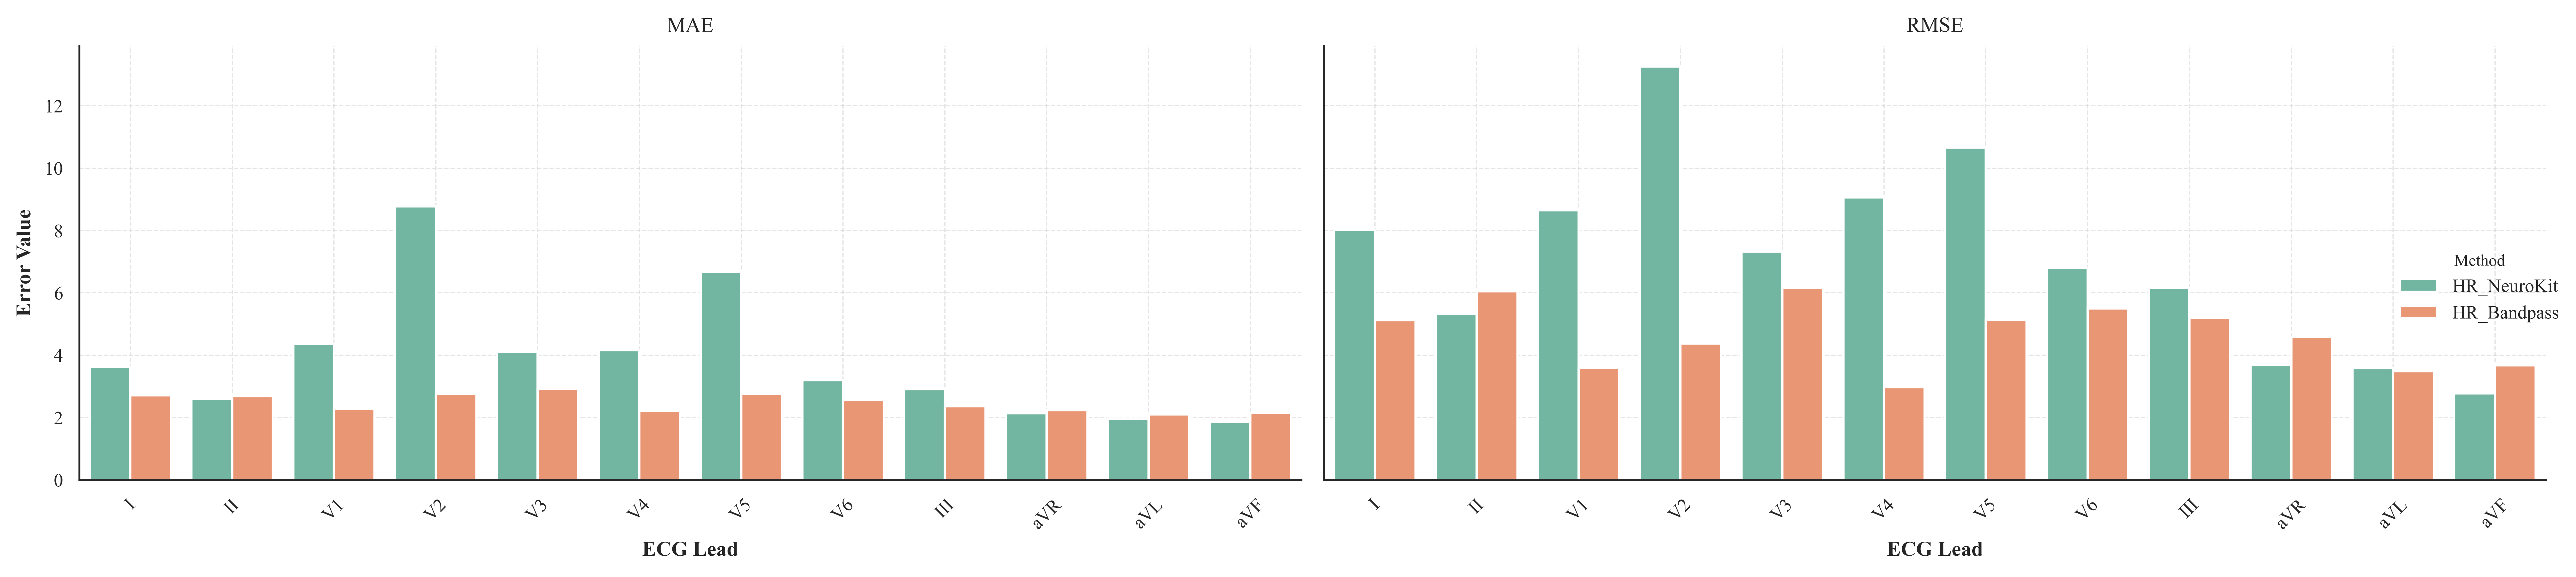

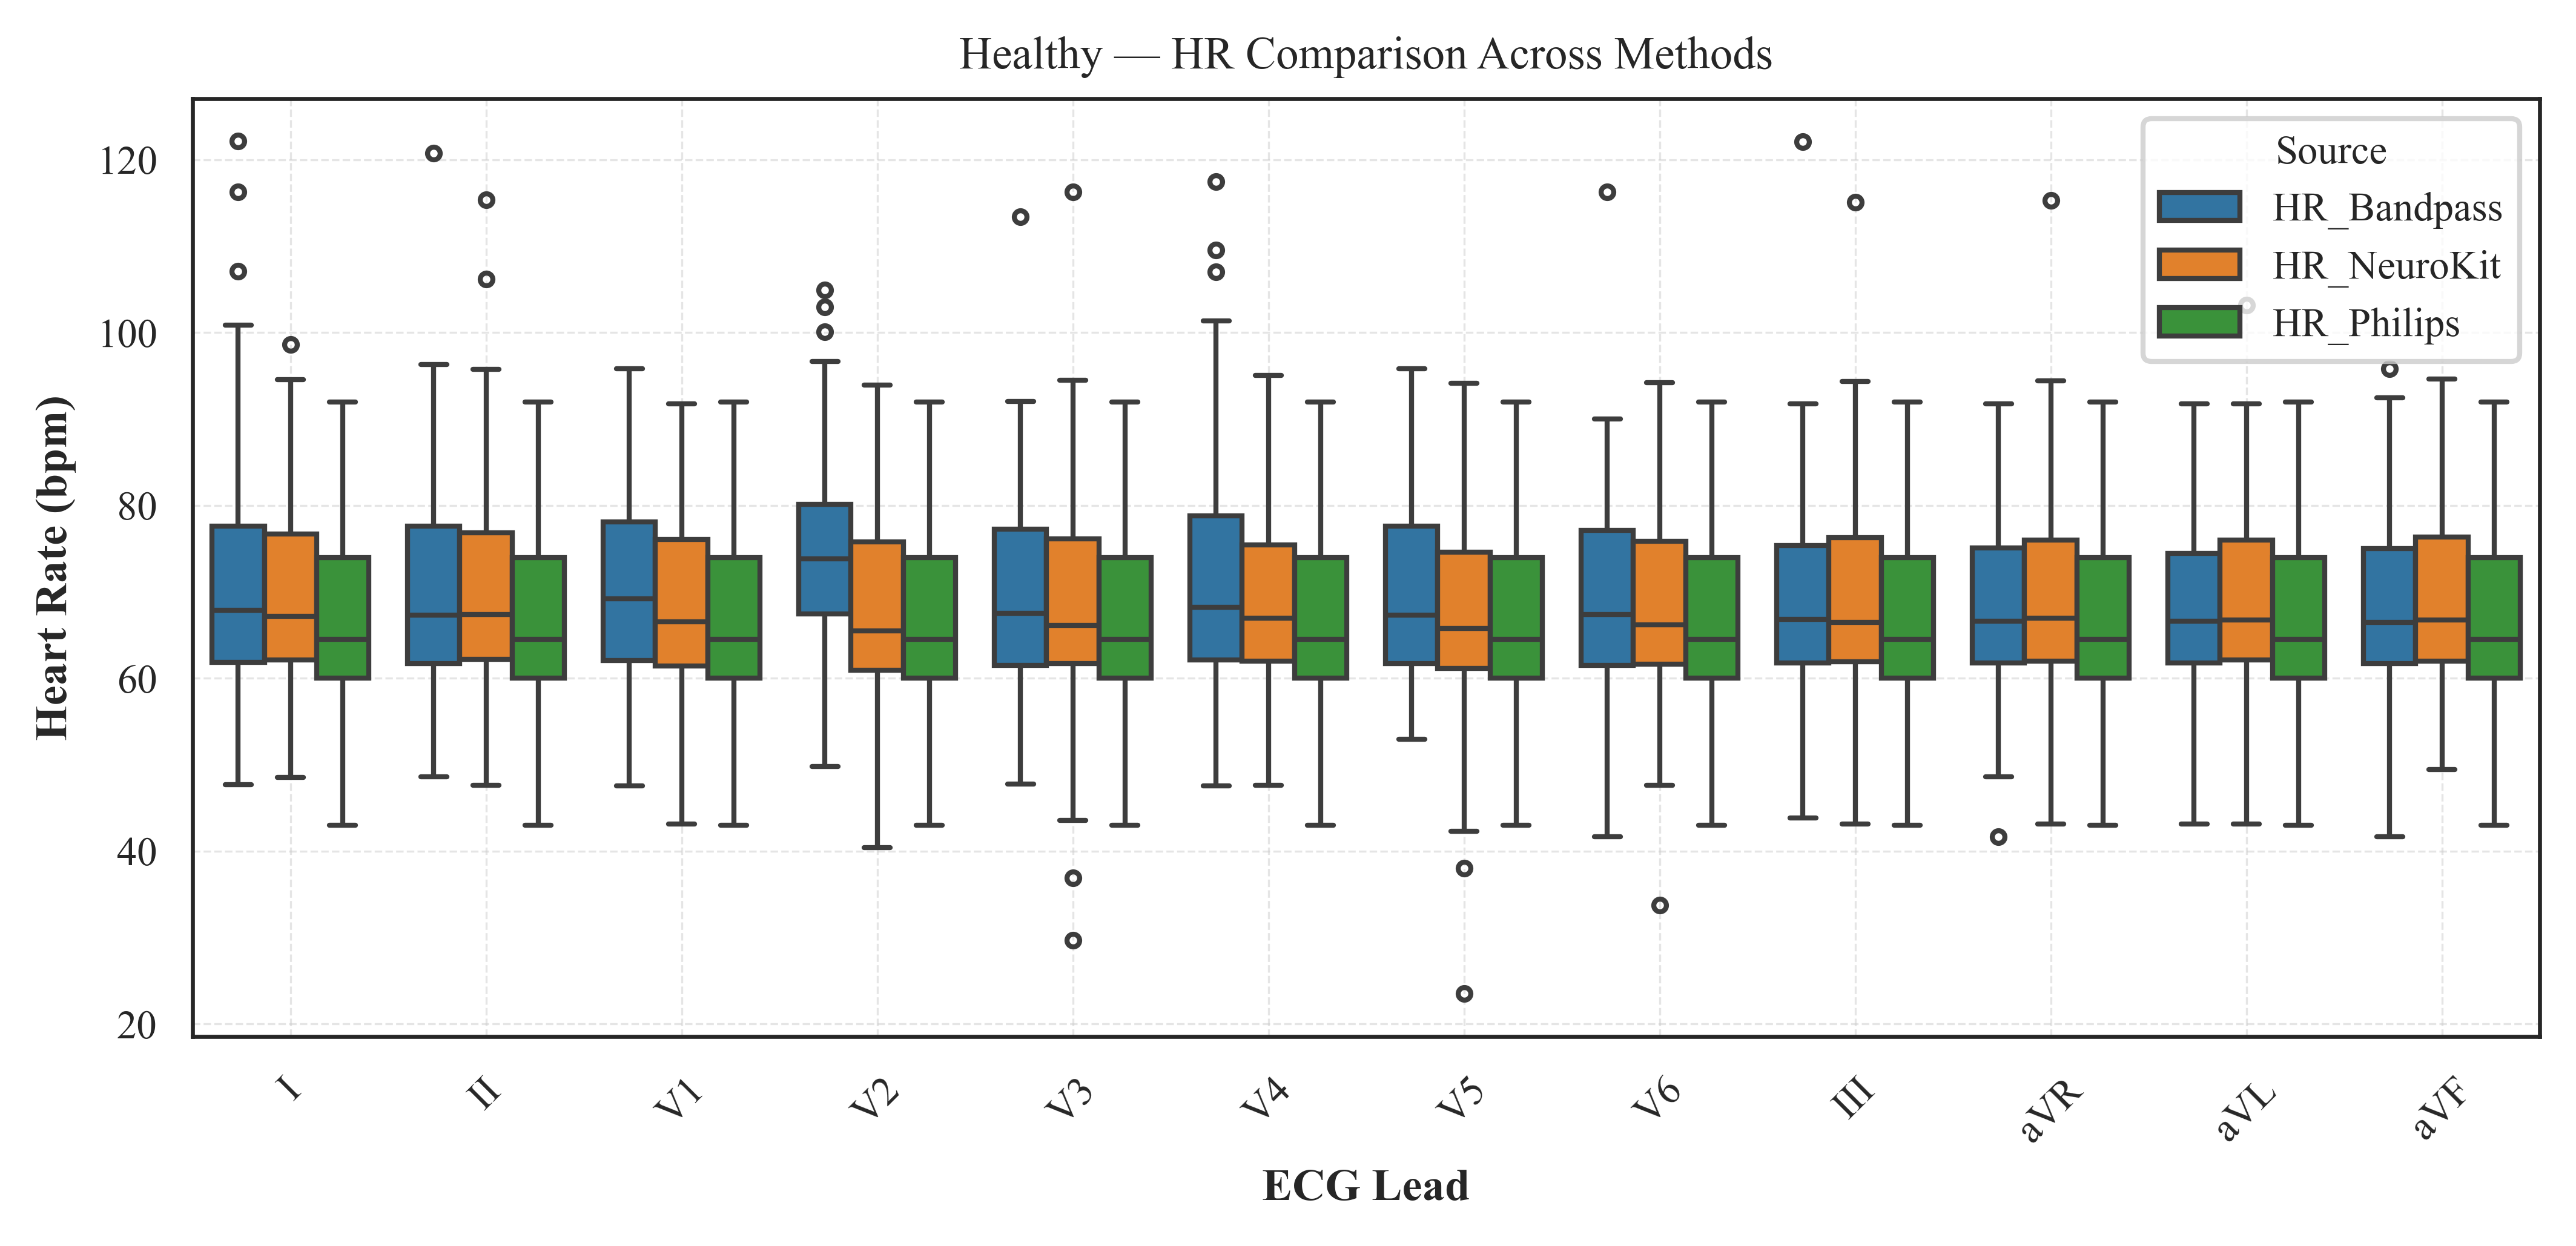

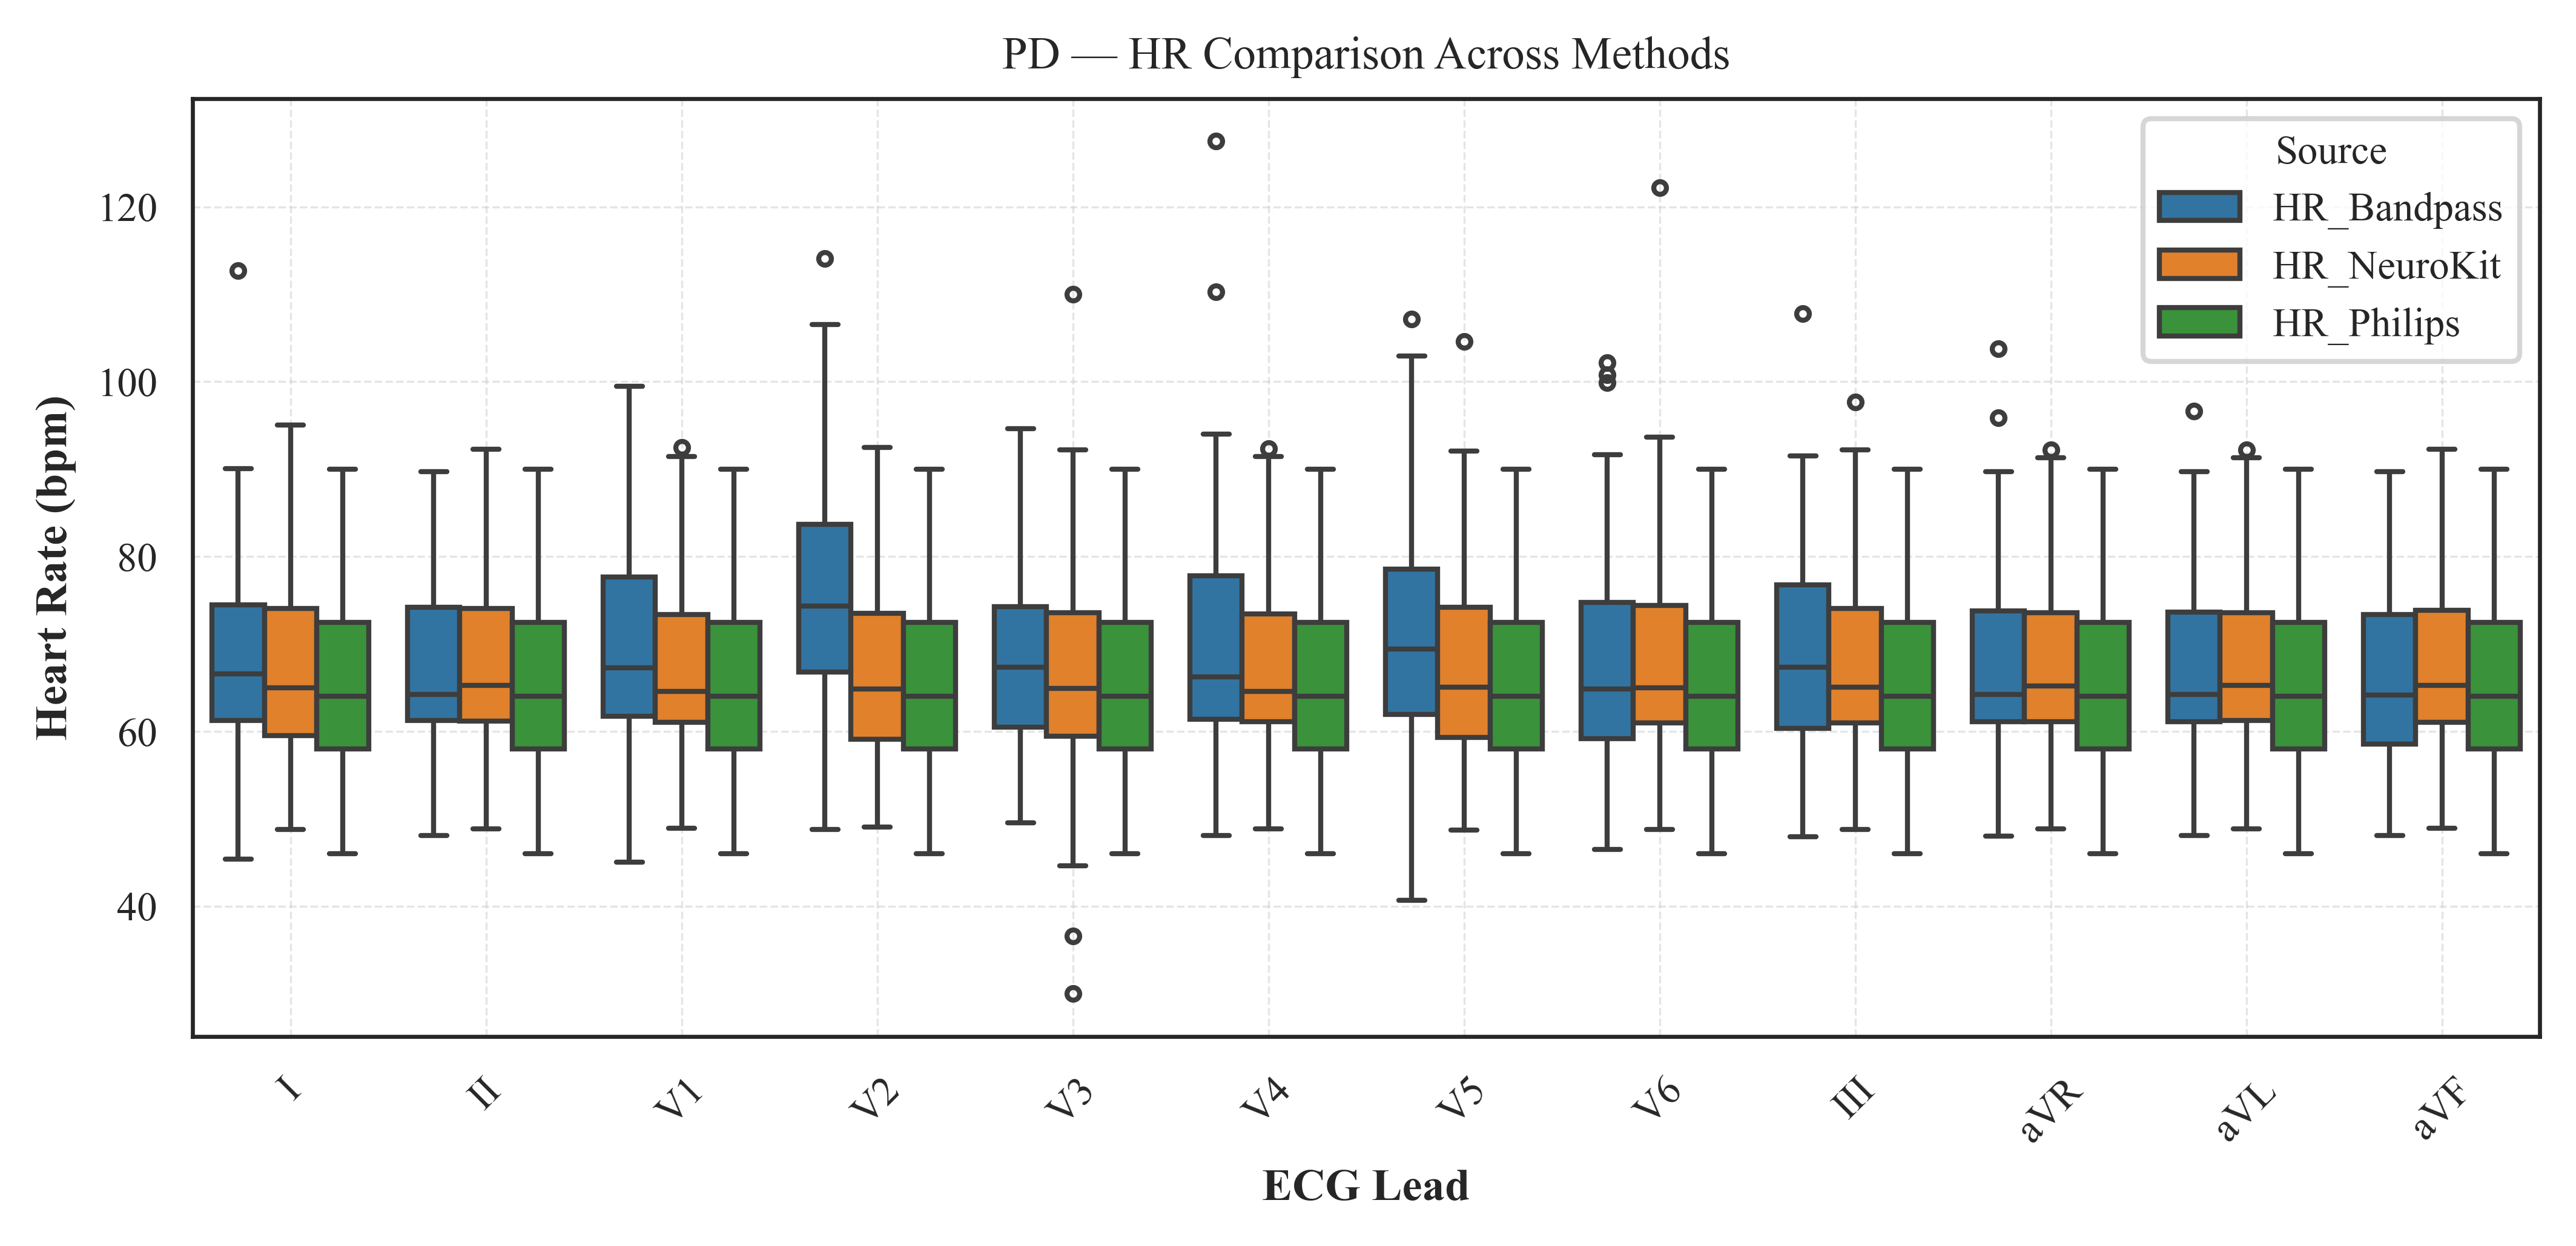

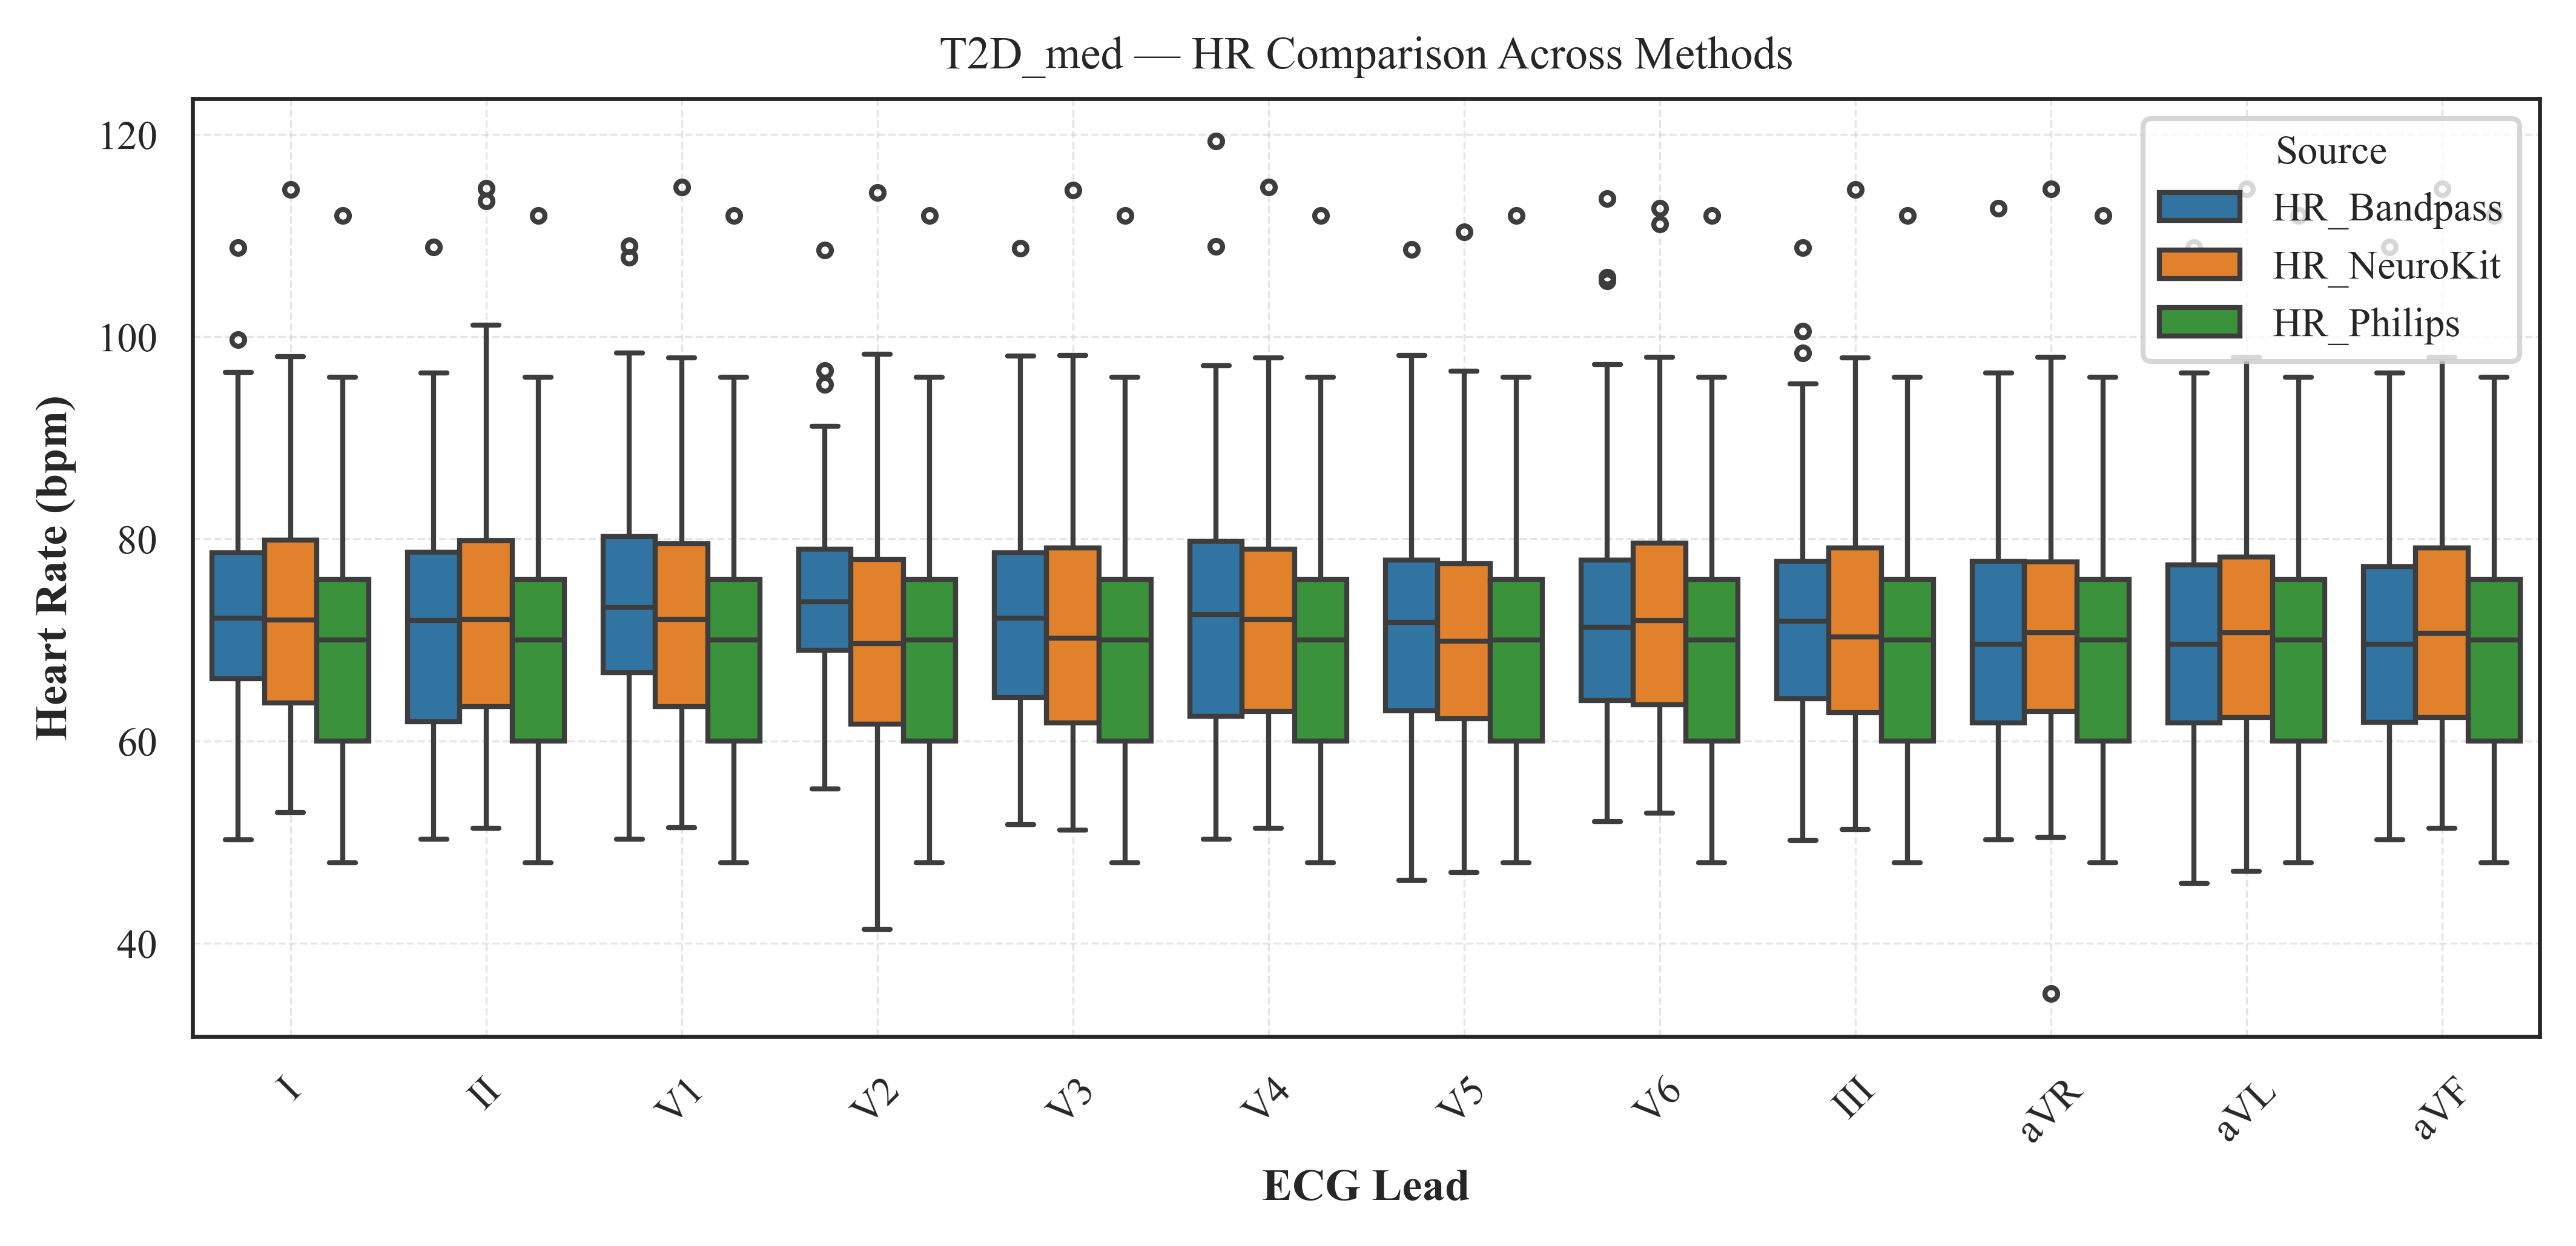

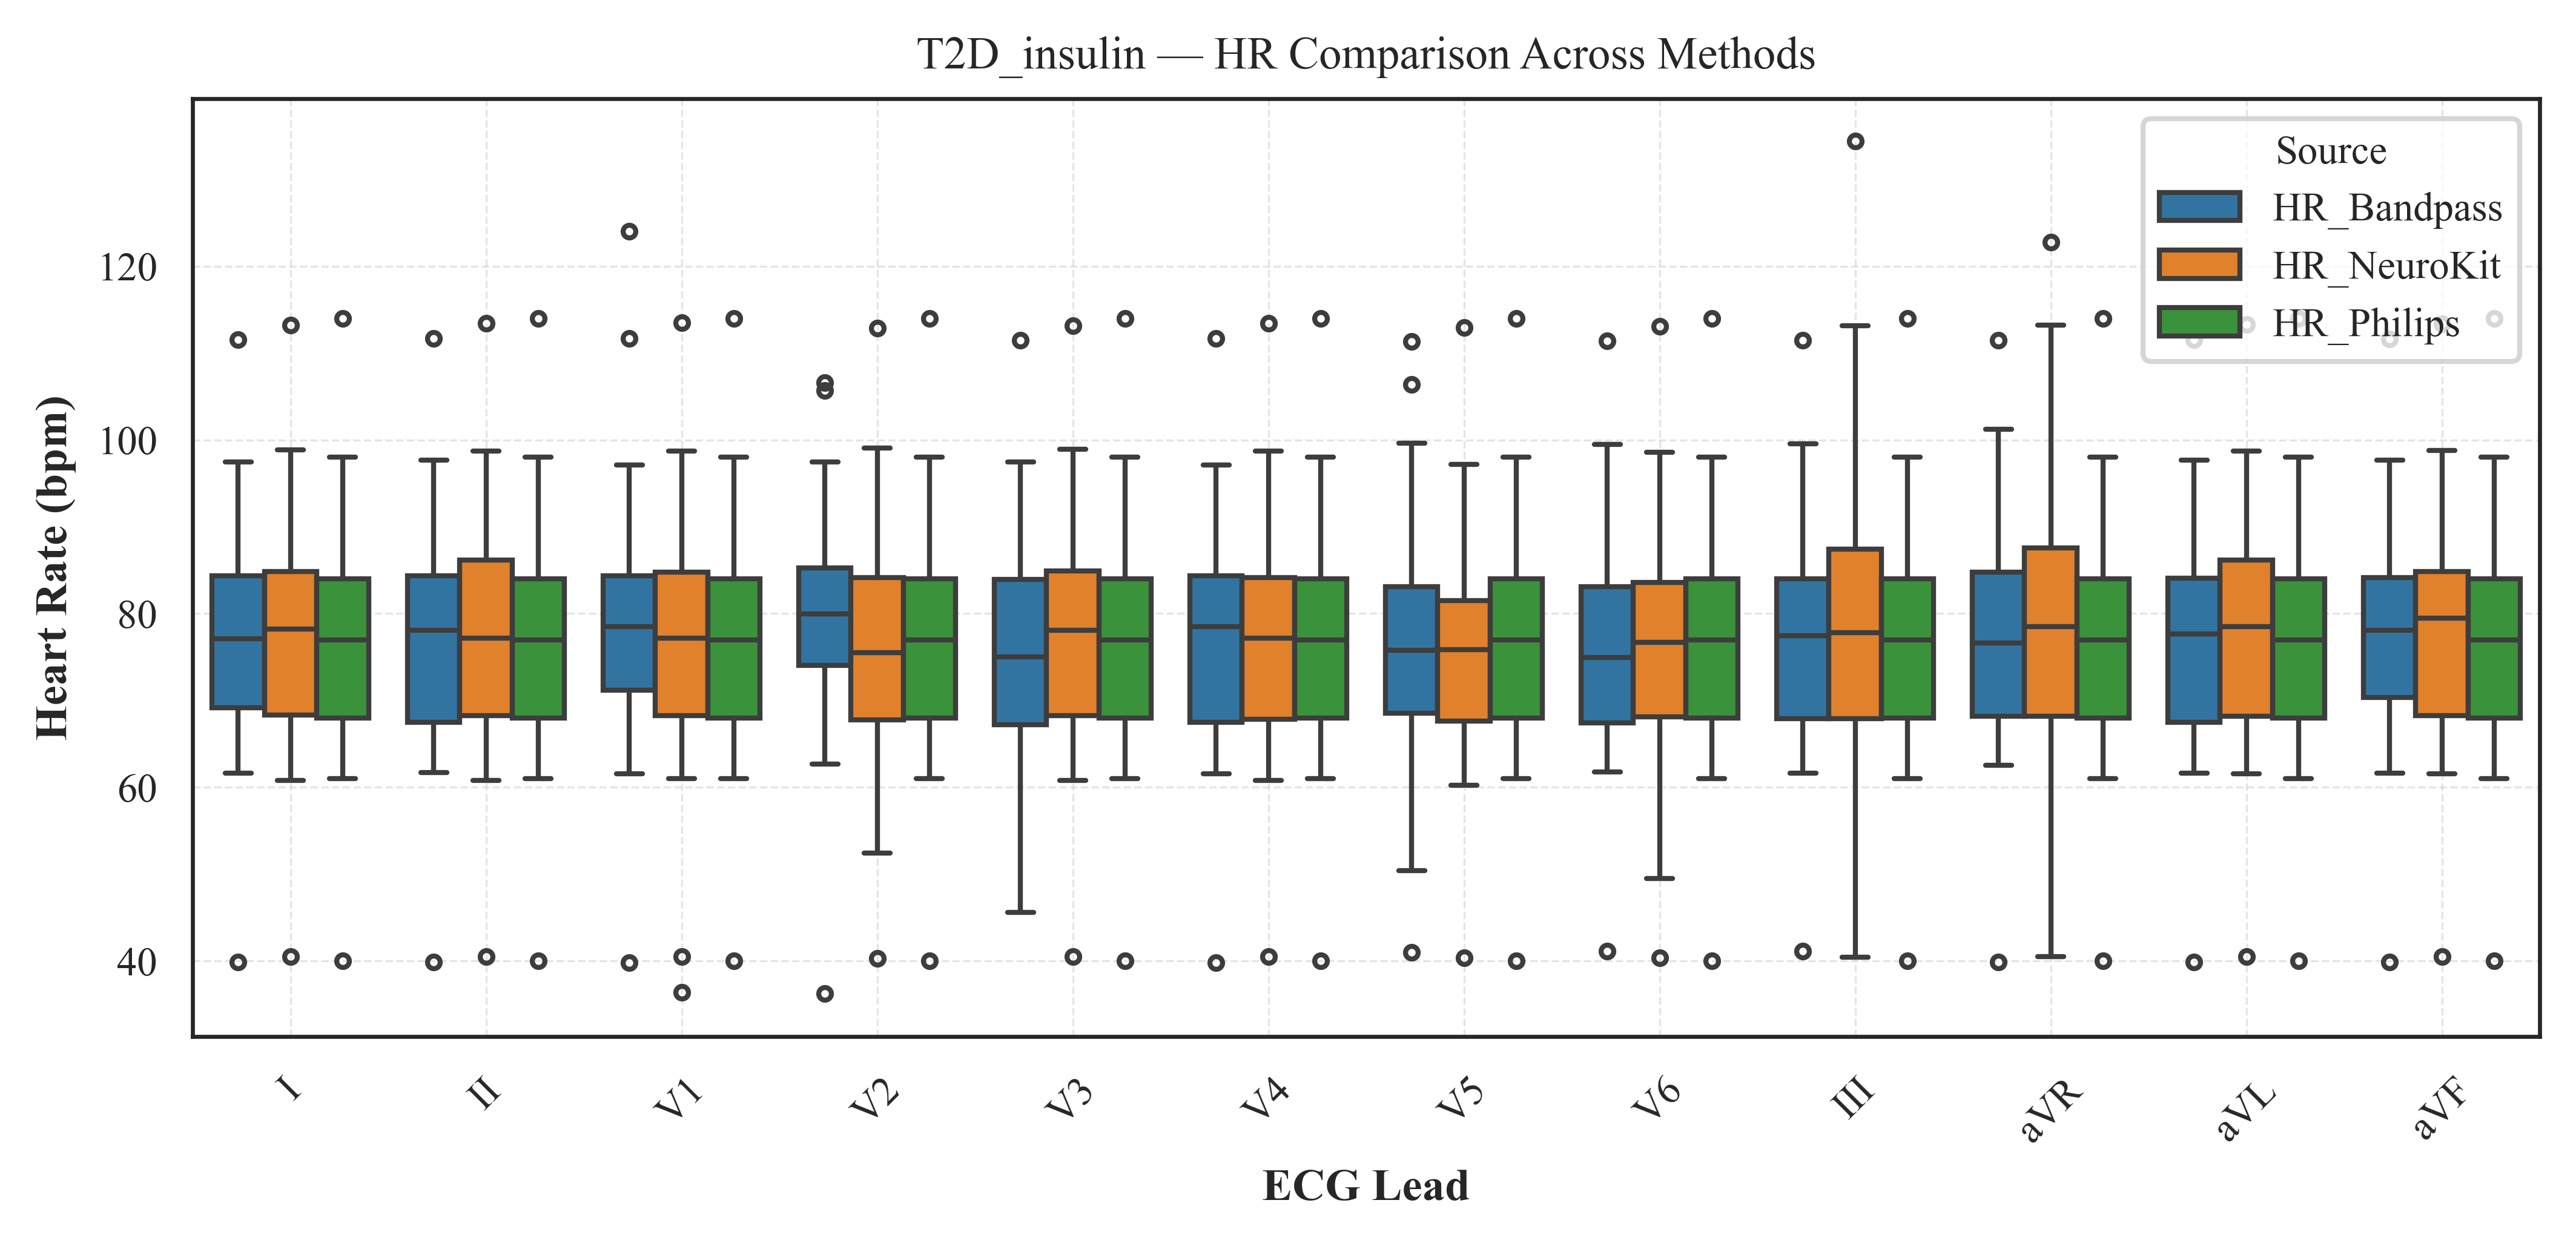

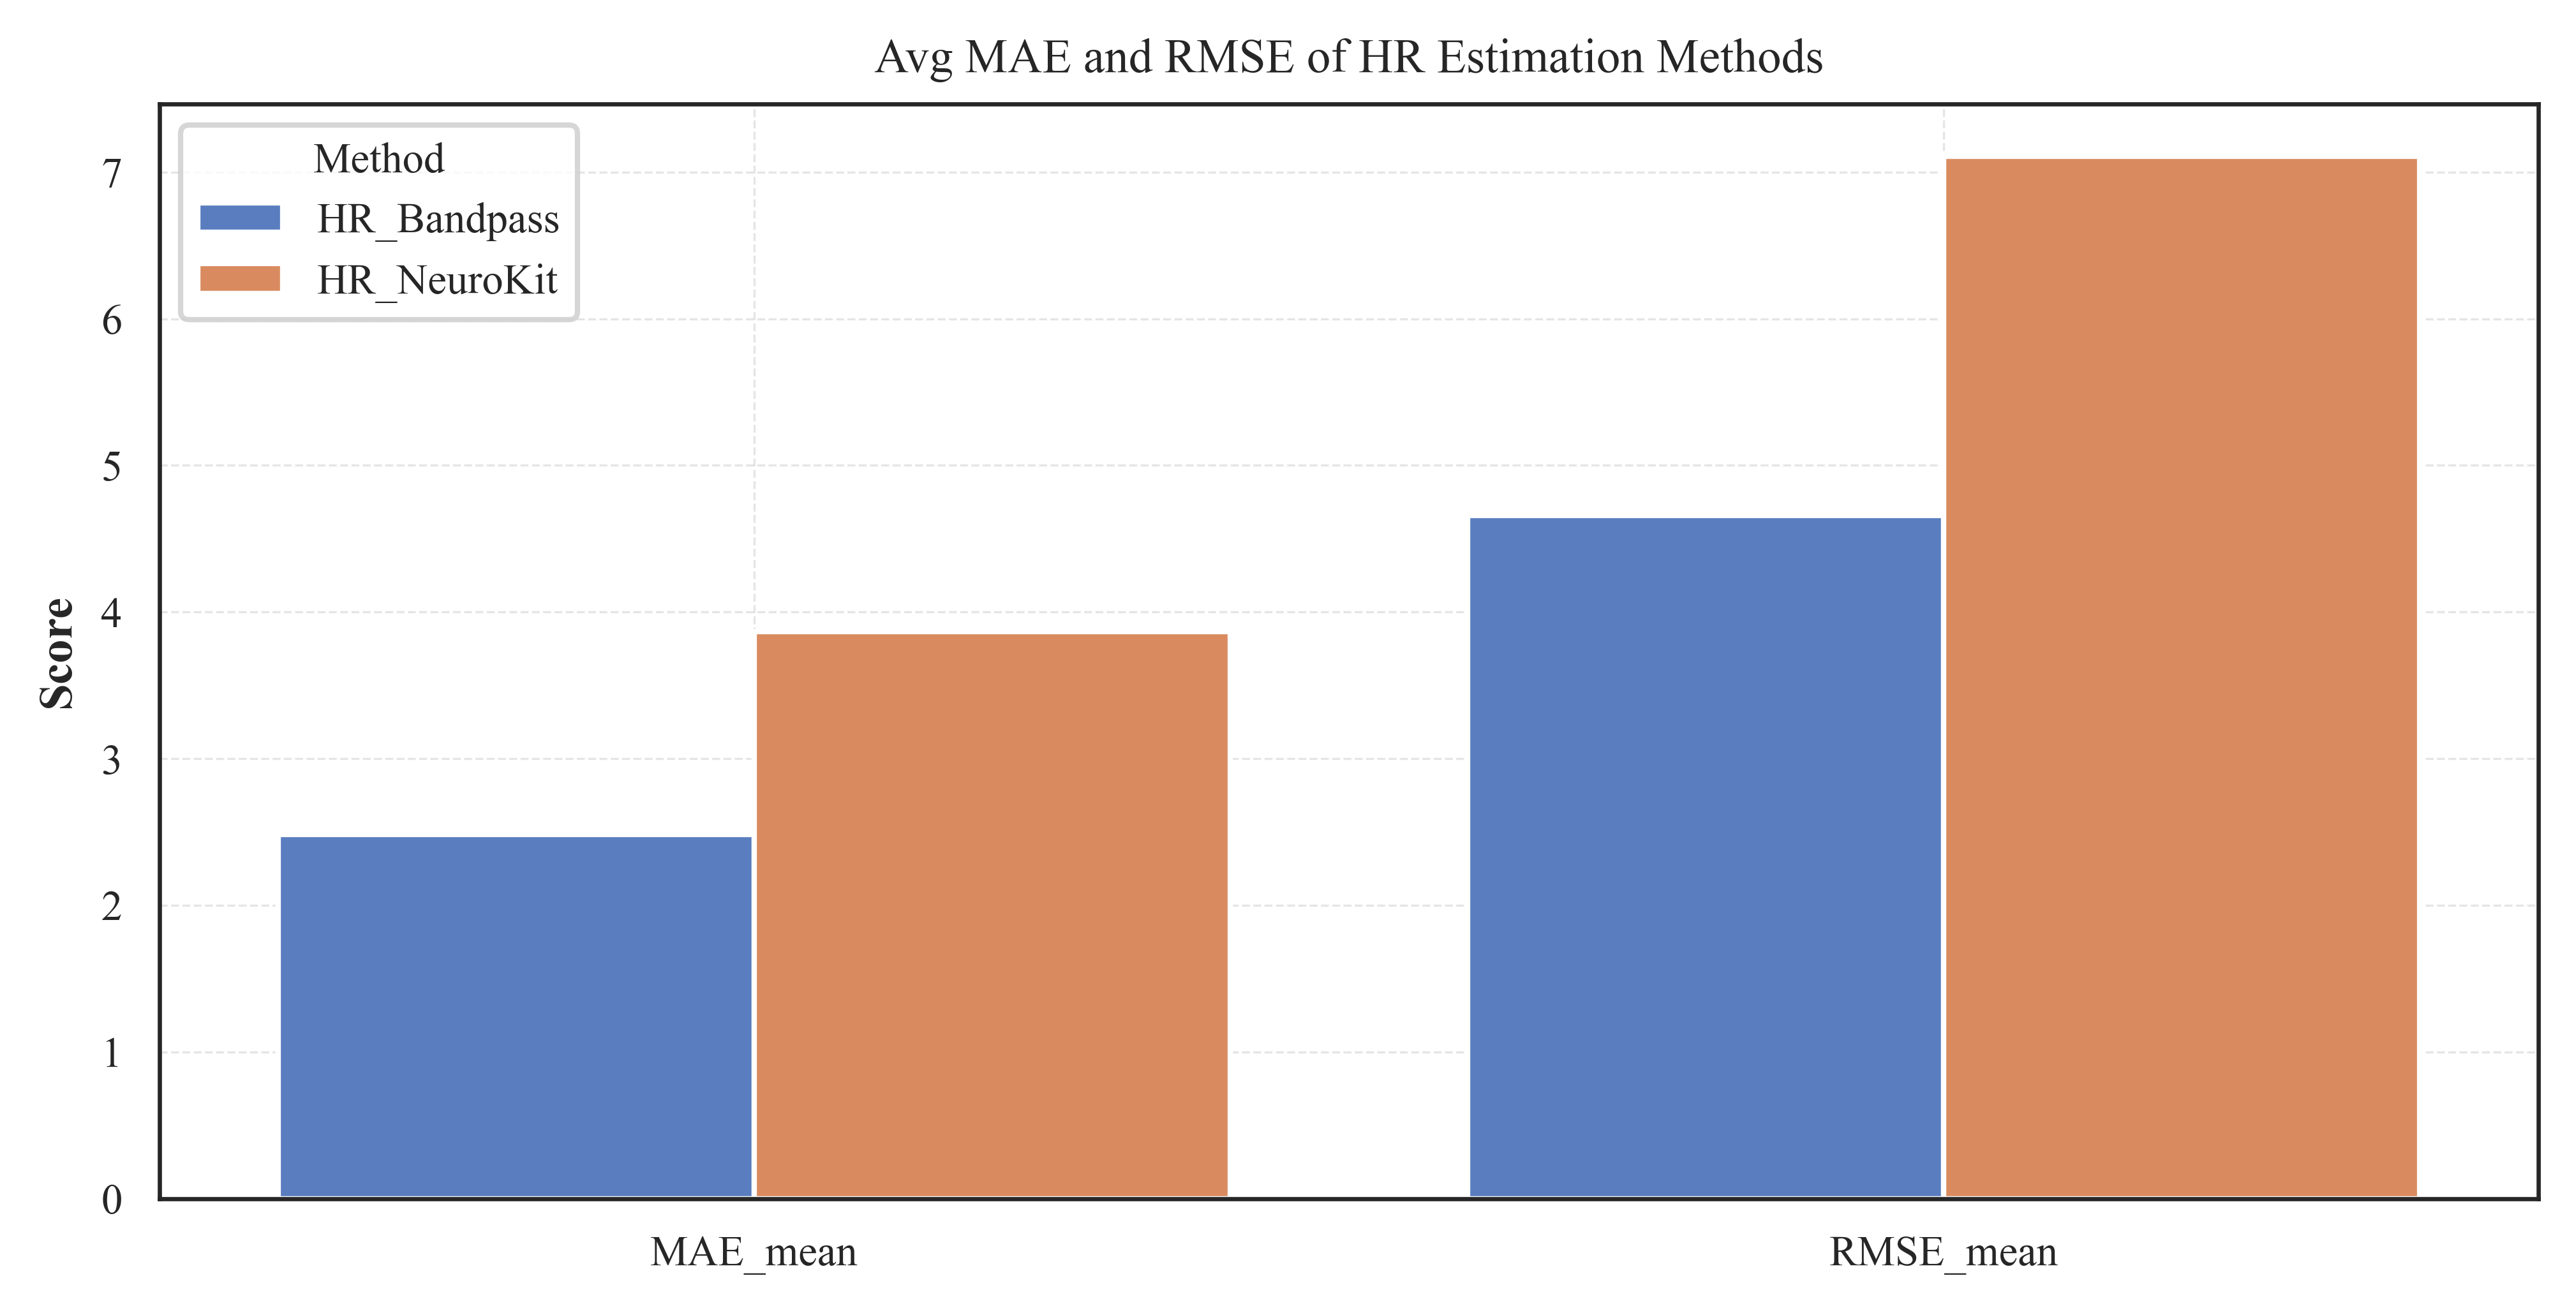

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, find_peaks, detrend
from sklearn.metrics import mean_squared_error, mean_absolute_error
import neurokit2 as nk
import warnings

warnings.filterwarnings("ignore")

# ----------------------------
# Step 1: Helper Functions
# ----------------------------
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low, high = lowcut / nyq, highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order)
    return filtfilt(b, a, data)

def extract_hr_bandpass(signal, fs):
    try:
        signal_detrended = detrend(signal)
        filtered = bandpass_filter(signal_detrended, 0.5, 40.0, fs)
        peaks, _ = find_peaks(filtered, distance=int(fs * 0.4), prominence=np.std(filtered) * 0.5)
        rr = np.diff(peaks) / fs
        return 60000 / (np.mean(rr) * 1000) if len(rr) > 1 else np.nan
    except Exception:
        return np.nan

def extract_hr_neurokit(signal, fs):
    try:
        ecg_cleaned = nk.ecg_clean(signal, sampling_rate=fs)
        _, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs)
        rr = np.diff(rpeaks['ECG_R_Peaks']) / fs
        return 60000 / (np.mean(rr) * 1000) if len(rr) > 1 else np.nan
    except Exception:
        return np.nan

# ----------------------------
# Step 2: Config
# ----------------------------
directory = "ECG Dataset_A1c"
fs = 500
num_channels = 12
lead_map = {
    'Electrode_1': 'I', 'Electrode_2': 'II', 'Electrode_3': 'V1', 'Electrode_4': 'V2',
    'Electrode_5': 'V3', 'Electrode_6': 'V4', 'Electrode_7': 'V5', 'Electrode_8': 'V6',
    'Electrode_9': 'III', 'Electrode_10': 'aVR', 'Electrode_11': 'aVL', 'Electrode_12': 'aVF'
}
category_map = {
    "pd": "PD", "healthy": "Healthy", "t2d_med": "T2D_med",
    "t2d_insulin": "T2D_insulin", "insulin": "T2D_insulin", "med": "T2D_med"
}
category_colors = {"Healthy": "blue", "PD": "red", "T2D_med": "green", "T2D_insulin": "purple"}
category_order = list(category_colors.keys())

manifest_df = pd.read_csv("manifest.tsv", sep="\t")
manifest_df['participant_id'] = manifest_df['participant_id'].astype(str)

# ----------------------------
# Step 3: Extract HR from Files
# ----------------------------
records = []

for filename in os.listdir(directory):
    if filename.endswith(".dat"):
        pid = filename.split("_")[0]
        category_token = filename.split("_")[-1].replace(".dat", "").lower()
        category = category_map.get(category_token, "Unknown")
        file_path = os.path.join(directory, filename)

        ecg_data = np.fromfile(file_path, dtype=np.int16)
        ecg_data = ecg_data[: (len(ecg_data) // num_channels) * num_channels].reshape(-1, num_channels)
        ecg_df = pd.DataFrame(ecg_data, columns=[f'Electrode_{i+1}' for i in range(num_channels)])

        for i in range(num_channels):
            lead_name = lead_map.get(f'Electrode_{i+1}', f'Electrode_{i+1}')
            signal = ecg_df[f'Electrode_{i+1}']

            hr_bandpass = extract_hr_bandpass(signal, fs)
            hr_neurokit = extract_hr_neurokit(signal, fs)

            records.append([pid, category, lead_name, hr_bandpass, hr_neurokit])

# ----------------------------
# Step 4: Merge with Philips HR
# ----------------------------
df = pd.DataFrame(records, columns=["participant_id", "Category", "Lead", "HR_Bandpass", "HR_NeuroKit"])
philips_df = manifest_df[["participant_id", "Rate"]].copy().rename(columns={"Rate": "HR_Philips"})

df = df.merge(philips_df, on="participant_id", how="left")
df = df[df["Category"].isin(category_order)]

# ----------------------------
# Step 5: Compute MAE and RMSE with Swapped Labels
# ----------------------------
metrics = []

for lead in df["Lead"].unique():
    for method in ["HR_Bandpass", "HR_NeuroKit"]:
        sub = df[df["Lead"] == lead].dropna(subset=[method, "HR_Philips"])
        if len(sub) > 2:
            rmse = mean_squared_error(sub["HR_Philips"], sub[method], squared=False)
            mae = mean_absolute_error(sub["HR_Philips"], sub[method])
            swapped_method = "HR_NeuroKit" if method == "HR_Bandpass" else "HR_Bandpass"
            metrics.append([lead, swapped_method, mae, rmse])

metrics_df = pd.DataFrame(metrics, columns=["Lead", "Method", "MAE", "RMSE"])
metrics_df.to_csv("HR_Comparison_MAE_RMSE.csv", index=False)

# ----------------------------
# Step 5.1: IEEE-Style Bar Plot
# ----------------------------
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

metric_plot_df = metrics_df.melt(id_vars=["Lead", "Method"],
                                 value_vars=["MAE", "RMSE"],
                                 var_name="Metric", value_name="Value")

g = sns.catplot(
    data=metric_plot_df,
    kind="bar",
    x="Lead",
    y="Value",
    hue="Method",
    col="Metric",
    height=3.5, aspect=2.04, palette="Set2", ci=None
)
g.set_titles("{col_name}")
g.set_axis_labels("ECG Lead", "Error Value")
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
g._legend.set_title("Method")

plt.tight_layout()
plt.savefig("IEEE_HR_MAE_RMSE_Comparison.png", dpi=600, bbox_inches='tight')
plt.show()

# ----------------------------
# Step 6: IEEE-Style Boxplots
# ----------------------------
for category in category_order:
    subset = df[df["Category"] == category]

    subset_long = subset[["Lead", "HR_Bandpass", "HR_NeuroKit", "HR_Philips"]].copy()
    subset_long["Category"] = category
    subset_long = pd.melt(subset_long, id_vars=["Lead", "Category"],
                          value_vars=["HR_Bandpass", "HR_NeuroKit", "HR_Philips"],
                          var_name="Source", value_name="HR")

    plt.figure(figsize=(7.16, 3.5))  # IEEE double column size
    sns.boxplot(data=subset_long, x="Lead", y="HR", hue="Source", fliersize=2.5)
    plt.title(f"{category} — HR Comparison Across Methods", fontsize=9)
    plt.ylabel("Heart Rate (bpm)")
    plt.xlabel("ECG Lead")
    plt.xticks(rotation=45)
    plt.legend(title="Source", loc="upper right", fontsize=8, title_fontsize=8)
    plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"IEEE_{category}_HR_Boxplot.png", dpi=600, bbox_inches='tight')
    plt.show()

# ----------------------------
# Step 7: Method Summary
# ----------------------------
method_summary = metrics_df.groupby("Method").agg({
    "MAE": ["mean", "std"],
    "RMSE": ["mean", "std"]
}).reset_index()

method_summary.columns = ['Method', 'MAE_mean', 'MAE_std', 'RMSE_mean', 'RMSE_std']
method_summary.to_csv("HR_Method_MAE_RMSE_Summary.csv", index=False)

melted_summary = method_summary.melt(id_vars="Method",
                                     value_vars=["MAE_mean", "RMSE_mean"],
                                     var_name="Metric", value_name="Score")

plt.figure(figsize=(6.8, 3.5))
sns.barplot(data=melted_summary, x="Metric", y="Score", hue="Method", palette="muted", ci=None)
plt.title("Avg MAE and RMSE of HR Estimation Methods", fontsize=9)
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.5)
plt.legend(title="Method", loc="best", fontsize=8, title_fontsize=8)
plt.tight_layout()
plt.savefig("IEEE_HR_Method_MAE_RMSE_Summary.png", dpi=600, bbox_inches='tight')
plt.show()
